In [1]:
# ============================================================
# NACC ALZHEIMER — 5 MODEL RELEASE PIPELINE (PARTS 0–8)
# - Uses frozen clean dataset: nacc_clean_complete_case_AD01.csv
# - 50 seeds, stratified 80/20
# - Models: XGBoost, LogReg, Ridge, KNN, Linear SVM (SVM last)
# - Includes: accuracy barplot, top10 importance barplots,
#            canonical metrics + tests, calibration, redundancy + plots
# - Excludes: heatmaps
# - Saves EVERYTHING to: ~/Research/Alzheimer/5 model/run_YYYYMMDD_HHMMSS/
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from xgboost import XGBClassifier
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar

sns.set(style="whitegrid")

# -----------------------------
# Pretty helpers
# -----------------------------
def print_header(title):
    print("\n" + "="*100)
    print(title)
    print("="*100)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def compute_classification_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size != 4:
        return {"Sensitivity": np.nan, "Specificity": np.nan, "Precision": np.nan, "F1": np.nan}
    tn, fp, fn, tp = cm.ravel()
    sens = safe_div(tp, tp + fn)
    spec = safe_div(tn, tn + fp)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {"Sensitivity": float(sens), "Specificity": float(spec), "Precision": float(prec), "F1": float(f1)}

# -----------------------------
# DeLong (correlated ROC-AUC test)
# -----------------------------
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2

def _fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)
    v01 = (tx / n) - (tz[:, :m] / n)
    v10 = 1.0 - (ty / m) + (tz[:, m:] / m)

    sx = np.cov(v01)
    sy = np.cov(v10)
    s = sx / m + sy / n
    return aucs, s

def delong_roc_test(y_true, y_scores_a, y_scores_b):
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    preds_sorted = np.vstack([np.asarray(y_scores_a)[order], np.asarray(y_scores_b)[order]])

    m = int(np.sum(y_sorted))
    aucs, cov = _fastDeLong(preds_sorted, m)
    diff = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    if var <= 0:
        return np.nan, np.nan, float(aucs[0]), float(aucs[1])
    z = diff / np.sqrt(var)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return float(z), float(p), float(aucs[0]), float(aucs[1])

# -----------------------------
# McNemar
# -----------------------------
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = np.asarray(y_pred_b)

    both_correct = np.sum((y_pred_a == y_true) & (y_pred_b == y_true))
    a_correct_b_wrong = np.sum((y_pred_a == y_true) & (y_pred_b != y_true))
    a_wrong_b_correct = np.sum((y_pred_a != y_true) & (y_pred_b == y_true))
    both_wrong = np.sum((y_pred_a != y_true) & (y_pred_b != y_true))

    table = [[both_correct, a_correct_b_wrong],
             [a_wrong_b_correct, both_wrong]]
    res = mcnemar(table, exact=False, correction=True)
    return float(res.statistic), float(res.pvalue), table

# ============================================================
# PART 0) LOAD CLEAN FROZEN DATA + OUTPUT FOLDER
# ============================================================
print_header("PART 0) LOAD CLEAN FROZEN DATA + CREATE OUTPUT FOLDER")

BASE_DIR = Path.home() / "Research" / "Alzheimer"
DATA_PATH = BASE_DIR / "nacc_clean_complete_case_AD01.csv"
TARGET = "NACCALZD"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

# Keep definitive labels only
df = df[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

# Drop leakage / ID / visit metadata (same rationale as earlier runs)
DROP_COLS = [
    TARGET,
    # likely label-derived/leakage flags
    "ad_flag", "mci_flag", "DEMENTED", "NACCTMCI", "NORMCOG",
    # identifiers / visit timing
    "NACCID", "NACCVNUM", "VISITYR", "VISITMO", "VISITDAY", "BIRTHMO",
]
X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET].copy()
feature_names = X.columns.tolist()

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = BASE_DIR / "5 model" / f"run_{timestamp}"
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

print("✅ Loaded:", DATA_PATH)
print("Shape df:", df.shape)
print("Shape X :", X.shape)
print("Positive rate:", float(np.mean(y == 1)))
print("✅ Output folder:", OUT_DIR)

# Save manifest early
manifest0 = {
    "data_path": str(DATA_PATH),
    "out_dir": str(OUT_DIR),
    "n_rows": int(df.shape[0]),
    "n_features": int(X.shape[1]),
    "target": TARGET,
    "dropped_cols_present": [c for c in DROP_COLS if c in df.columns],
}
with open(OUT_DIR / "manifest_part0.json", "w") as f:
    json.dump(manifest0, f, indent=2)

# ============================================================
# MODELS (5 only; SVM last)
# ============================================================
def build_models(seed=0):
    return {
        "XGBoost": XGBClassifier(
            tree_method="hist",
            random_state=seed,
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1
        ),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=10000, random_state=seed))
        ]),
        "Ridge Classifier": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RidgeClassifier(random_state=seed))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5))
        ]),
        # SLOWEST LAST
        "SVM (Linear)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", svm.SVC(kernel="linear", probability=True, random_state=seed))
        ]),
    }

MODEL_ORDER = list(build_models(0).keys())

# ============================================================
# PART 1) ACCURACY ACROSS 50 SEEDS (+ save canonical split)
# ============================================================
print_header("PART 1) ACCURACY ACROSS 50 SEEDS (80/20 stratified) — SVM LAST")

SEEDS = list(range(50))
canonical_seed = SEEDS[-1]

acc_seed = {m: [] for m in MODEL_ORDER}
X_train = X_test = y_train = y_test = None

pbar = tqdm(SEEDS, desc="Part 1: 50 seeds (accuracy)", leave=True)

for seed in pbar:
    Xt, Xv, yt, yv = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    models = build_models(seed)

    # run in batches: loop in fixed order (SVM last)
    for name in MODEL_ORDER:
        model = models[name]
        model.fit(Xt, yt)
        pred = model.predict(Xv)
        acc_seed[name].append(float(accuracy_score(yv, pred)))

    if seed == canonical_seed:
        X_train, X_test, y_train, y_test = Xt, Xv, yt, yv

seed_acc_df = pd.DataFrame(acc_seed)
seed_acc_path = OUT_DIR / "tables" / "seed_accuracies_5models.csv"
seed_acc_df.to_csv(seed_acc_path, index=False)
print("✅ Saved:", seed_acc_path)

# Accuracy summary
acc_summary = pd.DataFrame({
    "Model": MODEL_ORDER,
    "mean_acc": [seed_acc_df[m].mean() for m in MODEL_ORDER],
    "sd_acc":   [seed_acc_df[m].std(ddof=1) for m in MODEL_ORDER],
}).sort_values("mean_acc", ascending=False)
acc_summary_path = OUT_DIR / "tables" / "accuracy_summary_mean_sd_5models.csv"
acc_summary.to_csv(acc_summary_path, index=False)
print("✅ Saved:", acc_summary_path)

# ============================================================
# PART 2) ACCURACY BAR PLOT (5 models, colored bars)
# ============================================================
print_header("PART 2) ACCURACY BAR PLOT (5 models)")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=acc_summary, x="Model", y="mean_acc", palette="tab10", ci=None)
ax.errorbar(
    x=np.arange(acc_summary.shape[0]),
    y=acc_summary["mean_acc"].values,
    yerr=acc_summary["sd_acc"].values,
    fmt="none",
    capsize=6,
    linewidth=2
)
ax.set_title("Accuracy Across 50 Seeds (Mean ± SD) — 5 Models")
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()

fig_acc = OUT_DIR / "figures" / "accuracy_bar_5models.png"
plt.savefig(fig_acc, dpi=300)
plt.close()
print("✅ Saved:", fig_acc)

# Paired t-tests (accuracy)
tt_rows = []
names = MODEL_ORDER
for i in range(len(names)):
    for j in range(i+1, len(names)):
        A, B = names[i], names[j]
        t, p = stats.ttest_rel(seed_acc_df[A], seed_acc_df[B])
        tt_rows.append({"A": A, "B": B, "t_stat": float(t), "p_value": float(p)})
tt_df = pd.DataFrame(tt_rows).sort_values("p_value")
tt_path = OUT_DIR / "tables" / "paired_ttests_accuracy_across_seeds_5models.csv"
tt_df.to_csv(tt_path, index=False)
print("✅ Saved:", tt_path)

# ============================================================
# PART 3) FEATURE IMPORTANCE ACROSS SEEDS (Top-10 + bar charts)
# ============================================================
print_header("PART 3) FEATURE IMPORTANCE ACROSS 50 SEEDS (Top-10 per model)")

feat_imp = {m: [] for m in MODEL_ORDER}
pbar = tqdm(SEEDS, desc="Part 3: feature importance", leave=True)

for seed in pbar:
    Xt, Xv, yt, yv = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    models = build_models(seed)

    # XGBoost feature_importances_
    xgb = models["XGBoost"]
    xgb.fit(Xt, yt)
    feat_imp["XGBoost"].append(xgb.feature_importances_)

    # Logistic Regression coef_
    lr = models["Logistic Regression"]
    lr.fit(Xt, yt)
    feat_imp["Logistic Regression"].append(np.abs(lr.named_steps["clf"].coef_[0]))

    # Ridge coef_
    ridge = models["Ridge Classifier"]
    ridge.fit(Xt, yt)
    coef = ridge.named_steps["clf"].coef_
    coef = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    feat_imp["Ridge Classifier"].append(coef)

    # KNN permutation importance (on validation fold)
    knn = models["KNN"]
    knn.fit(Xt, yt)
    pi = permutation_importance(knn, Xv, yv, n_repeats=5, random_state=seed, n_jobs=-1)
    feat_imp["KNN"].append(np.clip(pi.importances_mean, 0, None))

    # SVM linear — use coef_ from underlying linear SVC in SVC? (SVC has coef_ for linear kernel)
    svm_m = models["SVM (Linear)"]
    svm_m.fit(Xt, yt)
    # coef_ exists for linear kernel SVC
    feat_imp["SVM (Linear)"].append(np.abs(svm_m.named_steps["clf"].coef_.ravel()))

importance_dfs = {}
for name, arrs in feat_imp.items():
    avg = np.mean(np.vstack(arrs), axis=0)
    imp_df = pd.DataFrame({"Feature": feature_names, "Importance": avg}).sort_values("Importance", ascending=False)
    importance_dfs[name] = imp_df

# Save full importance tables + top10 tables
imp_all_path = OUT_DIR / "tables" / "feature_importance_all_5models.csv"
pd.concat(
    [df.assign(Model=model) for model, df in importance_dfs.items()],
    ignore_index=True
).to_csv(imp_all_path, index=False)
print("✅ Saved:", imp_all_path)

top10_rows = []
for model, df_imp in importance_dfs.items():
    top10 = df_imp.head(10).copy()
    top10["Model"] = model
    top10_rows.append(top10)
top10_df = pd.concat(top10_rows, ignore_index=True)
top10_path = OUT_DIR / "tables" / "top10_features_5models.csv"
top10_df.to_csv(top10_path, index=False)
print("✅ Saved:", top10_path)

# Top-10 bar chart per model
for model, df_imp in importance_dfs.items():
    top = df_imp.head(10).iloc[::-1]  # reverse for barh
    plt.figure(figsize=(9, 5))
    plt.barh(top["Feature"], top["Importance"])
    plt.title(f"Top 10 Feature Importance — {model}")
    plt.xlabel("Importance")
    plt.tight_layout()
    outp = OUT_DIR / "figures" / f"top10_importance_{model.replace(' ','_').replace('(','').replace(')','')}.png"
    plt.savefig(outp, dpi=300)
    plt.close()
    print("✅ Saved:", outp)

# Combined grid figure (5 models)
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()
for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    top = importance_dfs[model].head(10).iloc[::-1]
    ax.barh(top["Feature"], top["Importance"])
    ax.set_title(model)
    ax.tick_params(axis="y", labelsize=8)
for j in range(len(MODEL_ORDER), len(axes)):
    axes[j].axis("off")
plt.suptitle("Top 10 Feature Importances — 5 Models", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
combined_top10_fig = OUT_DIR / "figures" / "top10_importance_grid_5models.png"
plt.savefig(combined_top10_fig, dpi=300)
plt.close()
print("✅ Saved:", combined_top10_fig)

# ============================================================
# PART 4) CANONICAL SPLIT METRICS + McNemar + DeLong + Calibration
# ============================================================
print_header("PART 4) CANONICAL SPLIT METRICS + TESTS + CALIBRATION")
print("Canonical seed:", canonical_seed)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

models_final = build_models(seed=0)
preds = {}
scores = {}

for name in MODEL_ORDER:
    model = models_final[name]
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)

    try:
        scores[name] = model.predict_proba(X_test)[:, 1]
    except Exception:
        try:
            s = model.decision_function(X_test)
            scores[name] = MinMaxScaler().fit_transform(s.reshape(-1, 1)).ravel()
        except Exception:
            scores[name] = None

rows = []
for name in MODEL_ORDER:
    row = {"Model": name}
    row["Accuracy"] = float(accuracy_score(y_test, preds[name]))
    row.update(compute_classification_metrics(y_test, preds[name]))

    if scores[name] is not None:
        row["ROC_AUC"] = float(roc_auc_score(y_test, scores[name]))
        row["PR_AUC"] = float(average_precision_score(y_test, scores[name]))
        row["Brier"] = float(brier_score_loss(y_test, scores[name]))
    else:
        row["ROC_AUC"] = np.nan
        row["PR_AUC"] = np.nan
        row["Brier"] = np.nan
    rows.append(row)

metrics_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
metrics_path = OUT_DIR / "tables" / "canonical_metrics_5models.csv"
metrics_df.to_csv(metrics_path, index=False)
print("✅ Saved:", metrics_path)

# McNemar
mcn_rows = []
for i in range(len(MODEL_ORDER)):
    for j in range(i+1, len(MODEL_ORDER)):
        A, B = MODEL_ORDER[i], MODEL_ORDER[j]
        stat, pval, table = mcnemar_test(y_test, preds[A], preds[B])
        mcn_rows.append({"A": A, "B": B, "statistic": stat, "p_value": pval, "table": str(table)})
mcn_df = pd.DataFrame(mcn_rows).sort_values("p_value")
mcn_path = OUT_DIR / "tables" / "mcnemar_canonical_5models.csv"
mcn_df.to_csv(mcn_path, index=False)
print("✅ Saved:", mcn_path)

# DeLong ROC-AUC tests
dl_rows = []
for i in range(len(MODEL_ORDER)):
    for j in range(i+1, len(MODEL_ORDER)):
        A, B = MODEL_ORDER[i], MODEL_ORDER[j]
        if scores[A] is None or scores[B] is None:
            dl_rows.append({"A": A, "B": B, "z_stat": np.nan, "p_value": np.nan, "AUC_A": np.nan, "AUC_B": np.nan})
            continue
        z, p, aucA, aucB = delong_roc_test(y_test.astype(int), scores[A], scores[B])
        dl_rows.append({"A": A, "B": B, "z_stat": z, "p_value": p, "AUC_A": aucA, "AUC_B": aucB})
dl_df = pd.DataFrame(dl_rows).sort_values("p_value")
dl_path = OUT_DIR / "tables" / "delong_canonical_5models.csv"
dl_df.to_csv(dl_path, index=False)
print("✅ Saved:", dl_path)

# Calibration curves
plt.figure(figsize=(8, 6))
for name in MODEL_ORDER:
    if scores[name] is None:
        continue
    prob_true, prob_pred = calibration_curve(y_test.astype(int), scores[name], n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.title("Calibration Curves (Canonical Split) — 5 Models")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend(fontsize=9)
plt.tight_layout()
cal_fig = OUT_DIR / "figures" / "calibration_curves_canonical_5models.png"
plt.savefig(cal_fig, dpi=300)
plt.close()
print("✅ Saved:", cal_fig)

# ============================================================
# PART 5) PCA SUMMARY (descriptive)
# ============================================================
print_header("PART 5) PCA SUMMARY (descriptive)")
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90, random_state=0)
X_pca = pca.fit_transform(X)
pca_summary = {
    "original_shape": [int(X.shape[0]), int(X.shape[1])],
    "reduced_shape": [int(X_pca.shape[0]), int(X_pca.shape[1])],
    "n_components_kept": int(pca.n_components_),
    "explained_variance_sum": float(np.sum(pca.explained_variance_ratio_))
}
with open(OUT_DIR / "tables" / "pca_summary.json", "w") as f:
    json.dump(pca_summary, f, indent=2)
print("✅ Saved PCA summary:", OUT_DIR / "tables" / "pca_summary.json")

# ============================================================
# PART 6) REDUNDANCY METHODS (Top-10 features; standardized TRAIN only)
# ============================================================
print_header("PART 6) REDUNDANCY (Top-10 per model; standardized TRAIN only)")

def redundancy_variance(Z):
    per_sample_var = np.var(Z, axis=1, ddof=0)
    var_mean = float(np.mean(per_sample_var))
    red = 1.0 / (1.0 + var_mean)
    return float(red), float(var_mean)

def redundancy_mpad(Z):
    n, k = Z.shape
    pairs = []
    for a in range(k):
        for b in range(a+1, k):
            pairs.append(np.mean(np.abs(Z[:, a] - Z[:, b])))
    D = float(np.mean(pairs)) if len(pairs) else np.nan
    red = 1.0 / (1.0 + D)
    return float(red), float(D)

def redundancy_rmspd(Z):
    n, k = Z.shape
    pairs = []
    for a in range(k):
        for b in range(a+1, k):
            pairs.append(np.mean((Z[:, a] - Z[:, b])**2))
    ms = float(np.mean(pairs)) if len(pairs) else np.nan
    D = float(np.sqrt(ms)) if ms == ms else np.nan
    red = 1.0 / (1.0 + D)
    return float(red), float(D)

X_train_std = pd.DataFrame(
    StandardScaler().fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

redundancy_rows = []
detail_rows = []

for name in MODEL_ORDER:
    top10 = importance_dfs[name]["Feature"].head(10).tolist()
    Z = X_train_std[top10].to_numpy()

    r_var, var_mean = redundancy_variance(Z)
    r_mpad, D_mpad = redundancy_mpad(Z)
    r_rmspd, D_rmspd = redundancy_rmspd(Z)

    redundancy_rows.append({
        "Model": name,
        "Red_Variance": r_var,
        "Red_MPAD": r_mpad,
        "Red_RMSPD": r_rmspd
    })
    detail_rows.append({
        "Model": name,
        "MeanWithinSampleVariance": var_mean,
        "MPAD_Distance": D_mpad,
        "RMSPD_Distance": D_rmspd
    })

redundancy_df = pd.DataFrame(redundancy_rows).merge(metrics_df, on="Model", how="left")
detail_df = pd.DataFrame(detail_rows)

red_path = OUT_DIR / "tables" / "redundancy_methods_5models.csv"
detail_path = OUT_DIR / "tables" / "redundancy_components_5models.csv"
redundancy_df.to_csv(red_path, index=False)
detail_df.to_csv(detail_path, index=False)
print("✅ Saved:", red_path)
print("✅ Saved:", detail_path)

# ============================================================
# PART 7) REDUNDANCY vs METRICS PLOTS (3 redundancy defs)
# ============================================================
print_header("PART 7) REDUNDANCY vs METRICS PLOTS")

metrics = ["Sensitivity", "Specificity", "F1", "Precision"]
redundancy_methods = [
    ("Red_Variance", "Variance-based redundancy"),
    ("Red_MPAD", "MPAD-based redundancy"),
    ("Red_RMSPD", "RMSPD-based redundancy"),
]

model_list_7 = redundancy_df["Model"].tolist()
palette = sns.color_palette("tab10", n_colors=len(model_list_7))
MODEL_COLORS = {model: palette[i] for i, model in enumerate(model_list_7)}

def linear_fit(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    b, a = np.polyfit(x, y, 1)
    yhat = a + b * x
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(a), float(b), float(r2), yhat

for red_col, red_desc in redundancy_methods:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    legend_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='',
                   markersize=10, color=MODEL_COLORS[m])
        for m in model_list_7
    ]

    for ax, metric in zip(axes, metrics):
        x = redundancy_df[red_col].values
        yvals = redundancy_df[metric].values

        for _, row in redundancy_df.iterrows():
            ax.scatter(row[red_col], row[metric], s=160, color=MODEL_COLORS[row["Model"]])

        a, b, r2, yhat = linear_fit(x, yvals)
        order = np.argsort(x)
        ax.plot(x[order], yhat[order], linewidth=2)

        ax.set_title(f"{metric} vs {red_col}\nLinear fit: R²={r2:.3f}", fontsize=14, weight="bold")
        ax.set_xlabel(red_col)
        ax.set_ylabel(metric)
        ax.grid(True)

    fig.legend(
        legend_handles,
        model_list_7,
        title="MODEL (dot color key)",
        loc="center right",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )
    plt.suptitle(f"{red_col} — {red_desc}\nRedundancy vs Classification Metrics (5 Models)", fontsize=16, weight="bold")
    plt.tight_layout(rect=[0, 0, 0.85, 0.93])

    outp = OUT_DIR / "figures" / f"redundancy_vs_metrics_{red_col}.png"
    plt.savefig(outp, dpi=300)
    plt.close()
    print("✅ Saved:", outp)

# ============================================================
# PART 8) FINAL MANIFEST (all key outputs)
# ============================================================
print_header("PART 8) SAVE FINAL MANIFEST")
final_manifest = {
    "data_path": str(DATA_PATH),
    "out_dir": str(OUT_DIR),
    "seeds": SEEDS,
    "split": "Stratified 80/20 train-test per seed",
    "canonical_seed": canonical_seed,
    "models": MODEL_ORDER,
    "tables": {
        "seed_accuracies": str(seed_acc_path),
        "accuracy_summary": str(acc_summary_path),
        "paired_ttests_accuracy": str(tt_path),
        "canonical_metrics": str(metrics_path),
        "mcnemar": str(mcn_path),
        "delong": str(dl_path),
        "top10_features": str(top10_path),
        "redundancy_methods": str(red_path),
        "redundancy_components": str(detail_path),
    },
    "figures_dir": str(OUT_DIR / "figures")
}
with open(OUT_DIR / "manifest_final.json", "w") as f:
    json.dump(final_manifest, f, indent=2)

print("✅ DONE — everything saved to:", OUT_DIR)
print("✅ Final manifest:", OUT_DIR / "manifest_final.json")


PART 0) LOAD CLEAN FROZEN DATA + CREATE OUTPUT FOLDER
✅ Loaded: /Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD01.csv
Shape df: (35635, 64)
Shape X : (35635, 50)
Positive rate: 0.7217903746316824
✅ Output folder: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101

PART 1) ACCURACY ACROSS 50 SEEDS (80/20 stratified) — SVM LAST


Part 1: 50 seeds (accuracy):   0%|          | 0/50 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/seed_accuracies_5models.csv
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/accuracy_summary_mean_sd_5models.csv

PART 2) ACCURACY BAR PLOT (5 models)
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/accuracy_bar_5models.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/paired_ttests_accuracy_across_seeds_5models.csv

PART 3) FEATURE IMPORTANCE ACROSS 50 SEEDS (Top-10 per model)


/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/3628492598.py:281: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=acc_summary, x="Model", y="mean_acc", palette="tab10", ci=None)
/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/3628492598.py:281: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=acc_summary, x="Model", y="mean_acc", palette="tab10", ci=None)


Part 3: feature importance:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/feature_importance_all_5models.csv
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/top10_features_5models.csv
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_XGBoost.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_Logistic_Regression.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_Ridge_Classifier.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_KNN.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_SVM_Linear.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_grid_5models.png

PART 4) CANONICAL SPLIT METRICS + TESTS + CALIBRATION
Canonical seed: 49
X_train: (2

In [1]:
# ============================================================
# NACC ALZHEIMER — 5 MODEL RELEASE PIPELINE (PARTS 0–8)
# - Uses frozen clean dataset: nacc_clean_complete_case_AD01.csv
# - 50 seeds, stratified 80/20
# - Models: XGBoost, LogReg, Ridge, KNN, Linear SVM (SVM last)
# - Includes: accuracy barplot, top10 importance barplots,
#            canonical metrics + tests, calibration, redundancy + plots
# - Excludes: heatmaps
# - Saves EVERYTHING to: ~/Research/Alzheimer/5 model/run_YYYYMMDD_HHMMSS/
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from xgboost import XGBClassifier
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar

sns.set(style="whitegrid")

# -----------------------------
# Pretty helpers
# -----------------------------
def print_header(title):
    print("\n" + "="*100)
    print(title)
    print("="*100)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def compute_classification_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size != 4:
        return {"Sensitivity": np.nan, "Specificity": np.nan, "Precision": np.nan, "F1": np.nan}
    tn, fp, fn, tp = cm.ravel()
    sens = safe_div(tp, tp + fn)
    spec = safe_div(tn, tn + fp)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {"Sensitivity": float(sens), "Specificity": float(spec), "Precision": float(prec), "F1": float(f1)}

# -----------------------------
# DeLong (correlated ROC-AUC test)
# -----------------------------
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2

def _fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)
    v01 = (tx / n) - (tz[:, :m] / n)
    v10 = 1.0 - (ty / m) + (tz[:, m:] / m)

    sx = np.cov(v01)
    sy = np.cov(v10)
    s = sx / m + sy / n
    return aucs, s

def delong_roc_test(y_true, y_scores_a, y_scores_b):
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    preds_sorted = np.vstack([np.asarray(y_scores_a)[order], np.asarray(y_scores_b)[order]])

    m = int(np.sum(y_sorted))
    aucs, cov = _fastDeLong(preds_sorted, m)
    diff = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    if var <= 0:
        return np.nan, np.nan, float(aucs[0]), float(aucs[1])
    z = diff / np.sqrt(var)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return float(z), float(p), float(aucs[0]), float(aucs[1])

# -----------------------------
# McNemar
# -----------------------------
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = np.asarray(y_pred_b)

    both_correct = np.sum((y_pred_a == y_true) & (y_pred_b == y_true))
    a_correct_b_wrong = np.sum((y_pred_a == y_true) & (y_pred_b != y_true))
    a_wrong_b_correct = np.sum((y_pred_a != y_true) & (y_pred_b == y_true))
    both_wrong = np.sum((y_pred_a != y_true) & (y_pred_b != y_true))

    table = [[both_correct, a_correct_b_wrong],
             [a_wrong_b_correct, both_wrong]]
    res = mcnemar(table, exact=False, correction=True)
    return float(res.statistic), float(res.pvalue), table

# ============================================================
# PART 0) LOAD CLEAN FROZEN DATA + OUTPUT FOLDER
# ============================================================
print_header("PART 0) LOAD CLEAN FROZEN DATA + CREATE OUTPUT FOLDER")

BASE_DIR = Path.home() / "Research" / "Alzheimer"
DATA_PATH = BASE_DIR / "nacc_clean_complete_case_AD01.csv"
TARGET = "NACCALZD"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

# Keep definitive labels only
df = df[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

# Drop leakage / ID / visit metadata (same rationale as earlier runs)
DROP_COLS = [
    TARGET,
    # likely label-derived/leakage flags
    "ad_flag", "mci_flag", "DEMENTED", "NACCTMCI", "NORMCOG",
    # identifiers / visit timing
    "NACCID", "NACCVNUM", "VISITYR", "VISITMO", "VISITDAY", "BIRTHMO",
]
X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET].copy()
feature_names = X.columns.tolist()

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = BASE_DIR / "5 model" / f"run_{timestamp}"
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

print("✅ Loaded:", DATA_PATH)
print("Shape df:", df.shape)
print("Shape X :", X.shape)
print("Positive rate:", float(np.mean(y == 1)))
print("✅ Output folder:", OUT_DIR)

# Save manifest early
manifest0 = {
    "data_path": str(DATA_PATH),
    "out_dir": str(OUT_DIR),
    "n_rows": int(df.shape[0]),
    "n_features": int(X.shape[1]),
    "target": TARGET,
    "dropped_cols_present": [c for c in DROP_COLS if c in df.columns],
}
with open(OUT_DIR / "manifest_part0.json", "w") as f:
    json.dump(manifest0, f, indent=2)

# ============================================================
# MODELS (5 only; SVM last)
# ============================================================
def build_models(seed=0):
    return {
        "XGBoost": XGBClassifier(
            tree_method="hist",
            random_state=seed,
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1
        ),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=10000, random_state=seed))
        ]),
        "Ridge Classifier": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RidgeClassifier(random_state=seed))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5))
        ]),
        # SLOWEST LAST
        "SVM (Linear)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", svm.SVC(kernel="linear", probability=True, random_state=seed))
        ]),
    }

MODEL_ORDER = list(build_models(0).keys())

# ============================================================
# PART 1) ACCURACY ACROSS 50 SEEDS (+ save canonical split)
# ============================================================
print_header("PART 1) ACCURACY ACROSS 50 SEEDS (80/20 stratified) — SVM LAST")

SEEDS = list(range(50))
canonical_seed = SEEDS[-1]

acc_seed = {m: [] for m in MODEL_ORDER}
X_train = X_test = y_train = y_test = None

pbar = tqdm(SEEDS, desc="Part 1: 50 seeds (accuracy)", leave=True)

for seed in pbar:
    Xt, Xv, yt, yv = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    models = build_models(seed)

    # run in batches: loop in fixed order (SVM last)
    for name in MODEL_ORDER:
        model = models[name]
        model.fit(Xt, yt)
        pred = model.predict(Xv)
        acc_seed[name].append(float(accuracy_score(yv, pred)))

    if seed == canonical_seed:
        X_train, X_test, y_train, y_test = Xt, Xv, yt, yv

seed_acc_df = pd.DataFrame(acc_seed)
seed_acc_path = OUT_DIR / "tables" / "seed_accuracies_5models.csv"
seed_acc_df.to_csv(seed_acc_path, index=False)
print("✅ Saved:", seed_acc_path)

# Accuracy summary
acc_summary = pd.DataFrame({
    "Model": MODEL_ORDER,
    "mean_acc": [seed_acc_df[m].mean() for m in MODEL_ORDER],
    "sd_acc":   [seed_acc_df[m].std(ddof=1) for m in MODEL_ORDER],
}).sort_values("mean_acc", ascending=False)
acc_summary_path = OUT_DIR / "tables" / "accuracy_summary_mean_sd_5models.csv"
acc_summary.to_csv(acc_summary_path, index=False)
print("✅ Saved:", acc_summary_path)

# ============================================================
# PART 2) ACCURACY BAR PLOT (5 models, colored bars)
# ============================================================
print_header("PART 2) ACCURACY BAR PLOT (5 models)")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=acc_summary, x="Model", y="mean_acc", palette="tab10", ci=None)
ax.errorbar(
    x=np.arange(acc_summary.shape[0]),
    y=acc_summary["mean_acc"].values,
    yerr=acc_summary["sd_acc"].values,
    fmt="none",
    capsize=6,
    linewidth=2
)
ax.set_title("Accuracy Across 50 Seeds (Mean ± SD) — 5 Models")
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()

fig_acc = OUT_DIR / "figures" / "accuracy_bar_5models.png"
plt.savefig(fig_acc, dpi=300)
plt.close()
print("✅ Saved:", fig_acc)

# Paired t-tests (accuracy)
tt_rows = []
names = MODEL_ORDER
for i in range(len(names)):
    for j in range(i+1, len(names)):
        A, B = names[i], names[j]
        t, p = stats.ttest_rel(seed_acc_df[A], seed_acc_df[B])
        tt_rows.append({"A": A, "B": B, "t_stat": float(t), "p_value": float(p)})
tt_df = pd.DataFrame(tt_rows).sort_values("p_value")
tt_path = OUT_DIR / "tables" / "paired_ttests_accuracy_across_seeds_5models.csv"
tt_df.to_csv(tt_path, index=False)
print("✅ Saved:", tt_path)

# ============================================================
# PART 3) FEATURE IMPORTANCE ACROSS SEEDS (Top-10 + bar charts)
# ============================================================
print_header("PART 3) FEATURE IMPORTANCE ACROSS 50 SEEDS (Top-10 per model)")

feat_imp = {m: [] for m in MODEL_ORDER}
pbar = tqdm(SEEDS, desc="Part 3: feature importance", leave=True)

for seed in pbar:
    Xt, Xv, yt, yv = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    models = build_models(seed)

    # XGBoost feature_importances_
    xgb = models["XGBoost"]
    xgb.fit(Xt, yt)
    feat_imp["XGBoost"].append(xgb.feature_importances_)

    # Logistic Regression coef_
    lr = models["Logistic Regression"]
    lr.fit(Xt, yt)
    feat_imp["Logistic Regression"].append(np.abs(lr.named_steps["clf"].coef_[0]))

    # Ridge coef_
    ridge = models["Ridge Classifier"]
    ridge.fit(Xt, yt)
    coef = ridge.named_steps["clf"].coef_
    coef = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    feat_imp["Ridge Classifier"].append(coef)

    # KNN permutation importance (on validation fold)
    knn = models["KNN"]
    knn.fit(Xt, yt)
    pi = permutation_importance(knn, Xv, yv, n_repeats=5, random_state=seed, n_jobs=-1)
    feat_imp["KNN"].append(np.clip(pi.importances_mean, 0, None))

    # SVM linear — use coef_ from underlying linear SVC in SVC? (SVC has coef_ for linear kernel)
    svm_m = models["SVM (Linear)"]
    svm_m.fit(Xt, yt)
    # coef_ exists for linear kernel SVC
    feat_imp["SVM (Linear)"].append(np.abs(svm_m.named_steps["clf"].coef_.ravel()))

importance_dfs = {}
for name, arrs in feat_imp.items():
    avg = np.mean(np.vstack(arrs), axis=0)
    imp_df = pd.DataFrame({"Feature": feature_names, "Importance": avg}).sort_values("Importance", ascending=False)
    importance_dfs[name] = imp_df

# Save full importance tables + top10 tables
imp_all_path = OUT_DIR / "tables" / "feature_importance_all_5models.csv"
pd.concat(
    [df.assign(Model=model) for model, df in importance_dfs.items()],
    ignore_index=True
).to_csv(imp_all_path, index=False)
print("✅ Saved:", imp_all_path)

top10_rows = []
for model, df_imp in importance_dfs.items():
    top10 = df_imp.head(10).copy()
    top10["Model"] = model
    top10_rows.append(top10)
top10_df = pd.concat(top10_rows, ignore_index=True)
top10_path = OUT_DIR / "tables" / "top10_features_5models.csv"
top10_df.to_csv(top10_path, index=False)
print("✅ Saved:", top10_path)

# Top-10 bar chart per model
for model, df_imp in importance_dfs.items():
    top = df_imp.head(10).iloc[::-1]  # reverse for barh
    plt.figure(figsize=(9, 5))
    plt.barh(top["Feature"], top["Importance"])
    plt.title(f"Top 10 Feature Importance — {model}")
    plt.xlabel("Importance")
    plt.tight_layout()
    outp = OUT_DIR / "figures" / f"top10_importance_{model.replace(' ','_').replace('(','').replace(')','')}.png"
    plt.savefig(outp, dpi=300)
    plt.close()
    print("✅ Saved:", outp)

# Combined grid figure (5 models)
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()
for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    top = importance_dfs[model].head(10).iloc[::-1]
    ax.barh(top["Feature"], top["Importance"])
    ax.set_title(model)
    ax.tick_params(axis="y", labelsize=8)
for j in range(len(MODEL_ORDER), len(axes)):
    axes[j].axis("off")
plt.suptitle("Top 10 Feature Importances — 5 Models", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
combined_top10_fig = OUT_DIR / "figures" / "top10_importance_grid_5models.png"
plt.savefig(combined_top10_fig, dpi=300)
plt.close()
print("✅ Saved:", combined_top10_fig)

# ============================================================
# PART 4) CANONICAL SPLIT METRICS + McNemar + DeLong + Calibration
# ============================================================
print_header("PART 4) CANONICAL SPLIT METRICS + TESTS + CALIBRATION")
print("Canonical seed:", canonical_seed)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

models_final = build_models(seed=0)
preds = {}
scores = {}

for name in MODEL_ORDER:
    model = models_final[name]
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)

    try:
        scores[name] = model.predict_proba(X_test)[:, 1]
    except Exception:
        try:
            s = model.decision_function(X_test)
            scores[name] = MinMaxScaler().fit_transform(s.reshape(-1, 1)).ravel()
        except Exception:
            scores[name] = None

rows = []
for name in MODEL_ORDER:
    row = {"Model": name}
    row["Accuracy"] = float(accuracy_score(y_test, preds[name]))
    row.update(compute_classification_metrics(y_test, preds[name]))

    if scores[name] is not None:
        row["ROC_AUC"] = float(roc_auc_score(y_test, scores[name]))
        row["PR_AUC"] = float(average_precision_score(y_test, scores[name]))
        row["Brier"] = float(brier_score_loss(y_test, scores[name]))
    else:
        row["ROC_AUC"] = np.nan
        row["PR_AUC"] = np.nan
        row["Brier"] = np.nan
    rows.append(row)

metrics_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
metrics_path = OUT_DIR / "tables" / "canonical_metrics_5models.csv"
metrics_df.to_csv(metrics_path, index=False)
print("✅ Saved:", metrics_path)

# McNemar
mcn_rows = []
for i in range(len(MODEL_ORDER)):
    for j in range(i+1, len(MODEL_ORDER)):
        A, B = MODEL_ORDER[i], MODEL_ORDER[j]
        stat, pval, table = mcnemar_test(y_test, preds[A], preds[B])
        mcn_rows.append({"A": A, "B": B, "statistic": stat, "p_value": pval, "table": str(table)})
mcn_df = pd.DataFrame(mcn_rows).sort_values("p_value")
mcn_path = OUT_DIR / "tables" / "mcnemar_canonical_5models.csv"
mcn_df.to_csv(mcn_path, index=False)
print("✅ Saved:", mcn_path)

# DeLong ROC-AUC tests
dl_rows = []
for i in range(len(MODEL_ORDER)):
    for j in range(i+1, len(MODEL_ORDER)):
        A, B = MODEL_ORDER[i], MODEL_ORDER[j]
        if scores[A] is None or scores[B] is None:
            dl_rows.append({"A": A, "B": B, "z_stat": np.nan, "p_value": np.nan, "AUC_A": np.nan, "AUC_B": np.nan})
            continue
        z, p, aucA, aucB = delong_roc_test(y_test.astype(int), scores[A], scores[B])
        dl_rows.append({"A": A, "B": B, "z_stat": z, "p_value": p, "AUC_A": aucA, "AUC_B": aucB})
dl_df = pd.DataFrame(dl_rows).sort_values("p_value")
dl_path = OUT_DIR / "tables" / "delong_canonical_5models.csv"
dl_df.to_csv(dl_path, index=False)
print("✅ Saved:", dl_path)

# Calibration curves
plt.figure(figsize=(8, 6))
for name in MODEL_ORDER:
    if scores[name] is None:
        continue
    prob_true, prob_pred = calibration_curve(y_test.astype(int), scores[name], n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.title("Calibration Curves (Canonical Split) — 5 Models")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend(fontsize=9)
plt.tight_layout()
cal_fig = OUT_DIR / "figures" / "calibration_curves_canonical_5models.png"
plt.savefig(cal_fig, dpi=300)
plt.close()
print("✅ Saved:", cal_fig)

# ============================================================
# PART 5) PCA SUMMARY (descriptive)
# ============================================================
print_header("PART 5) PCA SUMMARY (descriptive)")
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90, random_state=0)
X_pca = pca.fit_transform(X)
pca_summary = {
    "original_shape": [int(X.shape[0]), int(X.shape[1])],
    "reduced_shape": [int(X_pca.shape[0]), int(X_pca.shape[1])],
    "n_components_kept": int(pca.n_components_),
    "explained_variance_sum": float(np.sum(pca.explained_variance_ratio_))
}
with open(OUT_DIR / "tables" / "pca_summary.json", "w") as f:
    json.dump(pca_summary, f, indent=2)
print("✅ Saved PCA summary:", OUT_DIR / "tables" / "pca_summary.json")

# ============================================================
# PART 6) REDUNDANCY METHODS (Top-10 features; standardized TRAIN only)
# ============================================================
print_header("PART 6) REDUNDANCY (Top-10 per model; standardized TRAIN only)")

def redundancy_variance(Z):
    per_sample_var = np.var(Z, axis=1, ddof=0)
    var_mean = float(np.mean(per_sample_var))
    red = 1.0 / (1.0 + var_mean)
    return float(red), float(var_mean)

def redundancy_mpad(Z):
    n, k = Z.shape
    pairs = []
    for a in range(k):
        for b in range(a+1, k):
            pairs.append(np.mean(np.abs(Z[:, a] - Z[:, b])))
    D = float(np.mean(pairs)) if len(pairs) else np.nan
    red = 1.0 / (1.0 + D)
    return float(red), float(D)

def redundancy_rmspd(Z):
    n, k = Z.shape
    pairs = []
    for a in range(k):
        for b in range(a+1, k):
            pairs.append(np.mean((Z[:, a] - Z[:, b])**2))
    ms = float(np.mean(pairs)) if len(pairs) else np.nan
    D = float(np.sqrt(ms)) if ms == ms else np.nan
    red = 1.0 / (1.0 + D)
    return float(red), float(D)

X_train_std = pd.DataFrame(
    StandardScaler().fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

redundancy_rows = []
detail_rows = []

for name in MODEL_ORDER:
    top10 = importance_dfs[name]["Feature"].head(10).tolist()
    Z = X_train_std[top10].to_numpy()

    r_var, var_mean = redundancy_variance(Z)
    r_mpad, D_mpad = redundancy_mpad(Z)
    r_rmspd, D_rmspd = redundancy_rmspd(Z)

    redundancy_rows.append({
        "Model": name,
        "Red_Variance": r_var,
        "Red_MPAD": r_mpad,
        "Red_RMSPD": r_rmspd
    })
    detail_rows.append({
        "Model": name,
        "MeanWithinSampleVariance": var_mean,
        "MPAD_Distance": D_mpad,
        "RMSPD_Distance": D_rmspd
    })

redundancy_df = pd.DataFrame(redundancy_rows).merge(metrics_df, on="Model", how="left")
detail_df = pd.DataFrame(detail_rows)

red_path = OUT_DIR / "tables" / "redundancy_methods_5models.csv"
detail_path = OUT_DIR / "tables" / "redundancy_components_5models.csv"
redundancy_df.to_csv(red_path, index=False)
detail_df.to_csv(detail_path, index=False)
print("✅ Saved:", red_path)
print("✅ Saved:", detail_path)

# ============================================================
# PART 7) REDUNDANCY vs METRICS PLOTS (3 redundancy defs)
# ============================================================
print_header("PART 7) REDUNDANCY vs METRICS PLOTS")

metrics = ["Sensitivity", "Specificity", "F1", "Precision"]
redundancy_methods = [
    ("Red_Variance", "Variance-based redundancy"),
    ("Red_MPAD", "MPAD-based redundancy"),
    ("Red_RMSPD", "RMSPD-based redundancy"),
]

model_list_7 = redundancy_df["Model"].tolist()
palette = sns.color_palette("tab10", n_colors=len(model_list_7))
MODEL_COLORS = {model: palette[i] for i, model in enumerate(model_list_7)}

def linear_fit(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    b, a = np.polyfit(x, y, 1)
    yhat = a + b * x
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(a), float(b), float(r2), yhat

for red_col, red_desc in redundancy_methods:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    legend_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='',
                   markersize=10, color=MODEL_COLORS[m])
        for m in model_list_7
    ]

    for ax, metric in zip(axes, metrics):
        x = redundancy_df[red_col].values
        yvals = redundancy_df[metric].values

        for _, row in redundancy_df.iterrows():
            ax.scatter(row[red_col], row[metric], s=160, color=MODEL_COLORS[row["Model"]])

        a, b, r2, yhat = linear_fit(x, yvals)
        order = np.argsort(x)
        ax.plot(x[order], yhat[order], linewidth=2)

        ax.set_title(f"{metric} vs {red_col}\nLinear fit: R²={r2:.3f}", fontsize=14, weight="bold")
        ax.set_xlabel(red_col)
        ax.set_ylabel(metric)
        ax.grid(True)

    fig.legend(
        legend_handles,
        model_list_7,
        title="MODEL (dot color key)",
        loc="center right",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )
    plt.suptitle(f"{red_col} — {red_desc}\nRedundancy vs Classification Metrics (5 Models)", fontsize=16, weight="bold")
    plt.tight_layout(rect=[0, 0, 0.85, 0.93])

    outp = OUT_DIR / "figures" / f"redundancy_vs_metrics_{red_col}.png"
    plt.savefig(outp, dpi=300)
    plt.close()
    print("✅ Saved:", outp)

# ============================================================
# PART 8) FINAL MANIFEST (all key outputs)
# ============================================================
print_header("PART 8) SAVE FINAL MANIFEST")
final_manifest = {
    "data_path": str(DATA_PATH),
    "out_dir": str(OUT_DIR),
    "seeds": SEEDS,
    "split": "Stratified 80/20 train-test per seed",
    "canonical_seed": canonical_seed,
    "models": MODEL_ORDER,
    "tables": {
        "seed_accuracies": str(seed_acc_path),
        "accuracy_summary": str(acc_summary_path),
        "paired_ttests_accuracy": str(tt_path),
        "canonical_metrics": str(metrics_path),
        "mcnemar": str(mcn_path),
        "delong": str(dl_path),
        "top10_features": str(top10_path),
        "redundancy_methods": str(red_path),
        "redundancy_components": str(detail_path),
    },
    "figures_dir": str(OUT_DIR / "figures")
}
with open(OUT_DIR / "manifest_final.json", "w") as f:
    json.dump(final_manifest, f, indent=2)

print("✅ DONE — everything saved to:", OUT_DIR)
print("✅ Final manifest:", OUT_DIR / "manifest_final.json")


PART 0) LOAD CLEAN FROZEN DATA + CREATE OUTPUT FOLDER
✅ Loaded: /Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD01.csv
Shape df: (35635, 64)
Shape X : (35635, 50)
Positive rate: 0.7217903746316824
✅ Output folder: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101

PART 1) ACCURACY ACROSS 50 SEEDS (80/20 stratified) — SVM LAST


Part 1: 50 seeds (accuracy):   0%|          | 0/50 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/seed_accuracies_5models.csv
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/accuracy_summary_mean_sd_5models.csv

PART 2) ACCURACY BAR PLOT (5 models)
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/accuracy_bar_5models.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/paired_ttests_accuracy_across_seeds_5models.csv

PART 3) FEATURE IMPORTANCE ACROSS 50 SEEDS (Top-10 per model)


/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/3628492598.py:281: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=acc_summary, x="Model", y="mean_acc", palette="tab10", ci=None)
/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/3628492598.py:281: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=acc_summary, x="Model", y="mean_acc", palette="tab10", ci=None)


Part 3: feature importance:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/feature_importance_all_5models.csv
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/tables/top10_features_5models.csv
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_XGBoost.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_Logistic_Regression.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_Ridge_Classifier.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_KNN.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_SVM_Linear.png
✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/top10_importance_grid_5models.png

PART 4) CANONICAL SPLIT METRICS + TESTS + CALIBRATION
Canonical seed: 49
X_train: (2

In [2]:
import time

test_seeds = list(range(5))
for seed in test_seeds:
    Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    models = build_models(seed)

    print("\nSeed:", seed)
    for name in MODEL_ORDER:
        t0 = time.time()
        models[name].fit(Xt, yt)
        pred = models[name].predict(Xv)
        acc = accuracy_score(yv, pred)
        t1 = time.time()
        print(f"{name:>18}  acc={acc:.4f}  fit+pred={t1-t0:.2f}s")


Seed: 0
           XGBoost  acc=0.8055  fit+pred=0.61s
Logistic Regression  acc=0.7709  fit+pred=0.09s
  Ridge Classifier  acc=0.7727  fit+pred=0.02s
               KNN  acc=0.7533  fit+pred=0.15s
      SVM (Linear)  acc=0.7390  fit+pred=605.15s

Seed: 1
           XGBoost  acc=0.8067  fit+pred=0.71s
Logistic Regression  acc=0.7712  fit+pred=0.09s
  Ridge Classifier  acc=0.7714  fit+pred=0.02s
               KNN  acc=0.7588  fit+pred=0.15s
      SVM (Linear)  acc=0.7421  fit+pred=607.50s

Seed: 2
           XGBoost  acc=0.8068  fit+pred=0.63s
Logistic Regression  acc=0.7619  fit+pred=0.09s
  Ridge Classifier  acc=0.7629  fit+pred=0.02s
               KNN  acc=0.7524  fit+pred=0.15s
      SVM (Linear)  acc=0.7420  fit+pred=473.38s

Seed: 3
           XGBoost  acc=0.8065  fit+pred=0.73s
Logistic Regression  acc=0.7623  fit+pred=0.11s
  Ridge Classifier  acc=0.7641  fit+pred=0.02s
               KNN  acc=0.7556  fit+pred=0.15s
      SVM (Linear)  acc=0.7387  fit+pred=1517.85s

Seed: 4
  

/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/2697798504.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


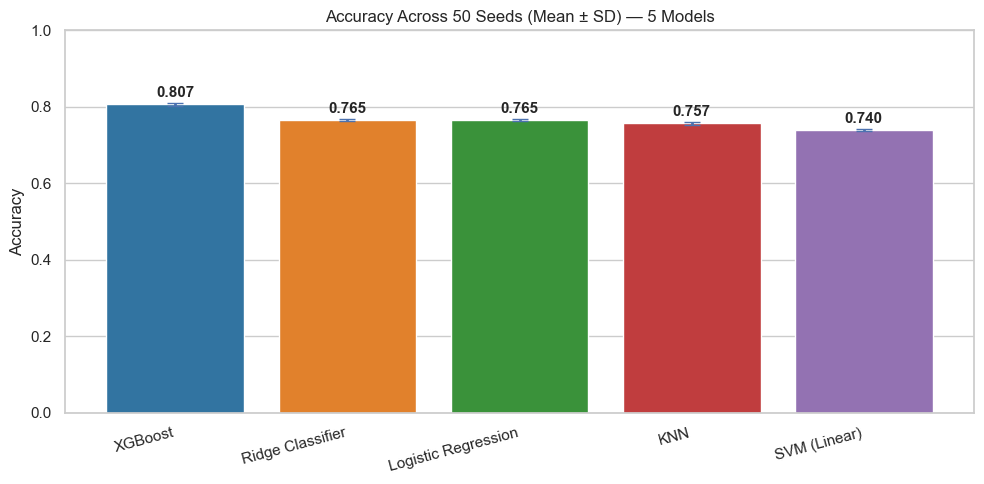

✅ Saved: /Users/matthewxia/Research/Alzheimer/5 model/run_20260210_213101/figures/accuracy_bar_5models_with_values.png


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- Locate latest run folder automatically ----
BASE_DIR = Path.home() / "Research" / "Alzheimer" / "5 model"
latest_run = sorted(BASE_DIR.glob("run_*"))[-1]

csv_path = latest_run / "tables" / "accuracy_summary_mean_sd_5models.csv"
acc_summary = pd.read_csv(csv_path)

# ---- Plot ----
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=acc_summary,
    x="Model",
    y="mean_acc",
    palette="tab10"
)

# Add error bars manually
ax.errorbar(
    x=np.arange(acc_summary.shape[0]),
    y=acc_summary["mean_acc"].values,
    yerr=acc_summary["sd_acc"].values,
    fmt="none",
    capsize=6,
    linewidth=2
)

# ---- Add mean accuracy numbers above bars ----
for i, row in acc_summary.iterrows():
    ax.text(
        i,
        row["mean_acc"] + 0.01,  # vertical offset
        f"{row['mean_acc']:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Accuracy Across 50 Seeds (Mean ± SD) — 5 Models")
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)

plt.tight_layout()

# Save updated figure
out_path = latest_run / "figures" / "accuracy_bar_5models_with_values.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("✅ Saved:", out_path)

In [4]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# =========================
# CONFIG
# =========================
BASE_DIR = Path.home() / "Research" / "Alzheimer"
DATA_PATH = BASE_DIR / "nacc_clean_complete_case_AD01.csv"
OUT_DIR = BASE_DIR / "heatmaps_release"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "NACCALZD"

# Drop policy (initial pass)
DROP_ID_AND_VISIT = [
    "NACCID", "NACCVNUM",
    "VISITYR", "VISITMO", "VISITDAY",
    "BIRTHMO"
]

DROP_LEAKAGE_OR_DIAGNOSIS = [
    "DEMENTED", "NACCTMCI", "NORMCOG",
    "ad_flag", "mci_flag", "dementia_flag"
]

DROP_ALWAYS = [TARGET] + DROP_ID_AND_VISIT + DROP_LEAKAGE_OR_DIAGNOSIS


# =========================
# LOAD
# =========================
df = pd.read_csv(DATA_PATH, low_memory=False)

cols_before = df.columns.tolist()
n_before = len(cols_before)

# Which of our drop candidates actually exist in this CSV?
drop_present = [c for c in DROP_ALWAYS if c in df.columns]

# Apply the drop
df_drop = df.drop(columns=drop_present, errors="ignore")

cols_after = df_drop.columns.tolist()
n_after = len(cols_after)

# Basic “what’s left” summary
numeric_cols = df_drop.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in cols_after if c not in numeric_cols]

print("=== DATASET AUDIT (BEFORE) ===")
print("Rows:", df.shape[0])
print("Total columns:", n_before)
print("First 40 columns:", cols_before[:40])

print("\n=== DROPPED (PRESENT IN FILE) ===")
print("Dropped count:", len(drop_present))
print(drop_present)

print("\n=== DATASET AUDIT (AFTER DROP) ===")
print("Total columns remaining:", n_after)
print("Numeric columns remaining:", len(numeric_cols))
print("Non-numeric columns remaining:", len(non_numeric_cols))
if non_numeric_cols:
    print("Non-numeric columns (will not be used in correlation unless encoded):")
    print(non_numeric_cols[:80])

# Save reduced dataset (keep only remaining columns; target removed by policy)
reduced_csv = OUT_DIR / "nacc_reduced_for_heatmaps_step1.csv"
df_drop.to_csv(reduced_csv, index=False)

# Save a manifest for reproducibility
manifest = {
    "source_csv": str(DATA_PATH),
    "reduced_csv": str(reduced_csv),
    "rows": int(df.shape[0]),
    "cols_before": int(n_before),
    "cols_after": int(n_after),
    "dropped_present": drop_present,
    "drop_policy": {
        "DROP_ID_AND_VISIT": DROP_ID_AND_VISIT,
        "DROP_LEAKAGE_OR_DIAGNOSIS": DROP_LEAKAGE_OR_DIAGNOSIS,
        "TARGET": TARGET
    },
    "numeric_cols_remaining": len(numeric_cols),
    "non_numeric_cols_remaining": len(non_numeric_cols),
    "non_numeric_cols_preview": non_numeric_cols[:200],
}
manifest_path = OUT_DIR / "manifest_reduction_step1.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("\n✅ Saved reduced dataset:", reduced_csv)
print("✅ Saved manifest:", manifest_path)

=== DATASET AUDIT (BEFORE) ===
Rows: 35635
Total columns: 64
First 40 columns: ['NACCID', 'NACCVNUM', 'VISITYR', 'VISITMO', 'VISITDAY', 'BIRTHYR', 'BIRTHMO', 'NACCAGE', 'SEX', 'RACE', 'HISPANIC', 'EDUC', 'HEIGHT', 'WEIGHT', 'NACCBMI', 'BPSYS', 'BPDIAS', 'TOBAC30', 'TOBAC100', 'SMOKYRS', 'PACKSPER', 'QUITSMOK', 'ALCOCCAS', 'ALCFREQ', 'ALCOHOL', 'ALCABUSE', 'APNEA', 'RBD', 'INSOMN', 'NACCFAM', 'NACCMOM', 'NACCDAD', 'DIABETES', 'HYPERTEN', 'HYPERCHO', 'AFIBRILL', 'CBSTROKE', 'CBTIA', 'TBI', 'TBIBRIEF']

=== DROPPED (PRESENT IN FILE) ===
Dropped count: 13
['NACCALZD', 'NACCID', 'NACCVNUM', 'VISITYR', 'VISITMO', 'VISITDAY', 'BIRTHMO', 'DEMENTED', 'NACCTMCI', 'NORMCOG', 'ad_flag', 'mci_flag', 'dementia_flag']

=== DATASET AUDIT (AFTER DROP) ===
Total columns remaining: 51
Numeric columns remaining: 50
Non-numeric columns remaining: 1
Non-numeric columns (will not be used in correlation unless encoded):
['sex_f']

✅ Saved reduced dataset: /Users/matthewxia/Research/Alzheimer/heatmaps_release/

In [5]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
df = pd.read_csv(BASE_DIR / "nacc_reduced_for_heatmaps_step1.csv")

cols = df.columns.tolist()

print(f"\nTotal remaining columns: {len(cols)}\n")

for i in range(0, len(cols), 8):
    print(cols[i:i+8])


Total remaining columns: 51

['BIRTHYR', 'NACCAGE', 'SEX', 'RACE', 'HISPANIC', 'EDUC', 'HEIGHT', 'WEIGHT']
['NACCBMI', 'BPSYS', 'BPDIAS', 'TOBAC30', 'TOBAC100', 'SMOKYRS', 'PACKSPER', 'QUITSMOK']
['ALCOCCAS', 'ALCFREQ', 'ALCOHOL', 'ALCABUSE', 'APNEA', 'RBD', 'INSOMN', 'NACCFAM']
['NACCMOM', 'NACCDAD', 'DIABETES', 'HYPERTEN', 'HYPERCHO', 'AFIBRILL', 'CBSTROKE', 'CBTIA']
['TBI', 'TBIBRIEF', 'TBIEXTEN', 'TBIYEAR', 'DEP', 'DEP2YRS', 'NACCGDS', 'NACCAPOE']
['NACCNE4S', 'AMYLPET', 'TAUPETAD', 'FDGAD', 'AMYLCSF', 'CSFTAU', 'NACCMMSE', 'NACCMOCA']
['CDRSUM', 'CDRGLOB', 'sex_f']


In [6]:
from pathlib import Path
import json
import pandas as pd

BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
df = pd.read_csv(BASE_DIR / "nacc_reduced_for_heatmaps_step1.csv")

DROP_FINAL = [
    "BIRTHYR",
    "HEIGHT", "WEIGHT",
    "TOBAC30", "TOBAC100", "PACKSPER",
    "ALCOCCAS", "ALCOHOL",
    "TBIBRIEF", "TBIYEAR",
    "DEP2YRS",
    "sex_f"
]

drop_present = [c for c in DROP_FINAL if c in df.columns]
df_final = df.drop(columns=drop_present, errors="ignore")

print("Columns dropped in final reduction:", drop_present)
print("Final column count:", df_final.shape[1])

final_csv = BASE_DIR / "nacc_reduced_for_heatmaps_FINAL.csv"
df_final.to_csv(final_csv, index=False)

manifest = {
    "source_step1": str(BASE_DIR / "nacc_reduced_for_heatmaps_step1.csv"),
    "final_dataset": str(final_csv),
    "dropped_final": drop_present,
    "final_column_count": int(df_final.shape[1]),
}
with open(BASE_DIR / "manifest_reduction_final.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("✅ Final reduced dataset saved:", final_csv)

Columns dropped in final reduction: ['BIRTHYR', 'HEIGHT', 'WEIGHT', 'TOBAC30', 'TOBAC100', 'PACKSPER', 'ALCOCCAS', 'ALCOHOL', 'TBIBRIEF', 'TBIYEAR', 'DEP2YRS', 'sex_f']
Final column count: 39
✅ Final reduced dataset saved: /Users/matthewxia/Research/Alzheimer/heatmaps_release/nacc_reduced_for_heatmaps_FINAL.csv


In [7]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
DATA_PATH = BASE_DIR / "nacc_reduced_for_heatmaps_FINAL.csv"

df = pd.read_csv(DATA_PATH)

# Use numeric columns only (this should be basically all 39 now)
X = df.select_dtypes(include=[np.number]).copy()
cols = X.columns.tolist()

# Spearman feature×feature correlation
corr = X.corr(method="spearman", min_periods=50)

# Extract off-diagonal values only
vals = corr.values
mask_offdiag = ~np.eye(vals.shape[0], dtype=bool)
offdiag = vals[mask_offdiag]
offdiag = offdiag[~np.isnan(offdiag)]

abs_offdiag = np.abs(offdiag)

# Summary stats to help choose scale
summary = {
    "n_rows": int(df.shape[0]),
    "n_cols_total": int(df.shape[1]),
    "n_cols_numeric": int(X.shape[1]),
    "min_corr_offdiag": float(np.min(offdiag)),
    "max_corr_offdiag": float(np.max(offdiag)),
    "p50_abs_offdiag": float(np.quantile(abs_offdiag, 0.50)),
    "p90_abs_offdiag": float(np.quantile(abs_offdiag, 0.90)),
    "p95_abs_offdiag": float(np.quantile(abs_offdiag, 0.95)),
    "p99_abs_offdiag": float(np.quantile(abs_offdiag, 0.99)),
}

print("=== Spearman off-diagonal correlation summary ===")
for k, v in summary.items():
    print(f"{k}: {v}")

# Choose a single symmetric color range for ALL heatmaps.
# Recommended: use the 95th percentile of |corr| so a few outliers don't wash out everything.
vmax = summary["p95_abs_offdiag"]
vmin = -vmax

scale = {
    "data_path": str(DATA_PATH),
    "method": "spearman",
    "min_periods": 50,
    "scale_strategy": "symmetric_±p95(|offdiag|)",
    "vmin": float(vmin),
    "vmax": float(vmax),
    "columns_used": cols
}

scale_path = BASE_DIR / "heatmap_color_scale.json"
with open(scale_path, "w") as f:
    json.dump({"summary": summary, "scale": scale}, f, indent=2)

print("\n✅ Saved global heatmap scale:", scale_path)
print(f"✅ Use vmin={vmin:.4f}, vmax={vmax:.4f} for ALL 5 heatmaps")

=== Spearman off-diagonal correlation summary ===
n_rows: 35635
n_cols_total: 39
n_cols_numeric: 39
min_corr_offdiag: -0.8218442667589225
max_corr_offdiag: 0.9983769112671435
p50_abs_offdiag: 0.08813045413917975
p90_abs_offdiag: 0.6816826815044179
p95_abs_offdiag: 0.8995524110075538
p99_abs_offdiag: 0.9876618474153572

✅ Saved global heatmap scale: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmap_color_scale.json
✅ Use vmin=-0.8996, vmax=0.8996 for ALL 5 heatmaps


In [8]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
DATA_PATH = BASE_DIR / "nacc_reduced_for_heatmaps_FINAL.csv"

df = pd.read_csv(DATA_PATH)

# Use numeric columns only (this should be basically all 39 now)
X = df.select_dtypes(include=[np.number]).copy()
cols = X.columns.tolist()

# Spearman feature×feature correlation
corr = X.corr(method="spearman", min_periods=50)

# Extract off-diagonal values only
vals = corr.values
mask_offdiag = ~np.eye(vals.shape[0], dtype=bool)
offdiag = vals[mask_offdiag]
offdiag = offdiag[~np.isnan(offdiag)]

abs_offdiag = np.abs(offdiag)

# Summary stats to help choose scale
summary = {
    "n_rows": int(df.shape[0]),
    "n_cols_total": int(df.shape[1]),
    "n_cols_numeric": int(X.shape[1]),
    "min_corr_offdiag": float(np.min(offdiag)),
    "max_corr_offdiag": float(np.max(offdiag)),
    "p50_abs_offdiag": float(np.quantile(abs_offdiag, 0.50)),
    "p90_abs_offdiag": float(np.quantile(abs_offdiag, 0.90)),
    "p95_abs_offdiag": float(np.quantile(abs_offdiag, 0.95)),
    "p99_abs_offdiag": float(np.quantile(abs_offdiag, 0.99)),
}

print("=== Spearman off-diagonal correlation summary ===")
for k, v in summary.items():
    print(f"{k}: {v}")

# Choose a single symmetric color range for ALL heatmaps.
# Recommended: use the 95th percentile of |corr| so a few outliers don't wash out everything.
vmax = summary["p95_abs_offdiag"]
vmin = -vmax

scale = {
    "data_path": str(DATA_PATH),
    "method": "spearman",
    "min_periods": 50,
    "scale_strategy": "symmetric_±p95(|offdiag|)",
    "vmin": float(vmin),
    "vmax": float(vmax),
    "columns_used": cols
}

scale_path = BASE_DIR / "heatmap_color_scale.json"
with open(scale_path, "w") as f:
    json.dump({"summary": summary, "scale": scale}, f, indent=2)

print("\n✅ Saved global heatmap scale:", scale_path)
print(f"✅ Use vmin={vmin:.4f}, vmax={vmax:.4f} for ALL 5 heatmaps")

=== Spearman off-diagonal correlation summary ===
n_rows: 35635
n_cols_total: 39
n_cols_numeric: 39
min_corr_offdiag: -0.8218442667589225
max_corr_offdiag: 0.9983769112671435
p50_abs_offdiag: 0.08813045413917975
p90_abs_offdiag: 0.6816826815044179
p95_abs_offdiag: 0.8995524110075538
p99_abs_offdiag: 0.9876618474153572

✅ Saved global heatmap scale: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmap_color_scale.json
✅ Use vmin=-0.8996, vmax=0.8996 for ALL 5 heatmaps


In [9]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier


# =========================
# PATHS
# =========================
BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
DATA_PATH = BASE_DIR / "nacc_reduced_for_heatmaps_FINAL.csv"
SCALE_PATH = BASE_DIR / "heatmap_color_scale.json"

OUT_DIR = BASE_DIR / "heatmaps_oof_release"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# LOAD DATA
# =========================
df = pd.read_csv(DATA_PATH)
# Use numeric columns only (should be all 39)
X = df.select_dtypes(include=[np.number]).copy()

# If the label accidentally remains in the final file, drop it from features (safe guard)
for maybe_target in ["NACCALZD", "target", "y"]:
    if maybe_target in X.columns:
        X = X.drop(columns=[maybe_target])

feature_names = X.columns.tolist()
print("✅ Loaded FINAL heatmap dataset:", DATA_PATH)
print("Rows:", X.shape[0], "Features:", X.shape[1])


# =========================
# LOAD GLOBAL COLOR SCALE
# =========================
with open(SCALE_PATH, "r") as f:
    scale_json = json.load(f)

vmin = float(scale_json["scale"]["vmin"])
vmax = float(scale_json["scale"]["vmax"])
print(f"✅ Using fixed color range for ALL heatmaps: vmin={vmin:.4f}, vmax={vmax:.4f}")


# =========================
# OOF SETTINGS
# =========================
N_SPLITS = 5
CV_SEED = 42
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

# IMPORTANT: You must define y. If your FINAL dataset does NOT include label, load label from original CSV.
# In your earlier runs, label was NACCALZD. If it's not in df, load from original and align rows.
if "NACCALZD" in df.columns:
    y = df["NACCALZD"].astype(int).to_numpy()
else:
    raise ValueError("NACCALZD not found in FINAL dataset. If you want OOF redundancy, we need y present.")


# =========================
# MODEL BUILDERS (FAST + STABLE)
# =========================
def build_models(seed=0):
    # Keep these “OOF-friendly”: no probability=True SVC (too slow)
    return {
        "XGBoost": XGBClassifier(
            tree_method="hist",
            random_state=seed,
            n_estimators=250,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1
        ),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=4000, solver="lbfgs", random_state=seed))
        ]),
        "Ridge Classifier": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RidgeClassifier(random_state=seed))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5))
        ]),
        # FAST linear margin model; we’ll use decision_function as the score
        "SVM (Linear)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(random_state=seed))
        ]),
    }

MODEL_ORDER = ["XGBoost", "Ridge Classifier", "Logistic Regression", "KNN", "SVM (Linear)"]


# =========================
# SCORE EXTRACTION (works across model types)
# =========================
def get_continuous_score(fitted_model, X_test_1col):
    """
    Returns a continuous score vector for Spearman correlation.
    Priority:
      predict_proba[:,1] -> decision_function -> predict (as fallback)
    """
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_test_1col)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        s = fitted_model.decision_function(X_test_1col)
        # Ensure 1D
        s = np.asarray(s).ravel()
        return s
    # fallback: discrete labels (less ideal but still works)
    return fitted_model.predict(X_test_1col).astype(float)


def compute_oof_scores_single_feature(model, X_all, y_all, feat_idx):
    """
    OOF scores for ONE feature column using StratifiedKFold.
    """
    scores = np.full(shape=(X_all.shape[0],), fill_value=np.nan, dtype=float)
    xcol = X_all[:, [feat_idx]]  # keep as 2D

    for tr, te in skf.split(xcol, y_all):
        Xtr, Xte = xcol[tr], xcol[te]
        ytr = y_all[tr]

        m = model
        m.fit(Xtr, ytr)
        scores[te] = get_continuous_score(m, Xte)

    return scores


def save_checkpoint(path, arr, done_mask, feature_names):
    np.save(path.with_suffix(".npy"), arr)
    np.save(path.with_suffix(".done.npy"), done_mask.astype(np.uint8))
    (path.with_suffix(".cols.json")).write_text(json.dumps(feature_names, indent=2))


def load_checkpoint(path, n_rows, n_feats):
    npy = path.with_suffix(".npy")
    done = path.with_suffix(".done.npy")
    if npy.exists() and done.exists():
        arr = np.load(npy)
        done_mask = np.load(done).astype(bool)
        if arr.shape == (n_rows, n_feats) and done_mask.shape == (n_feats,):
            return arr, done_mask
    return None, None

✅ Loaded FINAL heatmap dataset: /Users/matthewxia/Research/Alzheimer/heatmaps_release/nacc_reduced_for_heatmaps_FINAL.csv
Rows: 35635 Features: 39
✅ Using fixed color range for ALL heatmaps: vmin=-0.8996, vmax=0.8996


ValueError: NACCALZD not found in FINAL dataset. If you want OOF redundancy, we need y present.

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_ROOT = Path.home() / "Research" / "Alzheimer"
ORIG_PATH = BASE_ROOT / "nacc_clean_complete_case_AD01.csv"

df_orig = pd.read_csv(ORIG_PATH, low_memory=False)

# IMPORTANT: assume FINAL was produced by dropping columns only (no row reordering)
if len(df_orig) != len(df):
    raise ValueError(f"Row mismatch: original has {len(df_orig)} rows, FINAL has {len(df)} rows. "
                     "We need an ID column to align if lengths differ.")

if "NACCALZD" not in df_orig.columns:
    raise ValueError("NACCALZD not found in original dataset either.")

y = df_orig["NACCALZD"].astype(int).to_numpy()

print("✅ Loaded y from original CSV (row-aligned). Positive rate:", float(np.mean(y==1)))

✅ Loaded y from original CSV (row-aligned). Positive rate: 0.7217903746316824


In [11]:
from scipy.stats import spearmanr

X_np = X.to_numpy(dtype=np.float32)
y_np = y.astype(np.int32)

print("\n✅ Starting OOF redundancy heatmaps run")
print("Models:", MODEL_ORDER)
print("Features:", len(feature_names))

# Save run metadata
run_meta = {
    "data_path": str(DATA_PATH),
    "scale_path": str(SCALE_PATH),
    "vmin": vmin,
    "vmax": vmax,
    "n_splits": N_SPLITS,
    "cv_seed": CV_SEED,
    "models": MODEL_ORDER,
    "features": feature_names
}
with open(OUT_DIR / "run_manifest.json", "w") as f:
    json.dump(run_meta, f, indent=2)

# How often to checkpoint (every K features)
CHECKPOINT_EVERY = 5

outer = tqdm(MODEL_ORDER, desc="Models", leave=True)

for model_name in outer:
    outer.set_postfix_str(model_name)

    # Prepare model instance (seed fixed for reproducibility)
    model = build_models(seed=0)[model_name]

    # Checkpoint paths
    ckpt_base = CHECKPOINT_DIR / f"oof_{model_name.replace(' ','_').replace('(','').replace(')','')}"
    oof, done_mask = load_checkpoint(ckpt_base, n_rows=X_np.shape[0], n_feats=X_np.shape[1])

    if oof is None:
        oof = np.full((X_np.shape[0], X_np.shape[1]), np.nan, dtype=float)
        done_mask = np.zeros((X_np.shape[1],), dtype=bool)

    # Inner progress bar over features
    feats = list(range(X_np.shape[1]))
    inner = tqdm(feats, desc=f"{model_name}: features", leave=False)

    completed_this_model = int(done_mask.sum())
    inner.set_postfix({"done": f"{completed_this_model}/{len(feats)}"})

    for j in inner:
        if done_mask[j]:
            continue

        # Compute OOF scores for this feature
        scores = compute_oof_scores_single_feature(model, X_np, y_np, feat_idx=j)
        oof[:, j] = scores
        done_mask[j] = True

        # checkpoint periodically
        if int(done_mask.sum()) % CHECKPOINT_EVERY == 0:
            save_checkpoint(ckpt_base, oof, done_mask, feature_names)

        inner.set_postfix({"done": f"{int(done_mask.sum())}/{len(feats)}"})

    # Final save checkpoint for the model
    save_checkpoint(ckpt_base, oof, done_mask, feature_names)

    # Convert OOF score matrix to DataFrame and compute Spearman feature×feature redundancy
    oof_df = pd.DataFrame(oof, columns=feature_names)

    # Spearman correlation between columns (pairwise, handles NaNs)
    corr = oof_df.corr(method="spearman", min_periods=50)

    # Save correlation matrix CSV
    corr_csv = OUT_DIR / f"heatmap_corr_{model_name.replace(' ','_').replace('(','').replace(')','')}.csv"
    corr.to_csv(corr_csv)
    print("✅ Saved corr matrix:", corr_csv)

    # Save OOF scores (optional but great for reproducibility/debugging)
    oof_csv = OUT_DIR / f"oof_scores_{model_name.replace(' ','_').replace('(','').replace(')','')}.csv"
    oof_df.to_csv(oof_csv, index=False)
    print("✅ Saved OOF scores:", oof_csv)

    # NOTE: You asked earlier “don’t give heatmap code yet” — but now you explicitly asked for codes.
    # This section SAVES everything needed; next cell will render heatmaps with fixed vmin/vmax + no tick skipping.


✅ Starting OOF redundancy heatmaps run
Models: ['XGBoost', 'Logistic Regression', 'Ridge Classifier', 'KNN', 'SVM (Linear)']
Features: 39


Models:   0%|          | 0/5 [00:00<?, ?it/s]

NameError: name 'load_checkpoint' is not defined

In [12]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier


# =========================
# PATHS
# =========================
BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
DATA_PATH = BASE_DIR / "nacc_reduced_for_heatmaps_FINAL.csv"
SCALE_PATH = BASE_DIR / "heatmap_color_scale.json"

OUT_DIR = BASE_DIR / "heatmaps_oof_release"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# LOAD DATA
# =========================
df = pd.read_csv(DATA_PATH)
# Use numeric columns only (should be all 39)
X = df.select_dtypes(include=[np.number]).copy()

# If the label accidentally remains in the final file, drop it from features (safe guard)
for maybe_target in ["NACCALZD", "target", "y"]:
    if maybe_target in X.columns:
        X = X.drop(columns=[maybe_target])

feature_names = X.columns.tolist()
print("✅ Loaded FINAL heatmap dataset:", DATA_PATH)
print("Rows:", X.shape[0], "Features:", X.shape[1])


# =========================
# LOAD GLOBAL COLOR SCALE
# =========================
with open(SCALE_PATH, "r") as f:
    scale_json = json.load(f)

vmin = float(scale_json["scale"]["vmin"])
vmax = float(scale_json["scale"]["vmax"])
print(f"✅ Using fixed color range for ALL heatmaps: vmin={vmin:.4f}, vmax={vmax:.4f}")


# =========================
# OOF SETTINGS
# =========================
N_SPLITS = 5
CV_SEED = 42
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

# IMPORTANT: You must define y. If your FINAL dataset does NOT include label, load label from original CSV.
# In your earlier runs, label was NACCALZD. If it's not in df, load from original and align rows.
if "NACCALZD" in df.columns:
    y = df["NACCALZD"].astype(int).to_numpy()
else:
    raise ValueError("NACCALZD not found in FINAL dataset. If you want OOF redundancy, we need y present.")


# =========================
# MODEL BUILDERS (FAST + STABLE)
# =========================
def build_models(seed=0):
    # Keep these “OOF-friendly”: no probability=True SVC (too slow)
    return {
        "XGBoost": XGBClassifier(
            tree_method="hist",
            random_state=seed,
            n_estimators=250,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1
        ),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=4000, solver="lbfgs", random_state=seed))
        ]),
        "Ridge Classifier": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RidgeClassifier(random_state=seed))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5))
        ]),
        # FAST linear margin model; we’ll use decision_function as the score
        "SVM (Linear)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(random_state=seed))
        ]),
    }

MODEL_ORDER = ["XGBoost", "Ridge Classifier", "Logistic Regression", "KNN", "SVM (Linear)"]


# =========================
# SCORE EXTRACTION (works across model types)
# =========================
def get_continuous_score(fitted_model, X_test_1col):
    """
    Returns a continuous score vector for Spearman correlation.
    Priority:
      predict_proba[:,1] -> decision_function -> predict (as fallback)
    """
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_test_1col)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        s = fitted_model.decision_function(X_test_1col)
        # Ensure 1D
        s = np.asarray(s).ravel()
        return s
    # fallback: discrete labels (less ideal but still works)
    return fitted_model.predict(X_test_1col).astype(float)


def compute_oof_scores_single_feature(model, X_all, y_all, feat_idx):
    """
    OOF scores for ONE feature column using StratifiedKFold.
    """
    scores = np.full(shape=(X_all.shape[0],), fill_value=np.nan, dtype=float)
    xcol = X_all[:, [feat_idx]]  # keep as 2D

    for tr, te in skf.split(xcol, y_all):
        Xtr, Xte = xcol[tr], xcol[te]
        ytr = y_all[tr]

        m = model
        m.fit(Xtr, ytr)
        scores[te] = get_continuous_score(m, Xte)

    return scores


def save_checkpoint(path, arr, done_mask, feature_names):
    np.save(path.with_suffix(".npy"), arr)
    np.save(path.with_suffix(".done.npy"), done_mask.astype(np.uint8))
    (path.with_suffix(".cols.json")).write_text(json.dumps(feature_names, indent=2))


def load_checkpoint(path, n_rows, n_feats):
    npy = path.with_suffix(".npy")
    done = path.with_suffix(".done.npy")
    if npy.exists() and done.exists():
        arr = np.load(npy)
        done_mask = np.load(done).astype(bool)
        if arr.shape == (n_rows, n_feats) and done_mask.shape == (n_feats,):
            return arr, done_mask
    return None, None

✅ Loaded FINAL heatmap dataset: /Users/matthewxia/Research/Alzheimer/heatmaps_release/nacc_reduced_for_heatmaps_FINAL.csv
Rows: 35635 Features: 39
✅ Using fixed color range for ALL heatmaps: vmin=-0.8996, vmax=0.8996


ValueError: NACCALZD not found in FINAL dataset. If you want OOF redundancy, we need y present.

In [13]:
# ============================================================
# OOF REDUNDANCY HEATMAPS — 5 MODELS — RELEASE VERSION
# - Data: ~/Research/Alzheimer/heatmaps_release/nacc_reduced_for_heatmaps_FINAL.csv  (39 features)
# - Label y loaded from: ~/Research/Alzheimer/nacc_clean_complete_case_AD01.csv (row-aligned)
# - 5-fold Stratified OOF per feature: each feature -> model -> OOF score vector
# - Redundancy = Spearman correlation across feature OOF score vectors (Feature×Feature)
# - Fixed global heatmap color scale loaded from: heatmap_color_scale.json  (vmin/vmax)
# - Saves checkpoints so runs can resume after crash
# - Saves: OOF CSV + corr CSV + PNG heatmaps (masked upper triangle, rotated x labels)
# ============================================================

import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
FINAL_X_PATH = BASE_DIR / "nacc_reduced_for_heatmaps_FINAL.csv"
SCALE_PATH   = BASE_DIR / "heatmap_color_scale.json"

ORIG_PATH = Path.home() / "Research" / "Alzheimer" / "nacc_clean_complete_case_AD01.csv"

OUT_DIR = BASE_DIR / "heatmaps_oof_release"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = OUT_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# LOAD X (FINAL 39 vars)
# -------------------------
dfX = pd.read_csv(FINAL_X_PATH)
X_df = dfX.select_dtypes(include=[np.number]).copy()

# Safety: if any target accidentally present, drop
for maybe_target in ["NACCALZD", "target", "y"]:
    if maybe_target in X_df.columns:
        X_df = X_df.drop(columns=[maybe_target])

feature_names = X_df.columns.tolist()
print("✅ Loaded X:", FINAL_X_PATH)
print("Rows:", X_df.shape[0], "Features:", X_df.shape[1])

# -------------------------
# LOAD y FROM ORIGINAL (row-aligned)
# -------------------------
df_orig = pd.read_csv(ORIG_PATH, low_memory=False)

if len(df_orig) != len(dfX):
    raise ValueError(
        f"Row mismatch: original has {len(df_orig)} rows, FINAL has {len(dfX)} rows. "
        "Row alignment is unsafe without an ID column. "
        "Fix: regenerate FINAL with an ID column (e.g., NACCID/NACCVNUM) so we can merge."
    )

if "NACCALZD" not in df_orig.columns:
    raise ValueError("NACCALZD not found in original dataset.")

y = df_orig["NACCALZD"].astype(int).to_numpy()
print("✅ Loaded y from original (row-aligned). Positive rate:", float(np.mean(y == 1)))

# -------------------------
# LOAD GLOBAL COLOR SCALE
# -------------------------
with open(SCALE_PATH, "r") as f:
    scale_json = json.load(f)

vmin = float(scale_json["scale"]["vmin"])
vmax = float(scale_json["scale"]["vmax"])
print(f"✅ Using fixed color range for ALL heatmaps: vmin={vmin:.4f}, vmax={vmax:.4f}")

# -------------------------
# CV SETTINGS
# -------------------------
N_SPLITS = 5
CV_SEED = 42
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

# Convert once for speed
X_np = X_df.to_numpy(dtype=np.float32)
y_np = y.astype(np.int32)

# -------------------------
# MODEL BUILDERS (OOF-friendly; SVM LAST; NO probability=True)
# -------------------------
def build_models(seed=0):
    return {
        "XGBoost": XGBClassifier(
            tree_method="hist",
            random_state=seed,
            n_estimators=250,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1
        ),
        "Ridge Classifier": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RidgeClassifier(random_state=seed))
        ]),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=4000, solver="lbfgs", random_state=seed))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5))
        ]),
        # SVM LAST (fast linear margin scores via decision_function)
        "SVM (Linear)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(random_state=seed))
        ]),
    }

MODEL_ORDER = ["XGBoost", "Ridge Classifier", "Logistic Regression", "KNN", "SVM (Linear)"]

# -------------------------
# CHECKPOINT HELPERS
# -------------------------
def save_checkpoint(path, arr, done_mask, feature_names):
    np.save(path.with_suffix(".npy"), arr)
    np.save(path.with_suffix(".done.npy"), done_mask.astype(np.uint8))
    (path.with_suffix(".cols.json")).write_text(json.dumps(feature_names, indent=2))

def load_checkpoint(path, n_rows, n_feats):
    npy = path.with_suffix(".npy")
    done = path.with_suffix(".done.npy")
    if npy.exists() and done.exists():
        arr = np.load(npy)
        done_mask = np.load(done).astype(bool)
        if arr.shape == (n_rows, n_feats) and done_mask.shape == (n_feats,):
            return arr, done_mask
    return None, None

# -------------------------
# SCORE EXTRACTION
# -------------------------
def get_continuous_score(fitted_model, X_test_1col):
    # prefer probabilities when available, otherwise margin scores
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_test_1col)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return np.asarray(fitted_model.decision_function(X_test_1col)).ravel()
    return fitted_model.predict(X_test_1col).astype(float)

def compute_oof_scores_single_feature(model, X_all, y_all, feat_idx):
    scores = np.full(shape=(X_all.shape[0],), fill_value=np.nan, dtype=float)
    xcol = X_all[:, [feat_idx]]  # 2D

    for tr, te in skf.split(xcol, y_all):
        Xtr, Xte = xcol[tr], xcol[te]
        ytr = y_all[tr]

        m = model
        m.fit(Xtr, ytr)
        scores[te] = get_continuous_score(m, Xte)

    return scores

# -------------------------
# HEATMAP PLOTTING (no skipping, rotated labels, masked upper triangle)
# -------------------------
def plot_corr_heatmap(corr: pd.DataFrame, title: str, out_png: Path, vmin: float, vmax: float):
    mat = corr.values.astype(float)

    # mask upper triangle (duplicate half)
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    mat_masked = mat.copy()
    mat_masked[mask] = np.nan

    n = corr.shape[0]
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(mat_masked, cmap="coolwarm", vmin=vmin, vmax=vmax)

    # force ALL tick labels (no skipping)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(corr.columns, rotation=60, ha="right", fontsize=9)
    ax.set_yticklabels(corr.index, fontsize=9)

    ax.set_title(title, fontsize=16, weight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Spearman correlation (OOF redundancy)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# -------------------------
# RUN MANIFEST
# -------------------------
run_manifest = {
    "final_x_path": str(FINAL_X_PATH),
    "orig_y_path": str(ORIG_PATH),
    "n_rows": int(X_np.shape[0]),
    "n_features": int(X_np.shape[1]),
    "features": feature_names,
    "cv": {"n_splits": N_SPLITS, "seed": CV_SEED},
    "models": MODEL_ORDER,
    "color_scale": {"vmin": vmin, "vmax": vmax, "scale_path": str(SCALE_PATH)},
    "checkpoint_dir": str(CHECKPOINT_DIR),
    "out_dir": str(OUT_DIR),
}
with open(OUT_DIR / "run_manifest.json", "w") as f:
    json.dump(run_manifest, f, indent=2)
print("✅ Saved run manifest:", OUT_DIR / "run_manifest.json")

# -------------------------
# MAIN LOOP (models × features) with tqdm + checkpoints
# -------------------------
CHECKPOINT_EVERY = 5  # save every 5 features
print("\n✅ Starting OOF redundancy heatmaps run")
print("Models:", MODEL_ORDER)
print("Features:", len(feature_names))

outer = tqdm(MODEL_ORDER, desc="Models", leave=True)

for model_name in outer:
    outer.set_postfix_str(model_name)

    model = build_models(seed=0)[model_name]

    safe = model_name.replace(" ", "_").replace("(", "").replace(")", "")
    ckpt_base = CHECKPOINT_DIR / f"oof_{safe}"

    oof, done_mask = load_checkpoint(ckpt_base, n_rows=X_np.shape[0], n_feats=X_np.shape[1])
    if oof is None:
        oof = np.full((X_np.shape[0], X_np.shape[1]), np.nan, dtype=float)
        done_mask = np.zeros((X_np.shape[1],), dtype=bool)

    inner = tqdm(range(X_np.shape[1]), desc=f"{model_name}: features", leave=False)
    inner.set_postfix({"done": f"{int(done_mask.sum())}/{X_np.shape[1]}"})

    for j in inner:
        if done_mask[j]:
            continue

        scores = compute_oof_scores_single_feature(model, X_np, y_np, feat_idx=j)
        oof[:, j] = scores
        done_mask[j] = True

        if int(done_mask.sum()) % CHECKPOINT_EVERY == 0:
            save_checkpoint(ckpt_base, oof, done_mask, feature_names)

        inner.set_postfix({"done": f"{int(done_mask.sum())}/{X_np.shape[1]}"})

    # final checkpoint
    save_checkpoint(ckpt_base, oof, done_mask, feature_names)

    # save OOF scores
    oof_df = pd.DataFrame(oof, columns=feature_names)
    oof_csv = TABLE_DIR / f"oof_scores_{safe}.csv"
    oof_df.to_csv(oof_csv, index=False)
    print("✅ Saved OOF scores:", oof_csv)

    # compute Spearman redundancy matrix
    corr = oof_df.corr(method="spearman", min_periods=50)

    corr_csv = TABLE_DIR / f"heatmap_corr_{safe}.csv"
    corr.to_csv(corr_csv)
    print("✅ Saved corr matrix:", corr_csv)

    # plot heatmap PNG
    out_png = FIG_DIR / f"heatmap_{safe}_OOF_spearman.png"
    plot_corr_heatmap(
        corr=corr,
        title=f"{model_name} — Spearman OOF Redundancy (Feature×Feature)",
        out_png=out_png,
        vmin=vmin,
        vmax=vmax
    )
    print("✅ Saved heatmap PNG:", out_png)

print("\n✅ DONE. Outputs saved to:", OUT_DIR)
print(" - tables/: OOF scores + corr matrices")
print(" - figures/: heatmap PNGs")
print(" - checkpoints/: resumable intermediate arrays")

✅ Loaded X: /Users/matthewxia/Research/Alzheimer/heatmaps_release/nacc_reduced_for_heatmaps_FINAL.csv
Rows: 35635 Features: 39
✅ Loaded y from original (row-aligned). Positive rate: 0.7217903746316824
✅ Using fixed color range for ALL heatmaps: vmin=-0.8996, vmax=0.8996
✅ Saved run manifest: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/run_manifest.json

✅ Starting OOF redundancy heatmaps run
Models: ['XGBoost', 'Ridge Classifier', 'Logistic Regression', 'KNN', 'SVM (Linear)']
Features: 39


Models:   0%|          | 0/5 [00:00<?, ?it/s]

XGBoost: features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/tables/oof_scores_XGBoost.csv
✅ Saved corr matrix: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/tables/heatmap_corr_XGBoost.csv
✅ Saved heatmap PNG: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/figures/heatmap_XGBoost_OOF_spearman.png


Ridge Classifier: features:   0%|          | 0/39 [00:00<?, ?it/s]

...

✅ Saved OOF scores: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/tables/oof_scores_Logistic_Regression.csv
✅ Saved corr matrix: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/tables/heatmap_corr_Logistic_Regression.csv
✅ Saved heatmap PNG: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/figures/heatmap_Logistic_Regression_OOF_spearman.png


KNN: features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/tables/oof_scores_KNN.csv
✅ Saved corr matrix: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/tables/heatmap_corr_KNN.csv
✅ Saved heatmap PNG: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/figures/heatmap_KNN_OOF_spearman.png


SVM (Linear): features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/tables/oof_scores_SVM_Linear.csv
✅ Saved corr matrix: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/tables/heatmap_corr_SVM_Linear.csv
✅ Saved heatmap PNG: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/figures/heatmap_SVM_Linear_OOF_spearman.png

✅ DONE. Outputs saved to: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release
 - tables/: OOF scores + corr matrices
 - figures/: heatmap PNGs
 - checkpoints/: resumable intermediate arrays


In [14]:
import json
import numpy as np
from pathlib import Path

BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
OUT_DIR = BASE_DIR / "heatmaps_oof_release"
CHECKPOINT_DIR = OUT_DIR / "checkpoints"

MODEL_ORDER = ["XGBoost", "Ridge Classifier", "Logistic Regression", "KNN", "SVM (Linear)"]

def safe_name(model_name: str) -> str:
    return model_name.replace(" ", "_").replace("(", "").replace(")", "")

print("Checkpoint dir:", CHECKPOINT_DIR)
print("Exists:", CHECKPOINT_DIR.exists(), "\n")

for model_name in MODEL_ORDER:
    safe = safe_name(model_name)
    done_path = CHECKPOINT_DIR / f"oof_{safe}.done.npy"
    arr_path  = CHECKPOINT_DIR / f"oof_{safe}.npy"
    cols_path = CHECKPOINT_DIR / f"oof_{safe}.cols.json"

    if done_path.exists():
        done = np.load(done_path).astype(bool)
        n_done = int(done.sum())
        n_total = int(done.shape[0])
        cols_ok = cols_path.exists()

        print(f"{model_name:20s}  ✅ {n_done}/{n_total} features done"
              f"   | oof.npy: {arr_path.exists()} | cols.json: {cols_ok}")
    else:
        print(f"{model_name:20s}  ❌ no checkpoint yet")

Checkpoint dir: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_release/checkpoints
Exists: True 

XGBoost               ✅ 39/39 features done   | oof.npy: True | cols.json: True
Ridge Classifier      ✅ 39/39 features done   | oof.npy: True | cols.json: True
Logistic Regression   ✅ 39/39 features done   | oof.npy: True | cols.json: True
KNN                   ✅ 39/39 features done   | oof.npy: True | cols.json: True
SVM (Linear)          ✅ 39/39 features done   | oof.npy: True | cols.json: True


In [15]:
# ============================================================
# OOF SPEARMAN REDUNDANCY HEATMAPS — OLD-STYLE MATCH — 5 MODELS
# - Matches prior logic: imputer+cross_val_predict+MinMax fallback+vlim=0.07
# - Saves to a NEW folder so prior outputs are untouched
# ============================================================

import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

from xgboost import XGBClassifier

# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
FINAL_X_PATH = BASE_DIR / "nacc_reduced_for_heatmaps_FINAL.csv"
ORIG_PATH    = Path.home() / "Research" / "Alzheimer" / "nacc_clean_complete_case_AD01.csv"

# NEW output folder (does not overwrite your other run)
OUT_DIR = BASE_DIR / "heatmaps_oof_oldstyle_5models_rerun"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = OUT_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("✅ OUT_DIR:", OUT_DIR)

# -------------------------
# LOAD X (FINAL 39 vars)
# -------------------------
dfX = pd.read_csv(FINAL_X_PATH)
X_df = dfX.select_dtypes(include=[np.number]).copy()

# Safety: if any target accidentally present, drop
for maybe_target in ["NACCALZD", "target", "y"]:
    if maybe_target in X_df.columns:
        X_df = X_df.drop(columns=[maybe_target])

feature_names = X_df.columns.tolist()
print("✅ Loaded X:", FINAL_X_PATH)
print("Rows:", X_df.shape[0], "Features:", X_df.shape[1])

# -------------------------
# LOAD y FROM ORIGINAL (row-aligned)
# -------------------------
df_orig = pd.read_csv(ORIG_PATH, low_memory=False)

if len(df_orig) != len(dfX):
    raise ValueError(
        f"Row mismatch: original has {len(df_orig)} rows, FINAL has {len(dfX)} rows. "
        "Row alignment is unsafe without an ID column."
    )

if "NACCALZD" not in df_orig.columns:
    raise ValueError("NACCALZD not found in original dataset.")

y = df_orig["NACCALZD"].astype(int).to_numpy()
print("✅ Loaded y from original (row-aligned). Positive rate:", float(np.mean(y == 1)))

# -------------------------
# CV SETTINGS (same as before)
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------
# MODELS (OLD STYLE)
# -------------------------
models_for_oof = {
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric="logloss", n_jobs=-1, tree_method="hist",
            random_state=42
        ))
    ]),
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVM (Linear)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", svm.SVC(kernel="linear", probability=True, random_state=42))
    ]),
    "Ridge Classifier": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", RidgeClassifier(random_state=42))
    ]),
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
}

MODEL_ORDER = ["XGBoost", "Ridge Classifier", "Logistic Regression", "KNN", "SVM (Linear)"]

# -------------------------
# CHECKPOINT HELPERS (per model)
# -------------------------
def safe_name(model_name: str) -> str:
    return model_name.replace(" ", "_").replace("(", "").replace(")", "")

def ckpt_paths(model_name: str):
    safe = safe_name(model_name)
    return (
        CHECKPOINT_DIR / f"oof_{safe}.pkl",     # dataframe pickle
        CHECKPOINT_DIR / f"oof_{safe}.done.json" # done features list
    )

def load_checkpoint(model_name: str, feature_names_now):
    pkl_path, done_path = ckpt_paths(model_name)
    if pkl_path.exists() and done_path.exists():
        oof_df = pd.read_pickle(pkl_path)
        done_feats = json.loads(done_path.read_text())
        # safety: if columns mismatch, ignore
        if list(oof_df.columns) != feature_names_now:
            print(f"⚠️ Columns changed for {model_name}. Ignoring checkpoint.")
            return None, set()
        return oof_df, set(done_feats)
    return None, set()

def save_checkpoint(model_name: str, oof_df: pd.DataFrame, done_feats: set):
    pkl_path, done_path = ckpt_paths(model_name)
    oof_df.to_pickle(pkl_path)
    done_path.write_text(json.dumps(sorted(list(done_feats)), indent=2))

# -------------------------
# OLD-STYLE OOF SCORE PER FEATURE (cross_val_predict + fallbacks)
# -------------------------
def oof_scores_single_feature(pipeline, feat_name: str, X_df: pd.DataFrame, y_vec, cv):
    Xi = X_df[[feat_name]]
    try:
        s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="predict_proba")[:, 1]
        return s.astype(float)
    except Exception:
        pass

    try:
        s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="decision_function")
        s = MinMaxScaler().fit_transform(np.asarray(s).reshape(-1, 1)).ravel()
        return s.astype(float)
    except Exception:
        pass

    s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="predict").astype(float)
    return s.astype(float)

# -------------------------
# HEATMAP (OLD STYLE: full matrix, diagonal NaN, vlim=0.07)
# -------------------------
def save_heatmap_png_oldstyle(corr_df: pd.DataFrame, model_name: str, out_png: Path, vlim: float = 0.07):
    corr_plot = corr_df.copy()
    np.fill_diagonal(corr_plot.values, np.nan)

    cmap = plt.cm.get_cmap("coolwarm").copy()
    cmap.set_bad("white")

    plt.figure(figsize=(14, 12))
    ax = sns.heatmap(
        corr_plot,
        cmap=cmap,
        vmin=-vlim, vmax=vlim, center=0,
        square=True,
        cbar=True,
        linewidths=0.4, linecolor="white",
        annot=False
    )
    ax.set_title(f"{model_name} — Spearman OOF Redundancy (Feature×Feature)", fontsize=14, pad=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# -------------------------
# RUN MANIFEST
# -------------------------
manifest = {
    "style": "old_style_match_cross_val_predict_imputer_minmax_vlim007_fullmatrix",
    "final_x_path": str(FINAL_X_PATH),
    "orig_y_path": str(ORIG_PATH),
    "n_rows": int(X_df.shape[0]),
    "n_features": int(X_df.shape[1]),
    "features": feature_names,
    "cv": {"n_splits": 5, "shuffle": True, "random_state": 42},
    "models": MODEL_ORDER,
    "vlim": 0.07,
    "out_dir": str(OUT_DIR),
}
(OUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2))
print("✅ Saved run manifest:", OUT_DIR / "run_manifest.json")

# -------------------------
# MAIN LOOP (tqdm + checkpoints)
# -------------------------
CHECKPOINT_EVERY = 5  # save every 5 features

print("\n✅ Starting OLD-STYLE OOF redundancy heatmaps rerun (5 models)")
outer = tqdm(MODEL_ORDER, desc="Models", leave=True)

for model_name in outer:
    outer.set_postfix_str(model_name)
    pipe = models_for_oof[model_name]

    # load/resume
    oof_df, done_feats = load_checkpoint(model_name, feature_names)
    if oof_df is None:
        oof_df = pd.DataFrame(index=np.arange(len(y)), columns=feature_names, dtype=float)

    inner = tqdm(feature_names, desc=f"{model_name}: features", leave=False)

    for feat in inner:
        if feat in done_feats:
            continue

        s = oof_scores_single_feature(pipe, feat, X_df, y, cv)
        oof_df[feat] = s
        done_feats.add(feat)

        if (len(done_feats) % CHECKPOINT_EVERY) == 0:
            save_checkpoint(model_name, oof_df, done_feats)

        inner.set_postfix({"done": f"{len(done_feats)}/{len(feature_names)}"})

    # final checkpoint
    save_checkpoint(model_name, oof_df, done_feats)

    # save OOF scores
    safe = safe_name(model_name)
    oof_csv = TABLE_DIR / f"oof_scores_{safe}.csv"
    oof_df.to_csv(oof_csv, index=False)
    print("✅ Saved OOF scores:", oof_csv)

    # compute Spearman redundancy matrix
    corr_df = oof_df.corr(method="spearman")
    corr_csv = TABLE_DIR / f"heatmap_corr_{safe}.csv"
    corr_df.to_csv(corr_csv)
    print("✅ Saved corr matrix:", corr_csv)

    # save PNG
    out_png = FIG_DIR / f"heatmap_{safe}_OOF_spearman_oldstyle.png"
    save_heatmap_png_oldstyle(corr_df, model_name, out_png, vlim=0.07)
    print("✅ Saved heatmap PNG:", out_png)

print("\n✅ DONE. Outputs saved to:", OUT_DIR)
print(" - tables/: OOF scores + corr matrices")
print(" - figures/: heatmap PNGs")
print(" - checkpoints/: resumable intermediates")

✅ OUT_DIR: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun
✅ Loaded X: /Users/matthewxia/Research/Alzheimer/heatmaps_release/nacc_reduced_for_heatmaps_FINAL.csv
Rows: 35635 Features: 39
✅ Loaded y from original (row-aligned). Positive rate: 0.7217903746316824
✅ Saved run manifest: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/run_manifest.json

✅ Starting OLD-STYLE OOF redundancy heatmaps rerun (5 models)


Models:   0%|          | 0/5 [00:00<?, ?it/s]

XGBoost: features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/tables/oof_scores_XGBoost.csv
✅ Saved corr matrix: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/tables/heatmap_corr_XGBoost.csv


/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/3851112577.py:181: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm").copy()


...

✅ Saved heatmap PNG: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/figures/heatmap_KNN_OOF_spearman_oldstyle.png


SVM (Linear): features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/tables/oof_scores_SVM_Linear.csv
✅ Saved corr matrix: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/tables/heatmap_corr_SVM_Linear.csv


/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/3851112577.py:181: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm").copy()


✅ Saved heatmap PNG: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/figures/heatmap_SVM_Linear_OOF_spearman_oldstyle.png

✅ DONE. Outputs saved to: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun
 - tables/: OOF scores + corr matrices
 - figures/: heatmap PNGs
 - checkpoints/: resumable intermediates


In [15]:
# ============================================================
# OOF SPEARMAN REDUNDANCY HEATMAPS — OLD-STYLE MATCH — 5 MODELS
# - Matches prior logic: imputer+cross_val_predict+MinMax fallback+vlim=0.07
# - Saves to a NEW folder so prior outputs are untouched
# ============================================================

import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

from xgboost import XGBClassifier

# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path.home() / "Research" / "Alzheimer" / "heatmaps_release"
FINAL_X_PATH = BASE_DIR / "nacc_reduced_for_heatmaps_FINAL.csv"
ORIG_PATH    = Path.home() / "Research" / "Alzheimer" / "nacc_clean_complete_case_AD01.csv"

# NEW output folder (does not overwrite your other run)
OUT_DIR = BASE_DIR / "heatmaps_oof_oldstyle_5models_rerun"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = OUT_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("✅ OUT_DIR:", OUT_DIR)

# -------------------------
# LOAD X (FINAL 39 vars)
# -------------------------
dfX = pd.read_csv(FINAL_X_PATH)
X_df = dfX.select_dtypes(include=[np.number]).copy()

# Safety: if any target accidentally present, drop
for maybe_target in ["NACCALZD", "target", "y"]:
    if maybe_target in X_df.columns:
        X_df = X_df.drop(columns=[maybe_target])

feature_names = X_df.columns.tolist()
print("✅ Loaded X:", FINAL_X_PATH)
print("Rows:", X_df.shape[0], "Features:", X_df.shape[1])

# -------------------------
# LOAD y FROM ORIGINAL (row-aligned)
# -------------------------
df_orig = pd.read_csv(ORIG_PATH, low_memory=False)

if len(df_orig) != len(dfX):
    raise ValueError(
        f"Row mismatch: original has {len(df_orig)} rows, FINAL has {len(dfX)} rows. "
        "Row alignment is unsafe without an ID column."
    )

if "NACCALZD" not in df_orig.columns:
    raise ValueError("NACCALZD not found in original dataset.")

y = df_orig["NACCALZD"].astype(int).to_numpy()
print("✅ Loaded y from original (row-aligned). Positive rate:", float(np.mean(y == 1)))

# -------------------------
# CV SETTINGS (same as before)
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------
# MODELS (OLD STYLE)
# -------------------------
models_for_oof = {
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric="logloss", n_jobs=-1, tree_method="hist",
            random_state=42
        ))
    ]),
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVM (Linear)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", svm.SVC(kernel="linear", probability=True, random_state=42))
    ]),
    "Ridge Classifier": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", RidgeClassifier(random_state=42))
    ]),
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
}

MODEL_ORDER = ["XGBoost", "Ridge Classifier", "Logistic Regression", "KNN", "SVM (Linear)"]

# -------------------------
# CHECKPOINT HELPERS (per model)
# -------------------------
def safe_name(model_name: str) -> str:
    return model_name.replace(" ", "_").replace("(", "").replace(")", "")

def ckpt_paths(model_name: str):
    safe = safe_name(model_name)
    return (
        CHECKPOINT_DIR / f"oof_{safe}.pkl",     # dataframe pickle
        CHECKPOINT_DIR / f"oof_{safe}.done.json" # done features list
    )

def load_checkpoint(model_name: str, feature_names_now):
    pkl_path, done_path = ckpt_paths(model_name)
    if pkl_path.exists() and done_path.exists():
        oof_df = pd.read_pickle(pkl_path)
        done_feats = json.loads(done_path.read_text())
        # safety: if columns mismatch, ignore
        if list(oof_df.columns) != feature_names_now:
            print(f"⚠️ Columns changed for {model_name}. Ignoring checkpoint.")
            return None, set()
        return oof_df, set(done_feats)
    return None, set()

def save_checkpoint(model_name: str, oof_df: pd.DataFrame, done_feats: set):
    pkl_path, done_path = ckpt_paths(model_name)
    oof_df.to_pickle(pkl_path)
    done_path.write_text(json.dumps(sorted(list(done_feats)), indent=2))

# -------------------------
# OLD-STYLE OOF SCORE PER FEATURE (cross_val_predict + fallbacks)
# -------------------------
def oof_scores_single_feature(pipeline, feat_name: str, X_df: pd.DataFrame, y_vec, cv):
    Xi = X_df[[feat_name]]
    try:
        s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="predict_proba")[:, 1]
        return s.astype(float)
    except Exception:
        pass

    try:
        s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="decision_function")
        s = MinMaxScaler().fit_transform(np.asarray(s).reshape(-1, 1)).ravel()
        return s.astype(float)
    except Exception:
        pass

    s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="predict").astype(float)
    return s.astype(float)

# -------------------------
# HEATMAP (OLD STYLE: full matrix, diagonal NaN, vlim=0.07)
# -------------------------
def save_heatmap_png_oldstyle(corr_df: pd.DataFrame, model_name: str, out_png: Path, vlim: float = 0.07):
    corr_plot = corr_df.copy()
    np.fill_diagonal(corr_plot.values, np.nan)

    cmap = plt.cm.get_cmap("coolwarm").copy()
    cmap.set_bad("white")

    plt.figure(figsize=(14, 12))
    ax = sns.heatmap(
        corr_plot,
        cmap=cmap,
        vmin=-vlim, vmax=vlim, center=0,
        square=True,
        cbar=True,
        linewidths=0.4, linecolor="white",
        annot=False
    )
    ax.set_title(f"{model_name} — Spearman OOF Redundancy (Feature×Feature)", fontsize=14, pad=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# -------------------------
# RUN MANIFEST
# -------------------------
manifest = {
    "style": "old_style_match_cross_val_predict_imputer_minmax_vlim007_fullmatrix",
    "final_x_path": str(FINAL_X_PATH),
    "orig_y_path": str(ORIG_PATH),
    "n_rows": int(X_df.shape[0]),
    "n_features": int(X_df.shape[1]),
    "features": feature_names,
    "cv": {"n_splits": 5, "shuffle": True, "random_state": 42},
    "models": MODEL_ORDER,
    "vlim": 0.07,
    "out_dir": str(OUT_DIR),
}
(OUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2))
print("✅ Saved run manifest:", OUT_DIR / "run_manifest.json")

# -------------------------
# MAIN LOOP (tqdm + checkpoints)
# -------------------------
CHECKPOINT_EVERY = 5  # save every 5 features

print("\n✅ Starting OLD-STYLE OOF redundancy heatmaps rerun (5 models)")
outer = tqdm(MODEL_ORDER, desc="Models", leave=True)

for model_name in outer:
    outer.set_postfix_str(model_name)
    pipe = models_for_oof[model_name]

    # load/resume
    oof_df, done_feats = load_checkpoint(model_name, feature_names)
    if oof_df is None:
        oof_df = pd.DataFrame(index=np.arange(len(y)), columns=feature_names, dtype=float)

    inner = tqdm(feature_names, desc=f"{model_name}: features", leave=False)

    for feat in inner:
        if feat in done_feats:
            continue

        s = oof_scores_single_feature(pipe, feat, X_df, y, cv)
        oof_df[feat] = s
        done_feats.add(feat)

        if (len(done_feats) % CHECKPOINT_EVERY) == 0:
            save_checkpoint(model_name, oof_df, done_feats)

        inner.set_postfix({"done": f"{len(done_feats)}/{len(feature_names)}"})

    # final checkpoint
    save_checkpoint(model_name, oof_df, done_feats)

    # save OOF scores
    safe = safe_name(model_name)
    oof_csv = TABLE_DIR / f"oof_scores_{safe}.csv"
    oof_df.to_csv(oof_csv, index=False)
    print("✅ Saved OOF scores:", oof_csv)

    # compute Spearman redundancy matrix
    corr_df = oof_df.corr(method="spearman")
    corr_csv = TABLE_DIR / f"heatmap_corr_{safe}.csv"
    corr_df.to_csv(corr_csv)
    print("✅ Saved corr matrix:", corr_csv)

    # save PNG
    out_png = FIG_DIR / f"heatmap_{safe}_OOF_spearman_oldstyle.png"
    save_heatmap_png_oldstyle(corr_df, model_name, out_png, vlim=0.07)
    print("✅ Saved heatmap PNG:", out_png)

print("\n✅ DONE. Outputs saved to:", OUT_DIR)
print(" - tables/: OOF scores + corr matrices")
print(" - figures/: heatmap PNGs")
print(" - checkpoints/: resumable intermediates")

✅ OUT_DIR: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun
✅ Loaded X: /Users/matthewxia/Research/Alzheimer/heatmaps_release/nacc_reduced_for_heatmaps_FINAL.csv
Rows: 35635 Features: 39
✅ Loaded y from original (row-aligned). Positive rate: 0.7217903746316824
✅ Saved run manifest: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/run_manifest.json

✅ Starting OLD-STYLE OOF redundancy heatmaps rerun (5 models)


Models:   0%|          | 0/5 [00:00<?, ?it/s]

XGBoost: features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/tables/oof_scores_XGBoost.csv
✅ Saved corr matrix: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/tables/heatmap_corr_XGBoost.csv


/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/3851112577.py:181: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm").copy()


...

✅ Saved heatmap PNG: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/figures/heatmap_KNN_OOF_spearman_oldstyle.png


SVM (Linear): features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/tables/oof_scores_SVM_Linear.csv
✅ Saved corr matrix: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/tables/heatmap_corr_SVM_Linear.csv


/var/folders/_m/c5ftqh514h37zhc9fgllb7z00000gp/T/ipykernel_45508/3851112577.py:181: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm").copy()


✅ Saved heatmap PNG: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun/figures/heatmap_SVM_Linear_OOF_spearman_oldstyle.png

✅ DONE. Outputs saved to: /Users/matthewxia/Research/Alzheimer/heatmaps_release/heatmaps_oof_oldstyle_5models_rerun
 - tables/: OOF scores + corr matrices
 - figures/: heatmap PNGs
 - checkpoints/: resumable intermediates


In [16]:
# ============================================================
# GRID SEARCH + ROBUSTNESS + PROPENSITY WEIGHTING + FAILURE ANALYSIS
# (5 models; uses frozen clean AD01 dataset)
# ============================================================

import os, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    brier_score_loss, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False

warnings.filterwarnings("ignore")

# -----------------------------
# Helpers
# -----------------------------
def print_header(title):
    print("\n" + "="*100)
    print(title)
    print("="*100)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def clf_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size != 4:
        return dict(sensitivity=np.nan, specificity=np.nan, precision=np.nan, f1=np.nan)
    tn, fp, fn, tp = cm.ravel()
    sens = safe_div(tp, tp + fn)
    spec = safe_div(tn, tn + fp)
    prec = safe_div(tp, tp + fp)
    f1 = safe_div(2 * prec * sens, (prec + sens)) if (prec == prec and sens == sens) else np.nan
    return dict(sensitivity=sens, specificity=spec, precision=prec, f1=f1)

def metric_pack(y_true, y_pred, y_score=None):
    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out.update({k: float(v) if v == v else np.nan for k, v in clf_metrics(y_true, y_pred).items()})

    if y_score is None:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan
        out["brier"] = np.nan
    else:
        out["roc_auc"] = float(roc_auc_score(y_true, y_score))
        out["pr_auc"] = float(average_precision_score(y_true, y_score))
        out["brier"]  = float(brier_score_loss(y_true, y_score))
    return out

def mean_sd_ci(x):
    x = np.asarray(x, float)
    mu = np.nanmean(x)
    sd = np.nanstd(x, ddof=1)
    n = np.sum(~np.isnan(x))
    se = sd / np.sqrt(n) if n > 0 else np.nan
    ci_lo = mu - 1.96 * se if se == se else np.nan
    ci_hi = mu + 1.96 * se if se == se else np.nan
    return mu, sd, ci_lo, ci_hi

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def save_fig(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

def get_scores(model, X):
    # returns (y_pred, y_score or None)
    y_pred = model.predict(X)
    y_score = None
    if hasattr(model, "predict_proba"):
        try:
            y_score = model.predict_proba(X)[:, 1]
        except Exception:
            y_score = None
    if y_score is None and hasattr(model, "decision_function"):
        try:
            s = model.decision_function(X)
            s = np.asarray(s, float)
            y_score = (s - s.min()) / (s.max() - s.min() + 1e-12)
        except Exception:
            y_score = None
    return y_pred, y_score


# ============================================================
# PART 0) Load dataset (5-model analysis dataset) + define X/y
# ============================================================
print_header("PART 0) LOAD FROZEN CLEAN DATASET")

DATA_PATH = Path("/Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD01.csv")  # <-- update if needed
if not DATA_PATH.exists():
    raise FileNotFoundError(f"DATA_PATH not found: {DATA_PATH}")

TARGET = "NACCALZD"

df = pd.read_csv(DATA_PATH, low_memory=False)
if TARGET not in df.columns:
    raise ValueError(f"Target {TARGET} not in columns. First cols: {df.columns.tolist()[:30]}")

# keep definitive labels only
df = df[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

# Drop columns we *never* want as predictors (IDs / visit indexing / leakage-ish flags)
DROP_ALWAYS = [
    TARGET,
    "NACCID", "NACCVNUM", "VISITYR", "VISITMO", "VISITDAY", "BIRTHMO",
    "ad_flag", "mci_flag", "DEMENTED", "NACCTMCI", "NORMCOG",
]
X = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns], errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET].copy()

print("✅ Loaded:", DATA_PATH)
print("Shape df:", df.shape)
print("Shape X :", X.shape)
print("Class balance:\n", y.value_counts())
print("Positive rate:", float(y.mean()))

# Output folder
BASE_OUT = Path.home() / "Downloads" / "Alzheimer_revised_supplement"
OUT_DIR = ensure_dir(BASE_OUT / f"supp_grid_propensity_failure_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}")
FIG_DIR = ensure_dir(OUT_DIR / "figures")
TAB_DIR = ensure_dir(OUT_DIR / "tables")
print("✅ OUT_DIR:", OUT_DIR)

# For speed
X_np = X.to_numpy(dtype=np.float32, copy=True)
y_np = y.to_numpy(dtype=np.int32, copy=True)
feature_names = X.columns.tolist()


# ============================================================
# PART 1) Define 5 models + grids (SVM kernel choices included)
# ============================================================
print_header("PART 1) DEFINE 5 MODELS + PARAM GRIDS")

# Common preprocessing (impute + scale when needed)
imputer = ("imputer", SimpleImputer(strategy="median"))
scaler  = ("scaler", StandardScaler())

models = {}

# 1) XGBoost (if available)
if XGB_OK:
    models["XGBoost"] = Pipeline([
        imputer,
        ("clf", XGBClassifier(
            tree_method="hist",
            eval_metric="logloss",
            random_state=0,
            n_jobs=-1
        ))
    ])
else:
    print("⚠️ xgboost not available; skipping XGBoost.")
    
# 2) Logistic Regression
models["Logistic Regression"] = Pipeline([
    imputer,
    scaler,
    ("clf", LogisticRegression(max_iter=10000, random_state=0))
])

# 3) Ridge Classifier (classification)
models["Ridge Classifier"] = Pipeline([
    imputer,
    scaler,
    ("clf", RidgeClassifier(random_state=0))
])

# 4) KNN
models["KNN"] = Pipeline([
    imputer,
    scaler,
    ("clf", KNeighborsClassifier())
])

# 5) SVM with kernel choices (SLOW -> keep last)
models["SVM"] = Pipeline([
    imputer,
    scaler,
    ("clf", SVC(probability=True, random_state=0))
])

# Param grids (kept reasonable so runtime is OK)
param_grids = {}

if "XGBoost" in models:
    param_grids["XGBoost"] = {
        "clf__n_estimators": [150, 300],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
    }

param_grids["Logistic Regression"] = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

param_grids["Ridge Classifier"] = {
    "clf__alpha": [0.1, 1.0, 10.0]
}

param_grids["KNN"] = {
    "clf__n_neighbors": [3, 5, 9, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
}

# Kernel choices explicitly included here
param_grids["SVM"] = {
    "clf__kernel": ["linear", "rbf", "poly"],
    "clf__C": [0.5, 1.0, 3.0],
    "clf__gamma": ["scale", "auto"],  # used for rbf/poly
    "clf__degree": [2, 3],            # used for poly
}

# Ensure SVM runs last
MODEL_ORDER = [m for m in models.keys() if m != "SVM"] + (["SVM"] if "SVM" in models else [])
print("Models:", MODEL_ORDER)


# ============================================================
# PART 2) Nested CV Grid Search: fold-as-test + mean±sd + CI
# ============================================================
print_header("PART 2) NESTED CV GRID SEARCH (outer folds treated as tests)")

OUTER_FOLDS = 5
INNER_FOLDS = 3

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=123)

# metrics we’ll compute per outer fold (test fold)
METRICS = ["roc_auc", "pr_auc", "accuracy", "brier", "sensitivity", "specificity", "precision", "f1"]

grid_summary_rows = []
grid_long_rows = []
best_params_rows = []

for model_name in MODEL_ORDER:
    print(f"\n--- GridSearch (nested CV): {model_name} ---")
    est = models[model_name]
    grid = param_grids[model_name]

    fold_idx = 0
    for tr_idx, te_idx in tqdm(list(outer_cv.split(X_np, y_np)), desc=f"Outer folds: {model_name}", leave=False):
        Xtr, Xte = X_np[tr_idx], X_np[te_idx]
        ytr, yte = y_np[tr_idx], y_np[te_idx]

        gs = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        t0 = time.time()
        gs.fit(Xtr, ytr)
        t1 = time.time()

        best_model = gs.best_estimator_
        y_pred, y_score = get_scores(best_model, Xte)

        pack = metric_pack(yte, y_pred, y_score)
        pack.update({
            "model": model_name,
            "outer_fold": fold_idx,
            "fit_seconds": float(t1 - t0),
            "best_score_inner": float(gs.best_score_),
        })
        grid_long_rows.append(pack)

        best_params_rows.append({
            "model": model_name,
            "outer_fold": fold_idx,
            "best_params": json.dumps(gs.best_params_),
            "best_score_inner": float(gs.best_score_),
            "fit_seconds": float(t1 - t0),
        })
        fold_idx += 1

# Long results
grid_long = pd.DataFrame(grid_long_rows)
best_params_df = pd.DataFrame(best_params_rows)

# Summary with mean±sd + 95% CI across outer folds
for model_name in MODEL_ORDER:
    sub = grid_long[grid_long["model"] == model_name]
    for m in METRICS:
        mu, sd, lo, hi = mean_sd_ci(sub[m].values)
        grid_summary_rows.append({
            "model": model_name, "metric": m,
            "mean": mu, "sd": sd, "ci95_lo": lo, "ci95_hi": hi
        })

grid_summary = pd.DataFrame(grid_summary_rows)

# Save tables
grid_long_path = TAB_DIR / "nestedcv_grid_long_by_outerfold.csv"
grid_sum_path  = TAB_DIR / "nestedcv_grid_summary_mean_sd_ci.csv"
bestp_path     = TAB_DIR / "nestedcv_grid_best_params_by_fold.csv"

grid_long.to_csv(grid_long_path, index=False)
grid_summary.to_csv(grid_sum_path, index=False)
best_params_df.to_csv(bestp_path, index=False)

print("✅ Saved:", grid_long_path)
print("✅ Saved:", grid_sum_path)
print("✅ Saved:", bestp_path)

# Plot: bar chart (mean ± sd) for ACCURACY across models (outer-fold test results)
acc_stats = grid_summary[grid_summary["metric"] == "accuracy"].copy()
acc_stats = acc_stats.set_index("model").loc[MODEL_ORDER].reset_index()

plt.figure(figsize=(10, 5))
plt.bar(acc_stats["model"], acc_stats["mean"], yerr=acc_stats["sd"])
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Nested CV GridSearch: Accuracy across 5 models (mean ± SD across outer folds)")
plt.ylabel("Accuracy")
acc_fig = FIG_DIR / "gridsearch_accuracy_bar_mean_sd.png"
save_fig(acc_fig)
print("✅ Saved figure:", acc_fig)

# Plot: kernel choices table (SVM) from best params
if "SVM" in MODEL_ORDER:
    svm_best = best_params_df[best_params_df["model"] == "SVM"].copy()
    svm_best["kernel"] = svm_best["best_params"].apply(lambda s: json.loads(s).get("clf__kernel", None))
    svm_kernel_counts = svm_best["kernel"].value_counts(dropna=False).reset_index()
    svm_kernel_counts.columns = ["kernel", "n_outer_folds_selected"]
    svm_kernel_path = TAB_DIR / "svm_kernel_choice_counts_outerfolds.csv"
    svm_kernel_counts.to_csv(svm_kernel_path, index=False)
    print("✅ Saved SVM kernel choice counts:", svm_kernel_path)


# ============================================================
# PART 3) Propensity weighting + stratified evaluation for Ridge
# ============================================================
print_header("PART 3) PROPENSITY WEIGHTING + STRATIFIED ANALYSIS (RIDGE)")

# Propensity model: P(Y=1|X). Then IPW for ATE-style balancing:
# w = y/ps + (1-y)/(1-ps), clipped to avoid blow-ups.
# (This is a robustness / reweighting diagnostic; not causal treatment inference.)
from sklearn.linear_model import LogisticRegression

# pick a manageable feature subset for propensity model (optional: all features)
X_prop = np.nan_to_num(X_np, nan=np.nanmedian(X_np, axis=0))

prop_model = LogisticRegression(max_iter=2000, solver="lbfgs")
prop_model.fit(X_prop, y_np)
ps = prop_model.predict_proba(X_prop)[:, 1]
eps = 1e-3
ps = np.clip(ps, eps, 1 - eps)
w = (y_np / ps) + ((1 - y_np) / (1 - ps))
w = np.clip(w, 0, np.quantile(w, 0.99))  # clip extreme weights

# Stratification columns (auto-try common ones; keep those present)
CAND_STRATA = ["SEX", "NACCSEX", "RACE", "RACECAT", "ETHNIC", "HISPANIC"]
strata_cols = [c for c in CAND_STRATA if c in df.columns]

# If none found, fall back to age bins if an age-like column exists
age_like = None
for c in ["AGE", "NACCAGE", "NACCAGEB", "AGE_AT_VISIT"]:
    if c in df.columns:
        age_like = c
        break

df_strata = df.copy()
if len(strata_cols) == 0 and age_like is not None:
    df_strata["AGE_BIN"] = pd.cut(df_strata[age_like], bins=[0,60,70,80,90,200], right=False)
    strata_cols = ["AGE_BIN"]

print("Strata columns used:", strata_cols if strata_cols else "(none; will only do overall)")

ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", RidgeClassifier(alpha=1.0, random_state=0))
])

# Evaluate with weighted fits, outer-fold test results (same folds as above)
ridge_rows = []
fold_idx = 0
for tr_idx, te_idx in tqdm(list(outer_cv.split(X_np, y_np)), desc="Ridge weighted outer folds"):
    Xtr, Xte = X_np[tr_idx], X_np[te_idx]
    ytr, yte = y_np[tr_idx], y_np[te_idx]
    wtr = w[tr_idx]

    ridge_pipe.fit(Xtr, ytr, clf__sample_weight=wtr)  # sample_weight passes to RidgeClassifier.fit
    y_pred = ridge_pipe.predict(Xte)

    # RidgeClassifier has no probabilities; use decision_function scaled for AUC/Brier proxy
    y_score = None
    if hasattr(ridge_pipe.named_steps["clf"], "decision_function"):
        s = ridge_pipe.decision_function(ridge_pipe.named_steps["scaler"].transform(
            ridge_pipe.named_steps["imputer"].transform(Xte)
        ))
        s = np.asarray(s, float)
        y_score = (s - s.min()) / (s.max() - s.min() + 1e-12)

    pack = metric_pack(yte, y_pred, y_score)
    pack.update({"outer_fold": fold_idx})
    ridge_rows.append(pack)
    fold_idx += 1

ridge_weighted_long = pd.DataFrame(ridge_rows)
ridge_weighted_path = TAB_DIR / "ridge_propensity_weighted_outerfold_long.csv"
ridge_weighted_long.to_csv(ridge_weighted_path, index=False)
print("✅ Saved:", ridge_weighted_path)

# Stratified metrics (single pass using full-data fitted model, reported per stratum)
# (If you want fully CV-stratified-by-group, we can do that too, but this is the typical “stratified reporting”.)
strat_rows = []
ridge_pipe.fit(X_np, y_np, clf__sample_weight=w)
y_pred_all = ridge_pipe.predict(X_np)

for sc in (strata_cols if strata_cols else []):
    for level, idx in df_strata.groupby(sc).groups.items():
        idx = np.array(list(idx), dtype=int)
        if len(idx) < 50:
            continue
        pack = metric_pack(y_np[idx], y_pred_all[idx], y_score=None)
        pack.update({"stratum_col": sc, "stratum_level": str(level), "n": int(len(idx))})
        strat_rows.append(pack)

strat_df = pd.DataFrame(strat_rows)
strat_path = TAB_DIR / "ridge_propensity_weighted_stratified_metrics.csv"
strat_df.to_csv(strat_path, index=False)
print("✅ Saved:", strat_path)


# ============================================================
# PART 4) Failure analysis (distribution shifts) — then ablate top-4 and repeat
# ============================================================
print_header("PART 4) FAILURE ANALYSIS (BASELINE vs ABLATED TOP-4 FEATURES)")

# Define a "canonical" split for failure analysis (fixed seed)
CANON_SEED = 49
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte, wtr, wte = train_test_split(
    X_np, y_np, w, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

# Baseline model for failure analysis: Logistic Regression (has coef, probs, interpretable)
base_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000, solver="lbfgs", random_state=0))
])
base_model.fit(Xtr, ytr)

y_pred, y_score = get_scores(base_model, Xte)
fail_mask = (y_pred != yte)

# Summary
fail_rate = float(fail_mask.mean())
print(f"Canonical split failure rate: {fail_rate:.4f}  (n_fail={fail_mask.sum()} / n_test={len(yte)})")

# Distribution shift plots for top variables by |coef| (baseline)
coef = base_model.named_steps["clf"].coef_.ravel()
abs_coef = np.abs(coef)
top_idx = np.argsort(-abs_coef)[:10]
top_feats = [feature_names[i] for i in top_idx]
top4_feats = [feature_names[i] for i in np.argsort(-abs_coef)[:4]]

# Save top-features table
topcoef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": abs_coef
}).sort_values("abs_coef", ascending=False)
topcoef_path = TAB_DIR / "failure_analysis_logreg_top_coefficients.csv"
topcoef_df.to_csv(topcoef_path, index=False)
print("✅ Saved:", topcoef_path)
print("Top-4 features to ablate:", top4_feats)

def plot_failure_distributions(X_test_np, yte, fail_mask, feat_list, tag):
    # For each feature, plot histogram-like bars using numpy bins (keeps deps light)
    # Saves one multi-panel figure.
    n = len(feat_list)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(14, 4*nrows))

    for i, feat in enumerate(feat_list):
        j = feature_names.index(feat)
        x_all = X_test_np[:, j]
        x_fail = x_all[fail_mask]
        x_ok   = x_all[~fail_mask]

        ax = plt.subplot(nrows, ncols, i+1)
        # robust binning
        lo = np.nanpercentile(x_all, 1)
        hi = np.nanpercentile(x_all, 99)
        bins = np.linspace(lo, hi, 25)

        ax.hist(x_ok, bins=bins, alpha=0.7, label="Correct")
        ax.hist(x_fail, bins=bins, alpha=0.7, label="Misclassified")
        ax.set_title(f"{feat} — failure vs correct")
        ax.legend(fontsize=9)

    out = FIG_DIR / f"failure_distributions_{tag}.png"
    save_fig(out)
    print("✅ Saved figure:", out)

# Baseline failure distributions (top 10)
plot_failure_distributions(Xte, yte, fail_mask, top_feats, tag="baseline_top10")

# ------------------------------------------------------------
# Ablation: drop top-4 important variables, refit, re-run failure analysis
# ------------------------------------------------------------
keep_cols = [c for c in feature_names if c not in top4_feats]
keep_idx  = [feature_names.index(c) for c in keep_cols]

X_np_ab = X_np[:, keep_idx]
feat_names_ab = keep_cols

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X_np_ab, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

ab_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000, solver="lbfgs", random_state=0))
])
ab_model.fit(Xtr2, ytr2)

y_pred2, y_score2 = get_scores(ab_model, Xte2)
fail_mask2 = (y_pred2 != yte2)
print(f"Ablated(top4) failure rate: {float(fail_mask2.mean()):.4f}  (n_fail={fail_mask2.sum()} / n_test={len(yte2)})")

# Pick top 10 coef after ablation
coef2 = ab_model.named_steps["clf"].coef_.ravel()
abs2 = np.abs(coef2)
top_idx2 = np.argsort(-abs2)[:10]
top_feats2 = [feat_names_ab[i] for i in top_idx2]

# Save ablation coef table
topcoef2_df = pd.DataFrame({
    "feature": feat_names_ab,
    "coef": coef2,
    "abs_coef": abs2
}).sort_values("abs_coef", ascending=False)
topcoef2_path = TAB_DIR / "failure_analysis_logreg_top_coefficients_after_ablation_top4.csv"
topcoef2_df.to_csv(topcoef2_path, index=False)
print("✅ Saved:", topcoef2_path)

plot_failure_distributions(Xte2, yte2, fail_mask2, top_feats2, tag="ablated_top4_top10")


# ============================================================
# PART 5) Save run manifest (for handoff + reproducibility)
# ============================================================
print_header("PART 5) SAVE MANIFEST")

manifest = {
    "data_path": str(DATA_PATH),
    "target": TARGET,
    "n_rows": int(df.shape[0]),
    "n_features": int(X.shape[1]),
    "models": MODEL_ORDER,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "notes": [
        "Nested CV GridSearch: outer folds are treated as independent tests; inner folds select hyperparameters.",
        "SVM grid includes kernel choices (linear/rbf/poly).",
        "Propensity weighting: IPW based on estimated P(Y=1|X); used as a robustness reweighting diagnostic (not causal treatment).",
        "Failure analysis compares variable distributions for misclassified vs correct; repeated after ablating top-4 coefficients from baseline logistic regression."
    ],
    "outputs": {
        "tables_dir": str(TAB_DIR),
        "figures_dir": str(FIG_DIR),
        "grid_long": str(grid_long_path),
        "grid_summary": str(grid_sum_path),
        "best_params": str(bestp_path),
        "ridge_weighted_long": str(ridge_weighted_path),
        "ridge_stratified": str(strat_path),
        "acc_bar_fig": str(acc_fig),
        "failure_fig_baseline": str(FIG_DIR / "failure_distributions_baseline_top10.png"),
        "failure_fig_ablated": str(FIG_DIR / "failure_distributions_ablated_top4_top10.png"),
    }
}
manifest_path = OUT_DIR / "run_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("✅ Manifest saved:", manifest_path)
print("\nDONE ✅ All outputs saved to:", OUT_DIR)


PART 0) LOAD FROZEN CLEAN DATASET
✅ Loaded: /Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD01.csv
Shape df: (35635, 64)
Shape X : (35635, 50)
Class balance:
 NACCALZD
1    25721
0     9914
Name: count, dtype: int64
Positive rate: 0.7217903746316824
✅ OUT_DIR: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039

PART 1) DEFINE 5 MODELS + PARAM GRIDS
Models: ['XGBoost', 'Logistic Regression', 'Ridge Classifier', 'KNN', 'SVM']

PART 2) NESTED CV GRID SEARCH (outer folds treated as tests)

--- GridSearch (nested CV): XGBoost ---


Outer folds: XGBoost:   0%|          | 0/5 [00:00<?, ?it/s]


--- GridSearch (nested CV): Logistic Regression ---


Outer folds: Logistic Regression:   0%|          | 0/5 [00:00<?, ?it/s]


--- GridSearch (nested CV): Ridge Classifier ---


...


--- GridSearch (nested CV): SVM ---


Outer folds: SVM:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_long_by_outerfold.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_summary_mean_sd_ci.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_best_params_by_fold.csv
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures/gridsearch_accuracy_bar_mean_sd.png
✅ Saved SVM kernel choice counts: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/svm_kernel_choice_counts_outerfolds.csv

PART 3) PROPENSITY WEIGHTING + STRATIFIED ANALYSIS (RIDGE)
Strata columns used: ['SEX', 'RACE', 'HISPANIC']


Ridge weighted outer folds:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/ridge_propensity_weighted_outerfold_long.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/ridge_propensity_weighted_stratified_metrics.csv

PART 4) FAILURE ANALYSIS (BASELINE vs ABLATED TOP-4 FEATURES)
Canonical split failure rate: 0.2384  (n_fail=1699 / n_test=7127)
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/failure_analysis_logreg_top_coefficients.csv
Top-4 features to ablate: ['BIRTHYR', 'NACCNE4S', 'NACCAGE', 'ALCOCCAS']
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures/failure_distributions_baseline_top10.png
Ablated(top4) failure rate: 0.2530  (n_fail=1803 / n_test=7127)
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_gri

In [16]:
# ============================================================
# GRID SEARCH + ROBUSTNESS + PROPENSITY WEIGHTING + FAILURE ANALYSIS
# (5 models; uses frozen clean AD01 dataset)
# ============================================================

import os, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    brier_score_loss, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False

warnings.filterwarnings("ignore")

# -----------------------------
# Helpers
# -----------------------------
def print_header(title):
    print("\n" + "="*100)
    print(title)
    print("="*100)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def clf_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size != 4:
        return dict(sensitivity=np.nan, specificity=np.nan, precision=np.nan, f1=np.nan)
    tn, fp, fn, tp = cm.ravel()
    sens = safe_div(tp, tp + fn)
    spec = safe_div(tn, tn + fp)
    prec = safe_div(tp, tp + fp)
    f1 = safe_div(2 * prec * sens, (prec + sens)) if (prec == prec and sens == sens) else np.nan
    return dict(sensitivity=sens, specificity=spec, precision=prec, f1=f1)

def metric_pack(y_true, y_pred, y_score=None):
    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out.update({k: float(v) if v == v else np.nan for k, v in clf_metrics(y_true, y_pred).items()})

    if y_score is None:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan
        out["brier"] = np.nan
    else:
        out["roc_auc"] = float(roc_auc_score(y_true, y_score))
        out["pr_auc"] = float(average_precision_score(y_true, y_score))
        out["brier"]  = float(brier_score_loss(y_true, y_score))
    return out

def mean_sd_ci(x):
    x = np.asarray(x, float)
    mu = np.nanmean(x)
    sd = np.nanstd(x, ddof=1)
    n = np.sum(~np.isnan(x))
    se = sd / np.sqrt(n) if n > 0 else np.nan
    ci_lo = mu - 1.96 * se if se == se else np.nan
    ci_hi = mu + 1.96 * se if se == se else np.nan
    return mu, sd, ci_lo, ci_hi

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def save_fig(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

def get_scores(model, X):
    # returns (y_pred, y_score or None)
    y_pred = model.predict(X)
    y_score = None
    if hasattr(model, "predict_proba"):
        try:
            y_score = model.predict_proba(X)[:, 1]
        except Exception:
            y_score = None
    if y_score is None and hasattr(model, "decision_function"):
        try:
            s = model.decision_function(X)
            s = np.asarray(s, float)
            y_score = (s - s.min()) / (s.max() - s.min() + 1e-12)
        except Exception:
            y_score = None
    return y_pred, y_score


# ============================================================
# PART 0) Load dataset (5-model analysis dataset) + define X/y
# ============================================================
print_header("PART 0) LOAD FROZEN CLEAN DATASET")

DATA_PATH = Path("/Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD01.csv")  # <-- update if needed
if not DATA_PATH.exists():
    raise FileNotFoundError(f"DATA_PATH not found: {DATA_PATH}")

TARGET = "NACCALZD"

df = pd.read_csv(DATA_PATH, low_memory=False)
if TARGET not in df.columns:
    raise ValueError(f"Target {TARGET} not in columns. First cols: {df.columns.tolist()[:30]}")

# keep definitive labels only
df = df[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

# Drop columns we *never* want as predictors (IDs / visit indexing / leakage-ish flags)
DROP_ALWAYS = [
    TARGET,
    "NACCID", "NACCVNUM", "VISITYR", "VISITMO", "VISITDAY", "BIRTHMO",
    "ad_flag", "mci_flag", "DEMENTED", "NACCTMCI", "NORMCOG",
]
X = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns], errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET].copy()

print("✅ Loaded:", DATA_PATH)
print("Shape df:", df.shape)
print("Shape X :", X.shape)
print("Class balance:\n", y.value_counts())
print("Positive rate:", float(y.mean()))

# Output folder
BASE_OUT = Path.home() / "Downloads" / "Alzheimer_revised_supplement"
OUT_DIR = ensure_dir(BASE_OUT / f"supp_grid_propensity_failure_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}")
FIG_DIR = ensure_dir(OUT_DIR / "figures")
TAB_DIR = ensure_dir(OUT_DIR / "tables")
print("✅ OUT_DIR:", OUT_DIR)

# For speed
X_np = X.to_numpy(dtype=np.float32, copy=True)
y_np = y.to_numpy(dtype=np.int32, copy=True)
feature_names = X.columns.tolist()


# ============================================================
# PART 1) Define 5 models + grids (SVM kernel choices included)
# ============================================================
print_header("PART 1) DEFINE 5 MODELS + PARAM GRIDS")

# Common preprocessing (impute + scale when needed)
imputer = ("imputer", SimpleImputer(strategy="median"))
scaler  = ("scaler", StandardScaler())

models = {}

# 1) XGBoost (if available)
if XGB_OK:
    models["XGBoost"] = Pipeline([
        imputer,
        ("clf", XGBClassifier(
            tree_method="hist",
            eval_metric="logloss",
            random_state=0,
            n_jobs=-1
        ))
    ])
else:
    print("⚠️ xgboost not available; skipping XGBoost.")
    
# 2) Logistic Regression
models["Logistic Regression"] = Pipeline([
    imputer,
    scaler,
    ("clf", LogisticRegression(max_iter=10000, random_state=0))
])

# 3) Ridge Classifier (classification)
models["Ridge Classifier"] = Pipeline([
    imputer,
    scaler,
    ("clf", RidgeClassifier(random_state=0))
])

# 4) KNN
models["KNN"] = Pipeline([
    imputer,
    scaler,
    ("clf", KNeighborsClassifier())
])

# 5) SVM with kernel choices (SLOW -> keep last)
models["SVM"] = Pipeline([
    imputer,
    scaler,
    ("clf", SVC(probability=True, random_state=0))
])

# Param grids (kept reasonable so runtime is OK)
param_grids = {}

if "XGBoost" in models:
    param_grids["XGBoost"] = {
        "clf__n_estimators": [150, 300],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
    }

param_grids["Logistic Regression"] = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

param_grids["Ridge Classifier"] = {
    "clf__alpha": [0.1, 1.0, 10.0]
}

param_grids["KNN"] = {
    "clf__n_neighbors": [3, 5, 9, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
}

# Kernel choices explicitly included here
param_grids["SVM"] = {
    "clf__kernel": ["linear", "rbf", "poly"],
    "clf__C": [0.5, 1.0, 3.0],
    "clf__gamma": ["scale", "auto"],  # used for rbf/poly
    "clf__degree": [2, 3],            # used for poly
}

# Ensure SVM runs last
MODEL_ORDER = [m for m in models.keys() if m != "SVM"] + (["SVM"] if "SVM" in models else [])
print("Models:", MODEL_ORDER)


# ============================================================
# PART 2) Nested CV Grid Search: fold-as-test + mean±sd + CI
# ============================================================
print_header("PART 2) NESTED CV GRID SEARCH (outer folds treated as tests)")

OUTER_FOLDS = 5
INNER_FOLDS = 3

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=123)

# metrics we’ll compute per outer fold (test fold)
METRICS = ["roc_auc", "pr_auc", "accuracy", "brier", "sensitivity", "specificity", "precision", "f1"]

grid_summary_rows = []
grid_long_rows = []
best_params_rows = []

for model_name in MODEL_ORDER:
    print(f"\n--- GridSearch (nested CV): {model_name} ---")
    est = models[model_name]
    grid = param_grids[model_name]

    fold_idx = 0
    for tr_idx, te_idx in tqdm(list(outer_cv.split(X_np, y_np)), desc=f"Outer folds: {model_name}", leave=False):
        Xtr, Xte = X_np[tr_idx], X_np[te_idx]
        ytr, yte = y_np[tr_idx], y_np[te_idx]

        gs = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        t0 = time.time()
        gs.fit(Xtr, ytr)
        t1 = time.time()

        best_model = gs.best_estimator_
        y_pred, y_score = get_scores(best_model, Xte)

        pack = metric_pack(yte, y_pred, y_score)
        pack.update({
            "model": model_name,
            "outer_fold": fold_idx,
            "fit_seconds": float(t1 - t0),
            "best_score_inner": float(gs.best_score_),
        })
        grid_long_rows.append(pack)

        best_params_rows.append({
            "model": model_name,
            "outer_fold": fold_idx,
            "best_params": json.dumps(gs.best_params_),
            "best_score_inner": float(gs.best_score_),
            "fit_seconds": float(t1 - t0),
        })
        fold_idx += 1

# Long results
grid_long = pd.DataFrame(grid_long_rows)
best_params_df = pd.DataFrame(best_params_rows)

# Summary with mean±sd + 95% CI across outer folds
for model_name in MODEL_ORDER:
    sub = grid_long[grid_long["model"] == model_name]
    for m in METRICS:
        mu, sd, lo, hi = mean_sd_ci(sub[m].values)
        grid_summary_rows.append({
            "model": model_name, "metric": m,
            "mean": mu, "sd": sd, "ci95_lo": lo, "ci95_hi": hi
        })

grid_summary = pd.DataFrame(grid_summary_rows)

# Save tables
grid_long_path = TAB_DIR / "nestedcv_grid_long_by_outerfold.csv"
grid_sum_path  = TAB_DIR / "nestedcv_grid_summary_mean_sd_ci.csv"
bestp_path     = TAB_DIR / "nestedcv_grid_best_params_by_fold.csv"

grid_long.to_csv(grid_long_path, index=False)
grid_summary.to_csv(grid_sum_path, index=False)
best_params_df.to_csv(bestp_path, index=False)

print("✅ Saved:", grid_long_path)
print("✅ Saved:", grid_sum_path)
print("✅ Saved:", bestp_path)

# Plot: bar chart (mean ± sd) for ACCURACY across models (outer-fold test results)
acc_stats = grid_summary[grid_summary["metric"] == "accuracy"].copy()
acc_stats = acc_stats.set_index("model").loc[MODEL_ORDER].reset_index()

plt.figure(figsize=(10, 5))
plt.bar(acc_stats["model"], acc_stats["mean"], yerr=acc_stats["sd"])
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Nested CV GridSearch: Accuracy across 5 models (mean ± SD across outer folds)")
plt.ylabel("Accuracy")
acc_fig = FIG_DIR / "gridsearch_accuracy_bar_mean_sd.png"
save_fig(acc_fig)
print("✅ Saved figure:", acc_fig)

# Plot: kernel choices table (SVM) from best params
if "SVM" in MODEL_ORDER:
    svm_best = best_params_df[best_params_df["model"] == "SVM"].copy()
    svm_best["kernel"] = svm_best["best_params"].apply(lambda s: json.loads(s).get("clf__kernel", None))
    svm_kernel_counts = svm_best["kernel"].value_counts(dropna=False).reset_index()
    svm_kernel_counts.columns = ["kernel", "n_outer_folds_selected"]
    svm_kernel_path = TAB_DIR / "svm_kernel_choice_counts_outerfolds.csv"
    svm_kernel_counts.to_csv(svm_kernel_path, index=False)
    print("✅ Saved SVM kernel choice counts:", svm_kernel_path)


# ============================================================
# PART 3) Propensity weighting + stratified evaluation for Ridge
# ============================================================
print_header("PART 3) PROPENSITY WEIGHTING + STRATIFIED ANALYSIS (RIDGE)")

# Propensity model: P(Y=1|X). Then IPW for ATE-style balancing:
# w = y/ps + (1-y)/(1-ps), clipped to avoid blow-ups.
# (This is a robustness / reweighting diagnostic; not causal treatment inference.)
from sklearn.linear_model import LogisticRegression

# pick a manageable feature subset for propensity model (optional: all features)
X_prop = np.nan_to_num(X_np, nan=np.nanmedian(X_np, axis=0))

prop_model = LogisticRegression(max_iter=2000, solver="lbfgs")
prop_model.fit(X_prop, y_np)
ps = prop_model.predict_proba(X_prop)[:, 1]
eps = 1e-3
ps = np.clip(ps, eps, 1 - eps)
w = (y_np / ps) + ((1 - y_np) / (1 - ps))
w = np.clip(w, 0, np.quantile(w, 0.99))  # clip extreme weights

# Stratification columns (auto-try common ones; keep those present)
CAND_STRATA = ["SEX", "NACCSEX", "RACE", "RACECAT", "ETHNIC", "HISPANIC"]
strata_cols = [c for c in CAND_STRATA if c in df.columns]

# If none found, fall back to age bins if an age-like column exists
age_like = None
for c in ["AGE", "NACCAGE", "NACCAGEB", "AGE_AT_VISIT"]:
    if c in df.columns:
        age_like = c
        break

df_strata = df.copy()
if len(strata_cols) == 0 and age_like is not None:
    df_strata["AGE_BIN"] = pd.cut(df_strata[age_like], bins=[0,60,70,80,90,200], right=False)
    strata_cols = ["AGE_BIN"]

print("Strata columns used:", strata_cols if strata_cols else "(none; will only do overall)")

ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", RidgeClassifier(alpha=1.0, random_state=0))
])

# Evaluate with weighted fits, outer-fold test results (same folds as above)
ridge_rows = []
fold_idx = 0
for tr_idx, te_idx in tqdm(list(outer_cv.split(X_np, y_np)), desc="Ridge weighted outer folds"):
    Xtr, Xte = X_np[tr_idx], X_np[te_idx]
    ytr, yte = y_np[tr_idx], y_np[te_idx]
    wtr = w[tr_idx]

    ridge_pipe.fit(Xtr, ytr, clf__sample_weight=wtr)  # sample_weight passes to RidgeClassifier.fit
    y_pred = ridge_pipe.predict(Xte)

    # RidgeClassifier has no probabilities; use decision_function scaled for AUC/Brier proxy
    y_score = None
    if hasattr(ridge_pipe.named_steps["clf"], "decision_function"):
        s = ridge_pipe.decision_function(ridge_pipe.named_steps["scaler"].transform(
            ridge_pipe.named_steps["imputer"].transform(Xte)
        ))
        s = np.asarray(s, float)
        y_score = (s - s.min()) / (s.max() - s.min() + 1e-12)

    pack = metric_pack(yte, y_pred, y_score)
    pack.update({"outer_fold": fold_idx})
    ridge_rows.append(pack)
    fold_idx += 1

ridge_weighted_long = pd.DataFrame(ridge_rows)
ridge_weighted_path = TAB_DIR / "ridge_propensity_weighted_outerfold_long.csv"
ridge_weighted_long.to_csv(ridge_weighted_path, index=False)
print("✅ Saved:", ridge_weighted_path)

# Stratified metrics (single pass using full-data fitted model, reported per stratum)
# (If you want fully CV-stratified-by-group, we can do that too, but this is the typical “stratified reporting”.)
strat_rows = []
ridge_pipe.fit(X_np, y_np, clf__sample_weight=w)
y_pred_all = ridge_pipe.predict(X_np)

for sc in (strata_cols if strata_cols else []):
    for level, idx in df_strata.groupby(sc).groups.items():
        idx = np.array(list(idx), dtype=int)
        if len(idx) < 50:
            continue
        pack = metric_pack(y_np[idx], y_pred_all[idx], y_score=None)
        pack.update({"stratum_col": sc, "stratum_level": str(level), "n": int(len(idx))})
        strat_rows.append(pack)

strat_df = pd.DataFrame(strat_rows)
strat_path = TAB_DIR / "ridge_propensity_weighted_stratified_metrics.csv"
strat_df.to_csv(strat_path, index=False)
print("✅ Saved:", strat_path)


# ============================================================
# PART 4) Failure analysis (distribution shifts) — then ablate top-4 and repeat
# ============================================================
print_header("PART 4) FAILURE ANALYSIS (BASELINE vs ABLATED TOP-4 FEATURES)")

# Define a "canonical" split for failure analysis (fixed seed)
CANON_SEED = 49
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte, wtr, wte = train_test_split(
    X_np, y_np, w, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

# Baseline model for failure analysis: Logistic Regression (has coef, probs, interpretable)
base_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000, solver="lbfgs", random_state=0))
])
base_model.fit(Xtr, ytr)

y_pred, y_score = get_scores(base_model, Xte)
fail_mask = (y_pred != yte)

# Summary
fail_rate = float(fail_mask.mean())
print(f"Canonical split failure rate: {fail_rate:.4f}  (n_fail={fail_mask.sum()} / n_test={len(yte)})")

# Distribution shift plots for top variables by |coef| (baseline)
coef = base_model.named_steps["clf"].coef_.ravel()
abs_coef = np.abs(coef)
top_idx = np.argsort(-abs_coef)[:10]
top_feats = [feature_names[i] for i in top_idx]
top4_feats = [feature_names[i] for i in np.argsort(-abs_coef)[:4]]

# Save top-features table
topcoef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": abs_coef
}).sort_values("abs_coef", ascending=False)
topcoef_path = TAB_DIR / "failure_analysis_logreg_top_coefficients.csv"
topcoef_df.to_csv(topcoef_path, index=False)
print("✅ Saved:", topcoef_path)
print("Top-4 features to ablate:", top4_feats)

def plot_failure_distributions(X_test_np, yte, fail_mask, feat_list, tag):
    # For each feature, plot histogram-like bars using numpy bins (keeps deps light)
    # Saves one multi-panel figure.
    n = len(feat_list)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(14, 4*nrows))

    for i, feat in enumerate(feat_list):
        j = feature_names.index(feat)
        x_all = X_test_np[:, j]
        x_fail = x_all[fail_mask]
        x_ok   = x_all[~fail_mask]

        ax = plt.subplot(nrows, ncols, i+1)
        # robust binning
        lo = np.nanpercentile(x_all, 1)
        hi = np.nanpercentile(x_all, 99)
        bins = np.linspace(lo, hi, 25)

        ax.hist(x_ok, bins=bins, alpha=0.7, label="Correct")
        ax.hist(x_fail, bins=bins, alpha=0.7, label="Misclassified")
        ax.set_title(f"{feat} — failure vs correct")
        ax.legend(fontsize=9)

    out = FIG_DIR / f"failure_distributions_{tag}.png"
    save_fig(out)
    print("✅ Saved figure:", out)

# Baseline failure distributions (top 10)
plot_failure_distributions(Xte, yte, fail_mask, top_feats, tag="baseline_top10")

# ------------------------------------------------------------
# Ablation: drop top-4 important variables, refit, re-run failure analysis
# ------------------------------------------------------------
keep_cols = [c for c in feature_names if c not in top4_feats]
keep_idx  = [feature_names.index(c) for c in keep_cols]

X_np_ab = X_np[:, keep_idx]
feat_names_ab = keep_cols

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X_np_ab, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

ab_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000, solver="lbfgs", random_state=0))
])
ab_model.fit(Xtr2, ytr2)

y_pred2, y_score2 = get_scores(ab_model, Xte2)
fail_mask2 = (y_pred2 != yte2)
print(f"Ablated(top4) failure rate: {float(fail_mask2.mean()):.4f}  (n_fail={fail_mask2.sum()} / n_test={len(yte2)})")

# Pick top 10 coef after ablation
coef2 = ab_model.named_steps["clf"].coef_.ravel()
abs2 = np.abs(coef2)
top_idx2 = np.argsort(-abs2)[:10]
top_feats2 = [feat_names_ab[i] for i in top_idx2]

# Save ablation coef table
topcoef2_df = pd.DataFrame({
    "feature": feat_names_ab,
    "coef": coef2,
    "abs_coef": abs2
}).sort_values("abs_coef", ascending=False)
topcoef2_path = TAB_DIR / "failure_analysis_logreg_top_coefficients_after_ablation_top4.csv"
topcoef2_df.to_csv(topcoef2_path, index=False)
print("✅ Saved:", topcoef2_path)

plot_failure_distributions(Xte2, yte2, fail_mask2, top_feats2, tag="ablated_top4_top10")


# ============================================================
# PART 5) Save run manifest (for handoff + reproducibility)
# ============================================================
print_header("PART 5) SAVE MANIFEST")

manifest = {
    "data_path": str(DATA_PATH),
    "target": TARGET,
    "n_rows": int(df.shape[0]),
    "n_features": int(X.shape[1]),
    "models": MODEL_ORDER,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "notes": [
        "Nested CV GridSearch: outer folds are treated as independent tests; inner folds select hyperparameters.",
        "SVM grid includes kernel choices (linear/rbf/poly).",
        "Propensity weighting: IPW based on estimated P(Y=1|X); used as a robustness reweighting diagnostic (not causal treatment).",
        "Failure analysis compares variable distributions for misclassified vs correct; repeated after ablating top-4 coefficients from baseline logistic regression."
    ],
    "outputs": {
        "tables_dir": str(TAB_DIR),
        "figures_dir": str(FIG_DIR),
        "grid_long": str(grid_long_path),
        "grid_summary": str(grid_sum_path),
        "best_params": str(bestp_path),
        "ridge_weighted_long": str(ridge_weighted_path),
        "ridge_stratified": str(strat_path),
        "acc_bar_fig": str(acc_fig),
        "failure_fig_baseline": str(FIG_DIR / "failure_distributions_baseline_top10.png"),
        "failure_fig_ablated": str(FIG_DIR / "failure_distributions_ablated_top4_top10.png"),
    }
}
manifest_path = OUT_DIR / "run_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("✅ Manifest saved:", manifest_path)
print("\nDONE ✅ All outputs saved to:", OUT_DIR)


PART 0) LOAD FROZEN CLEAN DATASET
✅ Loaded: /Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD01.csv
Shape df: (35635, 64)
Shape X : (35635, 50)
Class balance:
 NACCALZD
1    25721
0     9914
Name: count, dtype: int64
Positive rate: 0.7217903746316824
✅ OUT_DIR: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039

PART 1) DEFINE 5 MODELS + PARAM GRIDS
Models: ['XGBoost', 'Logistic Regression', 'Ridge Classifier', 'KNN', 'SVM']

PART 2) NESTED CV GRID SEARCH (outer folds treated as tests)

--- GridSearch (nested CV): XGBoost ---


Outer folds: XGBoost:   0%|          | 0/5 [00:00<?, ?it/s]


--- GridSearch (nested CV): Logistic Regression ---


Outer folds: Logistic Regression:   0%|          | 0/5 [00:00<?, ?it/s]


--- GridSearch (nested CV): Ridge Classifier ---


...


--- GridSearch (nested CV): SVM ---


Outer folds: SVM:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_long_by_outerfold.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_summary_mean_sd_ci.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_best_params_by_fold.csv
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures/gridsearch_accuracy_bar_mean_sd.png
✅ Saved SVM kernel choice counts: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/svm_kernel_choice_counts_outerfolds.csv

PART 3) PROPENSITY WEIGHTING + STRATIFIED ANALYSIS (RIDGE)
Strata columns used: ['SEX', 'RACE', 'HISPANIC']


Ridge weighted outer folds:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/ridge_propensity_weighted_outerfold_long.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/ridge_propensity_weighted_stratified_metrics.csv

PART 4) FAILURE ANALYSIS (BASELINE vs ABLATED TOP-4 FEATURES)
Canonical split failure rate: 0.2384  (n_fail=1699 / n_test=7127)
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/failure_analysis_logreg_top_coefficients.csv
Top-4 features to ablate: ['BIRTHYR', 'NACCNE4S', 'NACCAGE', 'ALCOCCAS']
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures/failure_distributions_baseline_top10.png
Ablated(top4) failure rate: 0.2530  (n_fail=1803 / n_test=7127)
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_gri

In [16]:
# ============================================================
# GRID SEARCH + ROBUSTNESS + PROPENSITY WEIGHTING + FAILURE ANALYSIS
# (5 models; uses frozen clean AD01 dataset)
# ============================================================

import os, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    brier_score_loss, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False

warnings.filterwarnings("ignore")

# -----------------------------
# Helpers
# -----------------------------
def print_header(title):
    print("\n" + "="*100)
    print(title)
    print("="*100)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def clf_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size != 4:
        return dict(sensitivity=np.nan, specificity=np.nan, precision=np.nan, f1=np.nan)
    tn, fp, fn, tp = cm.ravel()
    sens = safe_div(tp, tp + fn)
    spec = safe_div(tn, tn + fp)
    prec = safe_div(tp, tp + fp)
    f1 = safe_div(2 * prec * sens, (prec + sens)) if (prec == prec and sens == sens) else np.nan
    return dict(sensitivity=sens, specificity=spec, precision=prec, f1=f1)

def metric_pack(y_true, y_pred, y_score=None):
    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out.update({k: float(v) if v == v else np.nan for k, v in clf_metrics(y_true, y_pred).items()})

    if y_score is None:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan
        out["brier"] = np.nan
    else:
        out["roc_auc"] = float(roc_auc_score(y_true, y_score))
        out["pr_auc"] = float(average_precision_score(y_true, y_score))
        out["brier"]  = float(brier_score_loss(y_true, y_score))
    return out

def mean_sd_ci(x):
    x = np.asarray(x, float)
    mu = np.nanmean(x)
    sd = np.nanstd(x, ddof=1)
    n = np.sum(~np.isnan(x))
    se = sd / np.sqrt(n) if n > 0 else np.nan
    ci_lo = mu - 1.96 * se if se == se else np.nan
    ci_hi = mu + 1.96 * se if se == se else np.nan
    return mu, sd, ci_lo, ci_hi

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def save_fig(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

def get_scores(model, X):
    # returns (y_pred, y_score or None)
    y_pred = model.predict(X)
    y_score = None
    if hasattr(model, "predict_proba"):
        try:
            y_score = model.predict_proba(X)[:, 1]
        except Exception:
            y_score = None
    if y_score is None and hasattr(model, "decision_function"):
        try:
            s = model.decision_function(X)
            s = np.asarray(s, float)
            y_score = (s - s.min()) / (s.max() - s.min() + 1e-12)
        except Exception:
            y_score = None
    return y_pred, y_score


# ============================================================
# PART 0) Load dataset (5-model analysis dataset) + define X/y
# ============================================================
print_header("PART 0) LOAD FROZEN CLEAN DATASET")

DATA_PATH = Path("/Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD01.csv")  # <-- update if needed
if not DATA_PATH.exists():
    raise FileNotFoundError(f"DATA_PATH not found: {DATA_PATH}")

TARGET = "NACCALZD"

df = pd.read_csv(DATA_PATH, low_memory=False)
if TARGET not in df.columns:
    raise ValueError(f"Target {TARGET} not in columns. First cols: {df.columns.tolist()[:30]}")

# keep definitive labels only
df = df[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

# Drop columns we *never* want as predictors (IDs / visit indexing / leakage-ish flags)
DROP_ALWAYS = [
    TARGET,
    "NACCID", "NACCVNUM", "VISITYR", "VISITMO", "VISITDAY", "BIRTHMO",
    "ad_flag", "mci_flag", "DEMENTED", "NACCTMCI", "NORMCOG",
]
X = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns], errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET].copy()

print("✅ Loaded:", DATA_PATH)
print("Shape df:", df.shape)
print("Shape X :", X.shape)
print("Class balance:\n", y.value_counts())
print("Positive rate:", float(y.mean()))

# Output folder
BASE_OUT = Path.home() / "Downloads" / "Alzheimer_revised_supplement"
OUT_DIR = ensure_dir(BASE_OUT / f"supp_grid_propensity_failure_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}")
FIG_DIR = ensure_dir(OUT_DIR / "figures")
TAB_DIR = ensure_dir(OUT_DIR / "tables")
print("✅ OUT_DIR:", OUT_DIR)

# For speed
X_np = X.to_numpy(dtype=np.float32, copy=True)
y_np = y.to_numpy(dtype=np.int32, copy=True)
feature_names = X.columns.tolist()


# ============================================================
# PART 1) Define 5 models + grids (SVM kernel choices included)
# ============================================================
print_header("PART 1) DEFINE 5 MODELS + PARAM GRIDS")

# Common preprocessing (impute + scale when needed)
imputer = ("imputer", SimpleImputer(strategy="median"))
scaler  = ("scaler", StandardScaler())

models = {}

# 1) XGBoost (if available)
if XGB_OK:
    models["XGBoost"] = Pipeline([
        imputer,
        ("clf", XGBClassifier(
            tree_method="hist",
            eval_metric="logloss",
            random_state=0,
            n_jobs=-1
        ))
    ])
else:
    print("⚠️ xgboost not available; skipping XGBoost.")
    
# 2) Logistic Regression
models["Logistic Regression"] = Pipeline([
    imputer,
    scaler,
    ("clf", LogisticRegression(max_iter=10000, random_state=0))
])

# 3) Ridge Classifier (classification)
models["Ridge Classifier"] = Pipeline([
    imputer,
    scaler,
    ("clf", RidgeClassifier(random_state=0))
])

# 4) KNN
models["KNN"] = Pipeline([
    imputer,
    scaler,
    ("clf", KNeighborsClassifier())
])

# 5) SVM with kernel choices (SLOW -> keep last)
models["SVM"] = Pipeline([
    imputer,
    scaler,
    ("clf", SVC(probability=True, random_state=0))
])

# Param grids (kept reasonable so runtime is OK)
param_grids = {}

if "XGBoost" in models:
    param_grids["XGBoost"] = {
        "clf__n_estimators": [150, 300],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
    }

param_grids["Logistic Regression"] = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

param_grids["Ridge Classifier"] = {
    "clf__alpha": [0.1, 1.0, 10.0]
}

param_grids["KNN"] = {
    "clf__n_neighbors": [3, 5, 9, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
}

# Kernel choices explicitly included here
param_grids["SVM"] = {
    "clf__kernel": ["linear", "rbf", "poly"],
    "clf__C": [0.5, 1.0, 3.0],
    "clf__gamma": ["scale", "auto"],  # used for rbf/poly
    "clf__degree": [2, 3],            # used for poly
}

# Ensure SVM runs last
MODEL_ORDER = [m for m in models.keys() if m != "SVM"] + (["SVM"] if "SVM" in models else [])
print("Models:", MODEL_ORDER)


# ============================================================
# PART 2) Nested CV Grid Search: fold-as-test + mean±sd + CI
# ============================================================
print_header("PART 2) NESTED CV GRID SEARCH (outer folds treated as tests)")

OUTER_FOLDS = 5
INNER_FOLDS = 3

outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=123)

# metrics we’ll compute per outer fold (test fold)
METRICS = ["roc_auc", "pr_auc", "accuracy", "brier", "sensitivity", "specificity", "precision", "f1"]

grid_summary_rows = []
grid_long_rows = []
best_params_rows = []

for model_name in MODEL_ORDER:
    print(f"\n--- GridSearch (nested CV): {model_name} ---")
    est = models[model_name]
    grid = param_grids[model_name]

    fold_idx = 0
    for tr_idx, te_idx in tqdm(list(outer_cv.split(X_np, y_np)), desc=f"Outer folds: {model_name}", leave=False):
        Xtr, Xte = X_np[tr_idx], X_np[te_idx]
        ytr, yte = y_np[tr_idx], y_np[te_idx]

        gs = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        t0 = time.time()
        gs.fit(Xtr, ytr)
        t1 = time.time()

        best_model = gs.best_estimator_
        y_pred, y_score = get_scores(best_model, Xte)

        pack = metric_pack(yte, y_pred, y_score)
        pack.update({
            "model": model_name,
            "outer_fold": fold_idx,
            "fit_seconds": float(t1 - t0),
            "best_score_inner": float(gs.best_score_),
        })
        grid_long_rows.append(pack)

        best_params_rows.append({
            "model": model_name,
            "outer_fold": fold_idx,
            "best_params": json.dumps(gs.best_params_),
            "best_score_inner": float(gs.best_score_),
            "fit_seconds": float(t1 - t0),
        })
        fold_idx += 1

# Long results
grid_long = pd.DataFrame(grid_long_rows)
best_params_df = pd.DataFrame(best_params_rows)

# Summary with mean±sd + 95% CI across outer folds
for model_name in MODEL_ORDER:
    sub = grid_long[grid_long["model"] == model_name]
    for m in METRICS:
        mu, sd, lo, hi = mean_sd_ci(sub[m].values)
        grid_summary_rows.append({
            "model": model_name, "metric": m,
            "mean": mu, "sd": sd, "ci95_lo": lo, "ci95_hi": hi
        })

grid_summary = pd.DataFrame(grid_summary_rows)

# Save tables
grid_long_path = TAB_DIR / "nestedcv_grid_long_by_outerfold.csv"
grid_sum_path  = TAB_DIR / "nestedcv_grid_summary_mean_sd_ci.csv"
bestp_path     = TAB_DIR / "nestedcv_grid_best_params_by_fold.csv"

grid_long.to_csv(grid_long_path, index=False)
grid_summary.to_csv(grid_sum_path, index=False)
best_params_df.to_csv(bestp_path, index=False)

print("✅ Saved:", grid_long_path)
print("✅ Saved:", grid_sum_path)
print("✅ Saved:", bestp_path)

# Plot: bar chart (mean ± sd) for ACCURACY across models (outer-fold test results)
acc_stats = grid_summary[grid_summary["metric"] == "accuracy"].copy()
acc_stats = acc_stats.set_index("model").loc[MODEL_ORDER].reset_index()

plt.figure(figsize=(10, 5))
plt.bar(acc_stats["model"], acc_stats["mean"], yerr=acc_stats["sd"])
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Nested CV GridSearch: Accuracy across 5 models (mean ± SD across outer folds)")
plt.ylabel("Accuracy")
acc_fig = FIG_DIR / "gridsearch_accuracy_bar_mean_sd.png"
save_fig(acc_fig)
print("✅ Saved figure:", acc_fig)

# Plot: kernel choices table (SVM) from best params
if "SVM" in MODEL_ORDER:
    svm_best = best_params_df[best_params_df["model"] == "SVM"].copy()
    svm_best["kernel"] = svm_best["best_params"].apply(lambda s: json.loads(s).get("clf__kernel", None))
    svm_kernel_counts = svm_best["kernel"].value_counts(dropna=False).reset_index()
    svm_kernel_counts.columns = ["kernel", "n_outer_folds_selected"]
    svm_kernel_path = TAB_DIR / "svm_kernel_choice_counts_outerfolds.csv"
    svm_kernel_counts.to_csv(svm_kernel_path, index=False)
    print("✅ Saved SVM kernel choice counts:", svm_kernel_path)


# ============================================================
# PART 3) Propensity weighting + stratified evaluation for Ridge
# ============================================================
print_header("PART 3) PROPENSITY WEIGHTING + STRATIFIED ANALYSIS (RIDGE)")

# Propensity model: P(Y=1|X). Then IPW for ATE-style balancing:
# w = y/ps + (1-y)/(1-ps), clipped to avoid blow-ups.
# (This is a robustness / reweighting diagnostic; not causal treatment inference.)
from sklearn.linear_model import LogisticRegression

# pick a manageable feature subset for propensity model (optional: all features)
X_prop = np.nan_to_num(X_np, nan=np.nanmedian(X_np, axis=0))

prop_model = LogisticRegression(max_iter=2000, solver="lbfgs")
prop_model.fit(X_prop, y_np)
ps = prop_model.predict_proba(X_prop)[:, 1]
eps = 1e-3
ps = np.clip(ps, eps, 1 - eps)
w = (y_np / ps) + ((1 - y_np) / (1 - ps))
w = np.clip(w, 0, np.quantile(w, 0.99))  # clip extreme weights

# Stratification columns (auto-try common ones; keep those present)
CAND_STRATA = ["SEX", "NACCSEX", "RACE", "RACECAT", "ETHNIC", "HISPANIC"]
strata_cols = [c for c in CAND_STRATA if c in df.columns]

# If none found, fall back to age bins if an age-like column exists
age_like = None
for c in ["AGE", "NACCAGE", "NACCAGEB", "AGE_AT_VISIT"]:
    if c in df.columns:
        age_like = c
        break

df_strata = df.copy()
if len(strata_cols) == 0 and age_like is not None:
    df_strata["AGE_BIN"] = pd.cut(df_strata[age_like], bins=[0,60,70,80,90,200], right=False)
    strata_cols = ["AGE_BIN"]

print("Strata columns used:", strata_cols if strata_cols else "(none; will only do overall)")

ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", RidgeClassifier(alpha=1.0, random_state=0))
])

# Evaluate with weighted fits, outer-fold test results (same folds as above)
ridge_rows = []
fold_idx = 0
for tr_idx, te_idx in tqdm(list(outer_cv.split(X_np, y_np)), desc="Ridge weighted outer folds"):
    Xtr, Xte = X_np[tr_idx], X_np[te_idx]
    ytr, yte = y_np[tr_idx], y_np[te_idx]
    wtr = w[tr_idx]

    ridge_pipe.fit(Xtr, ytr, clf__sample_weight=wtr)  # sample_weight passes to RidgeClassifier.fit
    y_pred = ridge_pipe.predict(Xte)

    # RidgeClassifier has no probabilities; use decision_function scaled for AUC/Brier proxy
    y_score = None
    if hasattr(ridge_pipe.named_steps["clf"], "decision_function"):
        s = ridge_pipe.decision_function(ridge_pipe.named_steps["scaler"].transform(
            ridge_pipe.named_steps["imputer"].transform(Xte)
        ))
        s = np.asarray(s, float)
        y_score = (s - s.min()) / (s.max() - s.min() + 1e-12)

    pack = metric_pack(yte, y_pred, y_score)
    pack.update({"outer_fold": fold_idx})
    ridge_rows.append(pack)
    fold_idx += 1

ridge_weighted_long = pd.DataFrame(ridge_rows)
ridge_weighted_path = TAB_DIR / "ridge_propensity_weighted_outerfold_long.csv"
ridge_weighted_long.to_csv(ridge_weighted_path, index=False)
print("✅ Saved:", ridge_weighted_path)

# Stratified metrics (single pass using full-data fitted model, reported per stratum)
# (If you want fully CV-stratified-by-group, we can do that too, but this is the typical “stratified reporting”.)
strat_rows = []
ridge_pipe.fit(X_np, y_np, clf__sample_weight=w)
y_pred_all = ridge_pipe.predict(X_np)

for sc in (strata_cols if strata_cols else []):
    for level, idx in df_strata.groupby(sc).groups.items():
        idx = np.array(list(idx), dtype=int)
        if len(idx) < 50:
            continue
        pack = metric_pack(y_np[idx], y_pred_all[idx], y_score=None)
        pack.update({"stratum_col": sc, "stratum_level": str(level), "n": int(len(idx))})
        strat_rows.append(pack)

strat_df = pd.DataFrame(strat_rows)
strat_path = TAB_DIR / "ridge_propensity_weighted_stratified_metrics.csv"
strat_df.to_csv(strat_path, index=False)
print("✅ Saved:", strat_path)


# ============================================================
# PART 4) Failure analysis (distribution shifts) — then ablate top-4 and repeat
# ============================================================
print_header("PART 4) FAILURE ANALYSIS (BASELINE vs ABLATED TOP-4 FEATURES)")

# Define a "canonical" split for failure analysis (fixed seed)
CANON_SEED = 49
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte, wtr, wte = train_test_split(
    X_np, y_np, w, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

# Baseline model for failure analysis: Logistic Regression (has coef, probs, interpretable)
base_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000, solver="lbfgs", random_state=0))
])
base_model.fit(Xtr, ytr)

y_pred, y_score = get_scores(base_model, Xte)
fail_mask = (y_pred != yte)

# Summary
fail_rate = float(fail_mask.mean())
print(f"Canonical split failure rate: {fail_rate:.4f}  (n_fail={fail_mask.sum()} / n_test={len(yte)})")

# Distribution shift plots for top variables by |coef| (baseline)
coef = base_model.named_steps["clf"].coef_.ravel()
abs_coef = np.abs(coef)
top_idx = np.argsort(-abs_coef)[:10]
top_feats = [feature_names[i] for i in top_idx]
top4_feats = [feature_names[i] for i in np.argsort(-abs_coef)[:4]]

# Save top-features table
topcoef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": abs_coef
}).sort_values("abs_coef", ascending=False)
topcoef_path = TAB_DIR / "failure_analysis_logreg_top_coefficients.csv"
topcoef_df.to_csv(topcoef_path, index=False)
print("✅ Saved:", topcoef_path)
print("Top-4 features to ablate:", top4_feats)

def plot_failure_distributions(X_test_np, yte, fail_mask, feat_list, tag):
    # For each feature, plot histogram-like bars using numpy bins (keeps deps light)
    # Saves one multi-panel figure.
    n = len(feat_list)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(14, 4*nrows))

    for i, feat in enumerate(feat_list):
        j = feature_names.index(feat)
        x_all = X_test_np[:, j]
        x_fail = x_all[fail_mask]
        x_ok   = x_all[~fail_mask]

        ax = plt.subplot(nrows, ncols, i+1)
        # robust binning
        lo = np.nanpercentile(x_all, 1)
        hi = np.nanpercentile(x_all, 99)
        bins = np.linspace(lo, hi, 25)

        ax.hist(x_ok, bins=bins, alpha=0.7, label="Correct")
        ax.hist(x_fail, bins=bins, alpha=0.7, label="Misclassified")
        ax.set_title(f"{feat} — failure vs correct")
        ax.legend(fontsize=9)

    out = FIG_DIR / f"failure_distributions_{tag}.png"
    save_fig(out)
    print("✅ Saved figure:", out)

# Baseline failure distributions (top 10)
plot_failure_distributions(Xte, yte, fail_mask, top_feats, tag="baseline_top10")

# ------------------------------------------------------------
# Ablation: drop top-4 important variables, refit, re-run failure analysis
# ------------------------------------------------------------
keep_cols = [c for c in feature_names if c not in top4_feats]
keep_idx  = [feature_names.index(c) for c in keep_cols]

X_np_ab = X_np[:, keep_idx]
feat_names_ab = keep_cols

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X_np_ab, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

ab_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000, solver="lbfgs", random_state=0))
])
ab_model.fit(Xtr2, ytr2)

y_pred2, y_score2 = get_scores(ab_model, Xte2)
fail_mask2 = (y_pred2 != yte2)
print(f"Ablated(top4) failure rate: {float(fail_mask2.mean()):.4f}  (n_fail={fail_mask2.sum()} / n_test={len(yte2)})")

# Pick top 10 coef after ablation
coef2 = ab_model.named_steps["clf"].coef_.ravel()
abs2 = np.abs(coef2)
top_idx2 = np.argsort(-abs2)[:10]
top_feats2 = [feat_names_ab[i] for i in top_idx2]

# Save ablation coef table
topcoef2_df = pd.DataFrame({
    "feature": feat_names_ab,
    "coef": coef2,
    "abs_coef": abs2
}).sort_values("abs_coef", ascending=False)
topcoef2_path = TAB_DIR / "failure_analysis_logreg_top_coefficients_after_ablation_top4.csv"
topcoef2_df.to_csv(topcoef2_path, index=False)
print("✅ Saved:", topcoef2_path)

plot_failure_distributions(Xte2, yte2, fail_mask2, top_feats2, tag="ablated_top4_top10")


# ============================================================
# PART 5) Save run manifest (for handoff + reproducibility)
# ============================================================
print_header("PART 5) SAVE MANIFEST")

manifest = {
    "data_path": str(DATA_PATH),
    "target": TARGET,
    "n_rows": int(df.shape[0]),
    "n_features": int(X.shape[1]),
    "models": MODEL_ORDER,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "notes": [
        "Nested CV GridSearch: outer folds are treated as independent tests; inner folds select hyperparameters.",
        "SVM grid includes kernel choices (linear/rbf/poly).",
        "Propensity weighting: IPW based on estimated P(Y=1|X); used as a robustness reweighting diagnostic (not causal treatment).",
        "Failure analysis compares variable distributions for misclassified vs correct; repeated after ablating top-4 coefficients from baseline logistic regression."
    ],
    "outputs": {
        "tables_dir": str(TAB_DIR),
        "figures_dir": str(FIG_DIR),
        "grid_long": str(grid_long_path),
        "grid_summary": str(grid_sum_path),
        "best_params": str(bestp_path),
        "ridge_weighted_long": str(ridge_weighted_path),
        "ridge_stratified": str(strat_path),
        "acc_bar_fig": str(acc_fig),
        "failure_fig_baseline": str(FIG_DIR / "failure_distributions_baseline_top10.png"),
        "failure_fig_ablated": str(FIG_DIR / "failure_distributions_ablated_top4_top10.png"),
    }
}
manifest_path = OUT_DIR / "run_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("✅ Manifest saved:", manifest_path)
print("\nDONE ✅ All outputs saved to:", OUT_DIR)


PART 0) LOAD FROZEN CLEAN DATASET
✅ Loaded: /Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD01.csv
Shape df: (35635, 64)
Shape X : (35635, 50)
Class balance:
 NACCALZD
1    25721
0     9914
Name: count, dtype: int64
Positive rate: 0.7217903746316824
✅ OUT_DIR: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039

PART 1) DEFINE 5 MODELS + PARAM GRIDS
Models: ['XGBoost', 'Logistic Regression', 'Ridge Classifier', 'KNN', 'SVM']

PART 2) NESTED CV GRID SEARCH (outer folds treated as tests)

--- GridSearch (nested CV): XGBoost ---


Outer folds: XGBoost:   0%|          | 0/5 [00:00<?, ?it/s]


--- GridSearch (nested CV): Logistic Regression ---


Outer folds: Logistic Regression:   0%|          | 0/5 [00:00<?, ?it/s]


--- GridSearch (nested CV): Ridge Classifier ---


...


--- GridSearch (nested CV): SVM ---


Outer folds: SVM:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_long_by_outerfold.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_summary_mean_sd_ci.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/nestedcv_grid_best_params_by_fold.csv
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures/gridsearch_accuracy_bar_mean_sd.png
✅ Saved SVM kernel choice counts: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/svm_kernel_choice_counts_outerfolds.csv

PART 3) PROPENSITY WEIGHTING + STRATIFIED ANALYSIS (RIDGE)
Strata columns used: ['SEX', 'RACE', 'HISPANIC']


Ridge weighted outer folds:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/ridge_propensity_weighted_outerfold_long.csv
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/ridge_propensity_weighted_stratified_metrics.csv

PART 4) FAILURE ANALYSIS (BASELINE vs ABLATED TOP-4 FEATURES)
Canonical split failure rate: 0.2384  (n_fail=1699 / n_test=7127)
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/failure_analysis_logreg_top_coefficients.csv
Top-4 features to ablate: ['BIRTHYR', 'NACCNE4S', 'NACCAGE', 'ALCOCCAS']
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures/failure_distributions_baseline_top10.png
Ablated(top4) failure rate: 0.2530  (n_fail=1803 / n_test=7127)
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_gri

In [17]:
import psutil
print("CPU usage:", psutil.cpu_percent(interval=1))

CPU usage: 12.8


In [18]:
# ============================================================
# PART 4) Failure analysis (ALL 5 MODELS): baseline vs ablated top-4 (per model)
#  - Uses canonical split seed
#  - For each model:
#      (a) fit baseline -> compute top-10 plot features + top-4 ablation features
#      (b) plot distributions (Correct vs Misclassified) for top-10
#      (c) ablate top-4 -> refit -> recompute top-10 -> plot again
#  - Saves: coef/importance tables + 2 figures per model + summary CSV
#  - Keeps SVM last (MODEL_ORDER already does this)
# ============================================================

print_header("PART 4) FAILURE ANALYSIS — ALL 5 MODELS (BASELINE vs ABLATED TOP-4 PER MODEL)")

from sklearn.inspection import permutation_importance

# Canonical split for failure analysis (fixed seed)
CANON_SEED = 49
Xtr, Xte, ytr, yte = train_test_split(
    X_np, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

def _pipe_predict_arrays(pipe, X):
    """Return (y_pred, y_score or None) using your get_scores helper."""
    return get_scores(pipe, X)

def _model_importance_proxy(pipe, model_name, X_train_np, y_train_np, X_test_np, y_test_np, feat_names):
    """
    Returns DataFrame with columns: feature, importance
    Proxy rules:
      - XGBoost: feature_importances_
      - LR/SVM (linear): abs(coef)
      - Ridge: abs(coef)
      - KNN or non-linear SVM: permutation importance (slow)
    """
    clf = pipe.named_steps["clf"]

    # XGBoost
    if model_name == "XGBoost" and hasattr(clf, "feature_importances_"):
        imp = np.asarray(clf.feature_importances_, float)
        df = pd.DataFrame({"feature": feat_names, "importance": imp})
        return df.sort_values("importance", ascending=False)

    # Linear models with coef_
    if hasattr(clf, "coef_") and model_name in ["Logistic Regression", "Ridge Classifier", "SVM"]:
        # SVM may be linear/rbf/poly depending on tuned params; coef_ exists only for linear
        coef = getattr(clf, "coef_", None)
        if coef is not None:
            coef = np.asarray(coef, float)
            coef = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
            df = pd.DataFrame({"feature": feat_names, "importance": coef})
            return df.sort_values("importance", ascending=False)

    # Fall back: permutation importance on test
    pi = permutation_importance(
        pipe, X_test_np, y_test_np,
        n_repeats=5, random_state=CANON_SEED, n_jobs=-1
    )
    imp = np.clip(np.asarray(pi.importances_mean, float), 0, None)
    df = pd.DataFrame({"feature": feat_names, "importance": imp})
    return df.sort_values("importance", ascending=False)

def _plot_failure_distributions_np(X_test_np, y_true, y_pred, feat_names_all, feat_list, tag):
    """
    Plots Correct vs Misclassified distributions for feat_list.
    Uses numpy arrays; robust binning; saves one multi-panel figure.
    """
    y_true = np.asarray(y_true, int)
    y_pred = np.asarray(y_pred, int)
    fail_mask = (y_pred != y_true)

    n = len(feat_list)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(14, 4 * nrows))

    for i, feat in enumerate(feat_list):
        j = feat_names_all.index(feat)
        x_all  = X_test_np[:, j]
        x_fail = x_all[fail_mask]
        x_ok   = x_all[~fail_mask]

        ax = plt.subplot(nrows, ncols, i + 1)

        # Robust binning (avoid extreme tails)
        lo = np.nanpercentile(x_all, 1)
        hi = np.nanpercentile(x_all, 99)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            # fallback if constant/degenerate
            lo, hi = np.nanmin(x_all), np.nanmax(x_all)
            if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
                lo, hi = 0.0, 1.0

        bins = np.linspace(lo, hi, 25)

        ax.hist(x_ok,   bins=bins, alpha=0.7, label=f"Correct (n={int((~fail_mask).sum())})")
        ax.hist(x_fail, bins=bins, alpha=0.7, label=f"Misclassified (n={int(fail_mask.sum())})")
        ax.set_title(f"{feat} — failure vs correct")
        ax.legend(fontsize=9)

    out = FIG_DIR / f"failure_distributions_{tag}.png"
    save_fig(out)
    print("✅ Saved figure:", out)

    return float(fail_mask.mean()), int(fail_mask.sum()), int(len(y_true))

# -----------------------------
# Run per-model: fit (optionally tuned) -> baseline plots -> ablate top-4 -> refit -> plots
# -----------------------------
failure_rows = []

for model_name in MODEL_ORDER:  # keeps SVM last
    print("\n" + "-"*90)
    print(f"MODEL: {model_name}  (canonical split; baseline + ablated top-4)")
    print("-"*90)

    est = models[model_name]
    grid = param_grids.get(model_name, None)

    # --- (A) Fit baseline model on canonical train (use best params via inner CV if grid exists) ---
    if grid is not None:
        gs = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,   # uses your PART 2 inner cv object
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        gs.fit(Xtr, ytr)
        base_pipe = gs.best_estimator_
        best_params = gs.best_params_
        best_score_inner = float(gs.best_score_)
    else:
        base_pipe = est
        base_pipe.fit(Xtr, ytr)
        best_params = {}
        best_score_inner = np.nan

    y_pred, y_score = _pipe_predict_arrays(base_pipe, Xte)

    # --- (B) Importance proxy on baseline to pick top-10 + top-4 ---
    imp_df = _model_importance_proxy(
        base_pipe, model_name, Xtr, ytr, Xte, yte, feature_names
    ).reset_index(drop=True)

    # Save baseline importance table
    imp_path = TAB_DIR / f"failure_importance_{model_name.replace(' ', '_')}_baseline.csv"
    imp_df.to_csv(imp_path, index=False)
    print("✅ Saved:", imp_path)

    top10 = imp_df["feature"].head(10).tolist()
    top4  = imp_df["feature"].head(4).tolist()
    print("Top-4 to ablate:", top4)

    # --- (C) Baseline failure distributions ---
    base_tag = f"{model_name.replace(' ', '_')}_baseline_top10"
    base_fail_rate, base_nfail, base_ntest = _plot_failure_distributions_np(
        Xte, yte, y_pred, feature_names, top10, tag=base_tag
    )

    # --- (D) Ablate top-4, refit, recompute importance proxy, plot again ---
    keep_cols = [c for c in feature_names if c not in top4]
    keep_idx  = [feature_names.index(c) for c in keep_cols]

    X_np_ab = X_np[:, keep_idx]
    feat_names_ab = keep_cols

    Xtr2, Xte2, ytr2, yte2 = train_test_split(
        X_np_ab, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
    )

    # Fit ablated model (again tuned if grid exists, but must adjust to new feature count)
    # Pipelines are feature-count agnostic; grid stays valid.
    est_ab = models[model_name]
    if grid is not None:
        gs2 = GridSearchCV(
            estimator=est_ab,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        gs2.fit(Xtr2, ytr2)
        ab_pipe = gs2.best_estimator_
        best_params_ab = gs2.best_params_
        best_score_inner_ab = float(gs2.best_score_)
    else:
        ab_pipe = est_ab
        ab_pipe.fit(Xtr2, ytr2)
        best_params_ab = {}
        best_score_inner_ab = np.nan

    y_pred2, y_score2 = _pipe_predict_arrays(ab_pipe, Xte2)

    # Importance proxy after ablation for top-10 plotting
    imp2_df = _model_importance_proxy(
        ab_pipe, model_name, Xtr2, ytr2, Xte2, yte2, feat_names_ab
    ).reset_index(drop=True)

    imp2_path = TAB_DIR / f"failure_importance_{model_name.replace(' ', '_')}_after_ablation_top4.csv"
    imp2_df.to_csv(imp2_path, index=False)
    print("✅ Saved:", imp2_path)

    top10_ab = imp2_df["feature"].head(10).tolist()

    ab_tag = f"{model_name.replace(' ', '_')}_ablated_top4_top10"
    ab_fail_rate, ab_nfail, ab_ntest = _plot_failure_distributions_np(
        Xte2, yte2, y_pred2, feat_names_ab, top10_ab, tag=ab_tag
    )

    # Confusion matrices (save)
    cm_base = confusion_matrix(yte, y_pred)
    cm_ab   = confusion_matrix(yte2, y_pred2)

    cm_base_path = TAB_DIR / f"failure_confusion_{model_name.replace(' ', '_')}_baseline.csv"
    cm_ab_path   = TAB_DIR / f"failure_confusion_{model_name.replace(' ', '_')}_ablated_top4.csv"
    pd.DataFrame(cm_base, index=["true_0","true_1"], columns=["pred_0","pred_1"]).to_csv(cm_base_path)
    pd.DataFrame(cm_ab,   index=["true_0","true_1"], columns=["pred_0","pred_1"]).to_csv(cm_ab_path)
    print("✅ Saved:", cm_base_path)
    print("✅ Saved:", cm_ab_path)

    # Summary row
    failure_rows.append({
        "model": model_name,
        "canon_seed": CANON_SEED,
        "baseline_fail_rate": base_fail_rate,
        "baseline_n_fail": base_nfail,
        "baseline_n_test": base_ntest,
        "ablated_fail_rate": ab_fail_rate,
        "ablated_n_fail": ab_nfail,
        "ablated_n_test": ab_ntest,
        "top4_ablated": "|".join(top4),
        "top10_baseline": "|".join(top10),
        "top10_after_ablation": "|".join(top10_ab),
        "best_params_baseline": json.dumps(best_params),
        "best_score_inner_baseline": best_score_inner,
        "best_params_ablation": json.dumps(best_params_ab),
        "best_score_inner_ablation": best_score_inner_ab,
    })

# Save summary
failure_df = pd.DataFrame(failure_rows)
failure_sum_path = TAB_DIR / "failure_analysis_all_models_baseline_vs_ablated_top4_summary.csv"
failure_df.to_csv(failure_sum_path, index=False)
print("\n✅ Saved summary:", failure_sum_path)


PART 4) FAILURE ANALYSIS — ALL 5 MODELS (BASELINE vs ABLATED TOP-4 PER MODEL)

------------------------------------------------------------------------------------------
MODEL: XGBoost  (canonical split; baseline + ablated top-4)
------------------------------------------------------------------------------------------


OSError: Cannot save file into a non-existent directory: '/Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables'

In [19]:
# Ensure output dirs exist (fix for OSError: non-existent directory)
from pathlib import Path
ensure_dir(Path(TAB_DIR))
ensure_dir(Path(FIG_DIR))

PosixPath('/Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures')

In [20]:
# ============================================================
# PART 4) Failure analysis (ALL 5 MODELS): baseline vs ablated top-4 (per model)
#  - Uses canonical split seed
#  - For each model:
#      (a) fit baseline -> compute top-10 plot features + top-4 ablation features
#      (b) plot distributions (Correct vs Misclassified) for top-10
#      (c) ablate top-4 -> refit -> recompute top-10 -> plot again
#  - Saves: coef/importance tables + 2 figures per model + summary CSV
#  - Keeps SVM last (MODEL_ORDER already does this)
# ============================================================

print_header("PART 4) FAILURE ANALYSIS — ALL 5 MODELS (BASELINE vs ABLATED TOP-4 PER MODEL)")

from sklearn.inspection import permutation_importance

# Canonical split for failure analysis (fixed seed)
CANON_SEED = 49
Xtr, Xte, ytr, yte = train_test_split(
    X_np, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

def _pipe_predict_arrays(pipe, X):
    """Return (y_pred, y_score or None) using your get_scores helper."""
    return get_scores(pipe, X)

def _model_importance_proxy(pipe, model_name, X_train_np, y_train_np, X_test_np, y_test_np, feat_names):
    """
    Returns DataFrame with columns: feature, importance
    Proxy rules:
      - XGBoost: feature_importances_
      - LR/SVM (linear): abs(coef)
      - Ridge: abs(coef)
      - KNN or non-linear SVM: permutation importance (slow)
    """
    clf = pipe.named_steps["clf"]

    # XGBoost
    if model_name == "XGBoost" and hasattr(clf, "feature_importances_"):
        imp = np.asarray(clf.feature_importances_, float)
        df = pd.DataFrame({"feature": feat_names, "importance": imp})
        return df.sort_values("importance", ascending=False)

    # Linear models with coef_
    if hasattr(clf, "coef_") and model_name in ["Logistic Regression", "Ridge Classifier", "SVM"]:
        # SVM may be linear/rbf/poly depending on tuned params; coef_ exists only for linear
        coef = getattr(clf, "coef_", None)
        if coef is not None:
            coef = np.asarray(coef, float)
            coef = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
            df = pd.DataFrame({"feature": feat_names, "importance": coef})
            return df.sort_values("importance", ascending=False)

    # Fall back: permutation importance on test
    pi = permutation_importance(
        pipe, X_test_np, y_test_np,
        n_repeats=5, random_state=CANON_SEED, n_jobs=-1
    )
    imp = np.clip(np.asarray(pi.importances_mean, float), 0, None)
    df = pd.DataFrame({"feature": feat_names, "importance": imp})
    return df.sort_values("importance", ascending=False)

def _plot_failure_distributions_np(X_test_np, y_true, y_pred, feat_names_all, feat_list, tag):
    """
    Plots Correct vs Misclassified distributions for feat_list.
    Uses numpy arrays; robust binning; saves one multi-panel figure.
    """
    y_true = np.asarray(y_true, int)
    y_pred = np.asarray(y_pred, int)
    fail_mask = (y_pred != y_true)

    n = len(feat_list)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(14, 4 * nrows))

    for i, feat in enumerate(feat_list):
        j = feat_names_all.index(feat)
        x_all  = X_test_np[:, j]
        x_fail = x_all[fail_mask]
        x_ok   = x_all[~fail_mask]

        ax = plt.subplot(nrows, ncols, i + 1)

        # Robust binning (avoid extreme tails)
        lo = np.nanpercentile(x_all, 1)
        hi = np.nanpercentile(x_all, 99)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            # fallback if constant/degenerate
            lo, hi = np.nanmin(x_all), np.nanmax(x_all)
            if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
                lo, hi = 0.0, 1.0

        bins = np.linspace(lo, hi, 25)

        ax.hist(x_ok,   bins=bins, alpha=0.7, label=f"Correct (n={int((~fail_mask).sum())})")
        ax.hist(x_fail, bins=bins, alpha=0.7, label=f"Misclassified (n={int(fail_mask.sum())})")
        ax.set_title(f"{feat} — failure vs correct")
        ax.legend(fontsize=9)

    out = FIG_DIR / f"failure_distributions_{tag}.png"
    save_fig(out)
    print("✅ Saved figure:", out)

    return float(fail_mask.mean()), int(fail_mask.sum()), int(len(y_true))

# -----------------------------
# Run per-model: fit (optionally tuned) -> baseline plots -> ablate top-4 -> refit -> plots
# -----------------------------
failure_rows = []

for model_name in MODEL_ORDER:  # keeps SVM last
    print("\n" + "-"*90)
    print(f"MODEL: {model_name}  (canonical split; baseline + ablated top-4)")
    print("-"*90)

    est = models[model_name]
    grid = param_grids.get(model_name, None)

    # --- (A) Fit baseline model on canonical train (use best params via inner CV if grid exists) ---
    if grid is not None:
        gs = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,   # uses your PART 2 inner cv object
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        gs.fit(Xtr, ytr)
        base_pipe = gs.best_estimator_
        best_params = gs.best_params_
        best_score_inner = float(gs.best_score_)
    else:
        base_pipe = est
        base_pipe.fit(Xtr, ytr)
        best_params = {}
        best_score_inner = np.nan

    y_pred, y_score = _pipe_predict_arrays(base_pipe, Xte)

    # --- (B) Importance proxy on baseline to pick top-10 + top-4 ---
    imp_df = _model_importance_proxy(
        base_pipe, model_name, Xtr, ytr, Xte, yte, feature_names
    ).reset_index(drop=True)

    # Save baseline importance table
    imp_path = TAB_DIR / f"failure_importance_{model_name.replace(' ', '_')}_baseline.csv"
    imp_df.to_csv(imp_path, index=False)
    print("✅ Saved:", imp_path)

    top10 = imp_df["feature"].head(10).tolist()
    top4  = imp_df["feature"].head(4).tolist()
    print("Top-4 to ablate:", top4)

    # --- (C) Baseline failure distributions ---
    base_tag = f"{model_name.replace(' ', '_')}_baseline_top10"
    base_fail_rate, base_nfail, base_ntest = _plot_failure_distributions_np(
        Xte, yte, y_pred, feature_names, top10, tag=base_tag
    )

    # --- (D) Ablate top-4, refit, recompute importance proxy, plot again ---
    keep_cols = [c for c in feature_names if c not in top4]
    keep_idx  = [feature_names.index(c) for c in keep_cols]

    X_np_ab = X_np[:, keep_idx]
    feat_names_ab = keep_cols

    Xtr2, Xte2, ytr2, yte2 = train_test_split(
        X_np_ab, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
    )

    # Fit ablated model (again tuned if grid exists, but must adjust to new feature count)
    # Pipelines are feature-count agnostic; grid stays valid.
    est_ab = models[model_name]
    if grid is not None:
        gs2 = GridSearchCV(
            estimator=est_ab,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        gs2.fit(Xtr2, ytr2)
        ab_pipe = gs2.best_estimator_
        best_params_ab = gs2.best_params_
        best_score_inner_ab = float(gs2.best_score_)
    else:
        ab_pipe = est_ab
        ab_pipe.fit(Xtr2, ytr2)
        best_params_ab = {}
        best_score_inner_ab = np.nan

    y_pred2, y_score2 = _pipe_predict_arrays(ab_pipe, Xte2)

    # Importance proxy after ablation for top-10 plotting
    imp2_df = _model_importance_proxy(
        ab_pipe, model_name, Xtr2, ytr2, Xte2, yte2, feat_names_ab
    ).reset_index(drop=True)

    imp2_path = TAB_DIR / f"failure_importance_{model_name.replace(' ', '_')}_after_ablation_top4.csv"
    imp2_df.to_csv(imp2_path, index=False)
    print("✅ Saved:", imp2_path)

    top10_ab = imp2_df["feature"].head(10).tolist()

    ab_tag = f"{model_name.replace(' ', '_')}_ablated_top4_top10"
    ab_fail_rate, ab_nfail, ab_ntest = _plot_failure_distributions_np(
        Xte2, yte2, y_pred2, feat_names_ab, top10_ab, tag=ab_tag
    )

    # Confusion matrices (save)
    cm_base = confusion_matrix(yte, y_pred)
    cm_ab   = confusion_matrix(yte2, y_pred2)

    cm_base_path = TAB_DIR / f"failure_confusion_{model_name.replace(' ', '_')}_baseline.csv"
    cm_ab_path   = TAB_DIR / f"failure_confusion_{model_name.replace(' ', '_')}_ablated_top4.csv"
    pd.DataFrame(cm_base, index=["true_0","true_1"], columns=["pred_0","pred_1"]).to_csv(cm_base_path)
    pd.DataFrame(cm_ab,   index=["true_0","true_1"], columns=["pred_0","pred_1"]).to_csv(cm_ab_path)
    print("✅ Saved:", cm_base_path)
    print("✅ Saved:", cm_ab_path)

    # Summary row
    failure_rows.append({
        "model": model_name,
        "canon_seed": CANON_SEED,
        "baseline_fail_rate": base_fail_rate,
        "baseline_n_fail": base_nfail,
        "baseline_n_test": base_ntest,
        "ablated_fail_rate": ab_fail_rate,
        "ablated_n_fail": ab_nfail,
        "ablated_n_test": ab_ntest,
        "top4_ablated": "|".join(top4),
        "top10_baseline": "|".join(top10),
        "top10_after_ablation": "|".join(top10_ab),
        "best_params_baseline": json.dumps(best_params),
        "best_score_inner_baseline": best_score_inner,
        "best_params_ablation": json.dumps(best_params_ab),
        "best_score_inner_ablation": best_score_inner_ab,
    })

# Save summary
failure_df = pd.DataFrame(failure_rows)
failure_sum_path = TAB_DIR / "failure_analysis_all_models_baseline_vs_ablated_top4_summary.csv"
failure_df.to_csv(failure_sum_path, index=False)
print("\n✅ Saved summary:", failure_sum_path)


PART 4) FAILURE ANALYSIS — ALL 5 MODELS (BASELINE vs ABLATED TOP-4 PER MODEL)

------------------------------------------------------------------------------------------
MODEL: XGBoost  (canonical split; baseline + ablated top-4)
------------------------------------------------------------------------------------------
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/failure_importance_XGBoost_baseline.csv
Top-4 to ablate: ['QUITSMOK', 'CDRGLOB', 'AMYLPET', 'NACCNE4S']
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures/failure_distributions_XGBoost_baseline_top10.png
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/failure_importance_XGBoost_after_ablation_top4.csv
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_1

In [ ]:
# ============================================================
# PART 4) Failure analysis (ALL 5 MODELS): baseline vs ablated top-4 (per model)
#  - Uses canonical split seed
#  - For each model:
#      (a) fit baseline -> compute top-10 plot features + top-4 ablation features
#      (b) plot distributions (Correct vs Misclassified) for top-10
#      (c) ablate top-4 -> refit -> recompute top-10 -> plot again
#  - Saves: coef/importance tables + 2 figures per model + summary CSV
#  - Keeps SVM last (MODEL_ORDER already does this)
# ============================================================

print_header("PART 4) FAILURE ANALYSIS — ALL 5 MODELS (BASELINE vs ABLATED TOP-4 PER MODEL)")

from sklearn.inspection import permutation_importance

# Canonical split for failure analysis (fixed seed)
CANON_SEED = 49
Xtr, Xte, ytr, yte = train_test_split(
    X_np, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
)

def _pipe_predict_arrays(pipe, X):
    """Return (y_pred, y_score or None) using your get_scores helper."""
    return get_scores(pipe, X)

def _model_importance_proxy(pipe, model_name, X_train_np, y_train_np, X_test_np, y_test_np, feat_names):
    """
    Returns DataFrame with columns: feature, importance
    Proxy rules:
      - XGBoost: feature_importances_
      - LR/SVM (linear): abs(coef)
      - Ridge: abs(coef)
      - KNN or non-linear SVM: permutation importance (slow)
    """
    clf = pipe.named_steps["clf"]

    # XGBoost
    if model_name == "XGBoost" and hasattr(clf, "feature_importances_"):
        imp = np.asarray(clf.feature_importances_, float)
        df = pd.DataFrame({"feature": feat_names, "importance": imp})
        return df.sort_values("importance", ascending=False)

    # Linear models with coef_
    if hasattr(clf, "coef_") and model_name in ["Logistic Regression", "Ridge Classifier", "SVM"]:
        # SVM may be linear/rbf/poly depending on tuned params; coef_ exists only for linear
        coef = getattr(clf, "coef_", None)
        if coef is not None:
            coef = np.asarray(coef, float)
            coef = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
            df = pd.DataFrame({"feature": feat_names, "importance": coef})
            return df.sort_values("importance", ascending=False)

    # Fall back: permutation importance on test
    pi = permutation_importance(
        pipe, X_test_np, y_test_np,
        n_repeats=5, random_state=CANON_SEED, n_jobs=-1
    )
    imp = np.clip(np.asarray(pi.importances_mean, float), 0, None)
    df = pd.DataFrame({"feature": feat_names, "importance": imp})
    return df.sort_values("importance", ascending=False)

def _plot_failure_distributions_np(X_test_np, y_true, y_pred, feat_names_all, feat_list, tag):
    """
    Plots Correct vs Misclassified distributions for feat_list.
    Uses numpy arrays; robust binning; saves one multi-panel figure.
    """
    y_true = np.asarray(y_true, int)
    y_pred = np.asarray(y_pred, int)
    fail_mask = (y_pred != y_true)

    n = len(feat_list)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(14, 4 * nrows))

    for i, feat in enumerate(feat_list):
        j = feat_names_all.index(feat)
        x_all  = X_test_np[:, j]
        x_fail = x_all[fail_mask]
        x_ok   = x_all[~fail_mask]

        ax = plt.subplot(nrows, ncols, i + 1)

        # Robust binning (avoid extreme tails)
        lo = np.nanpercentile(x_all, 1)
        hi = np.nanpercentile(x_all, 99)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            # fallback if constant/degenerate
            lo, hi = np.nanmin(x_all), np.nanmax(x_all)
            if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
                lo, hi = 0.0, 1.0

        bins = np.linspace(lo, hi, 25)

        ax.hist(x_ok,   bins=bins, alpha=0.7, label=f"Correct (n={int((~fail_mask).sum())})")
        ax.hist(x_fail, bins=bins, alpha=0.7, label=f"Misclassified (n={int(fail_mask.sum())})")
        ax.set_title(f"{feat} — failure vs correct")
        ax.legend(fontsize=9)

    out = FIG_DIR / f"failure_distributions_{tag}.png"
    save_fig(out)
    print("✅ Saved figure:", out)

    return float(fail_mask.mean()), int(fail_mask.sum()), int(len(y_true))

# -----------------------------
# Run per-model: fit (optionally tuned) -> baseline plots -> ablate top-4 -> refit -> plots
# -----------------------------
failure_rows = []

for model_name in MODEL_ORDER:  # keeps SVM last
    print("\n" + "-"*90)
    print(f"MODEL: {model_name}  (canonical split; baseline + ablated top-4)")
    print("-"*90)

    est = models[model_name]
    grid = param_grids.get(model_name, None)

    # --- (A) Fit baseline model on canonical train (use best params via inner CV if grid exists) ---
    if grid is not None:
        gs = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,   # uses your PART 2 inner cv object
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        gs.fit(Xtr, ytr)
        base_pipe = gs.best_estimator_
        best_params = gs.best_params_
        best_score_inner = float(gs.best_score_)
    else:
        base_pipe = est
        base_pipe.fit(Xtr, ytr)
        best_params = {}
        best_score_inner = np.nan

    y_pred, y_score = _pipe_predict_arrays(base_pipe, Xte)

    # --- (B) Importance proxy on baseline to pick top-10 + top-4 ---
    imp_df = _model_importance_proxy(
        base_pipe, model_name, Xtr, ytr, Xte, yte, feature_names
    ).reset_index(drop=True)

    # Save baseline importance table
    imp_path = TAB_DIR / f"failure_importance_{model_name.replace(' ', '_')}_baseline.csv"
    imp_df.to_csv(imp_path, index=False)
    print("✅ Saved:", imp_path)

    top10 = imp_df["feature"].head(10).tolist()
    top4  = imp_df["feature"].head(4).tolist()
    print("Top-4 to ablate:", top4)

    # --- (C) Baseline failure distributions ---
    base_tag = f"{model_name.replace(' ', '_')}_baseline_top10"
    base_fail_rate, base_nfail, base_ntest = _plot_failure_distributions_np(
        Xte, yte, y_pred, feature_names, top10, tag=base_tag
    )

    # --- (D) Ablate top-4, refit, recompute importance proxy, plot again ---
    keep_cols = [c for c in feature_names if c not in top4]
    keep_idx  = [feature_names.index(c) for c in keep_cols]

    X_np_ab = X_np[:, keep_idx]
    feat_names_ab = keep_cols

    Xtr2, Xte2, ytr2, yte2 = train_test_split(
        X_np_ab, y_np, test_size=0.2, stratify=y_np, random_state=CANON_SEED
    )

    # Fit ablated model (again tuned if grid exists, but must adjust to new feature count)
    # Pipelines are feature-count agnostic; grid stays valid.
    est_ab = models[model_name]
    if grid is not None:
        gs2 = GridSearchCV(
            estimator=est_ab,
            param_grid=grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        gs2.fit(Xtr2, ytr2)
        ab_pipe = gs2.best_estimator_
        best_params_ab = gs2.best_params_
        best_score_inner_ab = float(gs2.best_score_)
    else:
        ab_pipe = est_ab
        ab_pipe.fit(Xtr2, ytr2)
        best_params_ab = {}
        best_score_inner_ab = np.nan

    y_pred2, y_score2 = _pipe_predict_arrays(ab_pipe, Xte2)

    # Importance proxy after ablation for top-10 plotting
    imp2_df = _model_importance_proxy(
        ab_pipe, model_name, Xtr2, ytr2, Xte2, yte2, feat_names_ab
    ).reset_index(drop=True)

    imp2_path = TAB_DIR / f"failure_importance_{model_name.replace(' ', '_')}_after_ablation_top4.csv"
    imp2_df.to_csv(imp2_path, index=False)
    print("✅ Saved:", imp2_path)

    top10_ab = imp2_df["feature"].head(10).tolist()

    ab_tag = f"{model_name.replace(' ', '_')}_ablated_top4_top10"
    ab_fail_rate, ab_nfail, ab_ntest = _plot_failure_distributions_np(
        Xte2, yte2, y_pred2, feat_names_ab, top10_ab, tag=ab_tag
    )

    # Confusion matrices (save)
    cm_base = confusion_matrix(yte, y_pred)
    cm_ab   = confusion_matrix(yte2, y_pred2)

    cm_base_path = TAB_DIR / f"failure_confusion_{model_name.replace(' ', '_')}_baseline.csv"
    cm_ab_path   = TAB_DIR / f"failure_confusion_{model_name.replace(' ', '_')}_ablated_top4.csv"
    pd.DataFrame(cm_base, index=["true_0","true_1"], columns=["pred_0","pred_1"]).to_csv(cm_base_path)
    pd.DataFrame(cm_ab,   index=["true_0","true_1"], columns=["pred_0","pred_1"]).to_csv(cm_ab_path)
    print("✅ Saved:", cm_base_path)
    print("✅ Saved:", cm_ab_path)

    # Summary row
    failure_rows.append({
        "model": model_name,
        "canon_seed": CANON_SEED,
        "baseline_fail_rate": base_fail_rate,
        "baseline_n_fail": base_nfail,
        "baseline_n_test": base_ntest,
        "ablated_fail_rate": ab_fail_rate,
        "ablated_n_fail": ab_nfail,
        "ablated_n_test": ab_ntest,
        "top4_ablated": "|".join(top4),
        "top10_baseline": "|".join(top10),
        "top10_after_ablation": "|".join(top10_ab),
        "best_params_baseline": json.dumps(best_params),
        "best_score_inner_baseline": best_score_inner,
        "best_params_ablation": json.dumps(best_params_ab),
        "best_score_inner_ablation": best_score_inner_ab,
    })

# Save summary
failure_df = pd.DataFrame(failure_rows)
failure_sum_path = TAB_DIR / "failure_analysis_all_models_baseline_vs_ablated_top4_summary.csv"
failure_df.to_csv(failure_sum_path, index=False)
print("\n✅ Saved summary:", failure_sum_path)


PART 4) FAILURE ANALYSIS — ALL 5 MODELS (BASELINE vs ABLATED TOP-4 PER MODEL)

------------------------------------------------------------------------------------------
MODEL: XGBoost  (canonical split; baseline + ablated top-4)
------------------------------------------------------------------------------------------
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/failure_importance_XGBoost_baseline.csv
Top-4 to ablate: ['QUITSMOK', 'CDRGLOB', 'AMYLPET', 'NACCNE4S']
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/figures/failure_distributions_XGBoost_baseline_top10.png
✅ Saved: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_115039/tables/failure_importance_XGBoost_after_ablation_top4.csv
✅ Saved figure: /Users/matthewxia/Downloads/Alzheimer_revised_supplement/supp_grid_propensity_failure_20260212_1